# 99_analyze — Black-Litterman 실험 결과 분석

본 노트북은 `final/results/*.pkl` 백테스트 결과를 분석하는 단일 진입점.

## 구조 (실행 순서대로)

```
[Setup]   데이터 로드             — pkl + rf + SPY
[K_CUT]   2023-12-31 cutoff       ★ MANDATORY ★ — 모든 후속 분석을 컷 적용 상태로 통일

[I] 거래비용 분석                  — 슬롯별 turnover & TC
    ├─ I1  슬롯별 Turnover & TC 집계
    └─ I2  Trailing vs LSTM Turnover 직접 비교

[J] Master Table 통합             — 슬롯 효과 + 매트릭스 + Top-N + 위기 + IR
    ├─ J1  Master Table 빌드
    └─ J2  슬롯별 marginal effect (sharpe + sortino)

[K] 레짐 안정성                    — 3-레짐 sortino_ir / sharpe_ir Top 20
    ├─ K1     레짐 테이블 + 4-view 정렬 + 핵심 비교군 4종
    ├─ K2     Sortino IR Top 20 통합 대시보드
    ├─ K2-T   Sortino IR Top 20 — 전체기간 메트릭 표
    ├─ K2-M   전체기간 Sortino Top 20 × 3 metric 히트맵
    ├─ K2-MT  전체기간 Sortino Top 20 — 전체기간 메트릭 표
    ├─ K2-X50 Sortino IR ∩ 전체기간 Sortino Top 50 — 확장 교집합
    └─ K7     baseline Q 민감도 — q_value ∈ {0.003, 0.0055, 0.0064, 0.0070}

[L] 전체 슬롯 메트릭 CSV          — slot raw export
    ├─ L1  전체 슬롯 × 전체기간 메트릭 CSV
    └─ L2  전체 슬롯 × 레짐별 메트릭 CSV

[M] Winner Q 민감도 (winner=mat_eq_eq_lam_pap)
    ├─ M1  메트릭 테이블 (q sweep)
    ├─ M2  라인플롯 (전체기간 + 레짐별 6 subplot)
    └─ M3  통계 검정 — Jobson-Korkie + Block Bootstrap CI

[N] Winner PCT_GROUP 민감도
    ├─ N1  메트릭 테이블 (pct sweep)
    ├─ N2  라인플롯 (전체기간 + 레짐별 6 subplot)
    ├─ N3  통계 검정 — Jobson-Korkie + Block Bootstrap CI
    └─ N4  포트폴리오 구성 변화 (eff_n / turnover)
```

**필터 정책** — `mt`/`rt`(J/K/L 등 일반 슬롯 분석)는 sensitivity sweep 변형 자동 제외:
- `_q55/_q64/_q70` (K7 baseline q sweep)
- `winner_q*`, `winner_pct*` (M/N winner sweep)

→ M/N sensitivity 분석에서만 `mt_full`/`rt_full` 사용해 sweep 슬롯 접근.

> ⚠️ **데이터 소스**: `results/` (현행)만 사용. `results_backup/`은 vol_pred 단위 혼합 버그 (2026-05-07 이전, LSTM `np.exp(y_pred)`에 `× √252` 누락)로 생성된 LSTM 슬롯 결과로 **분석에 절대 사용 금지**. 자세한 경위는 [`BL_EXPERIMENT_GUIDE.md`](BL_EXPERIMENT_GUIDE.md) §4.1 / §9.

> ⚠️ **Look-ahead bias**: K_CUT을 가장 먼저 실행해 2010-01~2023-12 (168개월)로 통일. 2024-2025는 Phase 2 holdout 평가용으로 보존 — 선정 단계에서 절대 참조 금지.

> 📈 **슬롯 차원 효과 시각화**: [`99_slot_effects.ipynb`](99_slot_effects.ipynb) — 본 노트북의 L1 CSV를 입력으로 받아 dim 효과 라인플롯 생성. 자체적으로 pivot CSV 5개 생성.

셀별 해설: 노트북 안 markdown 셀 참고.

> ⭐ **ACTIVE_TC**: 분석에 적용할 거래비용 (편측). pkl 손 안 대고 `ret = gross_ret - turnover × ACTIVE_TC` 로 on-the-fly 재계산. 시나리오 비교 시 이 값만 바꾸면 됨.


In [261]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path

warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
else:
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

RESULTS_DIR = Path.cwd() / 'results'
OUT_DIR     = Path.cwd() / 'outputs' / '99_analyze'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 결과 로드 ──────────────────────────────────────────────────
loaded = {}
for pkl in sorted(RESULTS_DIR.glob('*.pkl')):
    with open(pkl, 'rb') as f:
        loaded[pkl.stem] = pickle.load(f)

# ── rf 로드 ────────────────────────────────────────────────────
panel_rf = pd.read_csv(Path.cwd() / 'data' / 'monthly_panel.csv',
                       usecols=['date','ticker','rf_1m'], parse_dates=['date'])
rf = panel_rf.groupby('date')['rf_1m'].first()

spy_ret = loaded['baseline']['spy_ret'].dropna()

# ── 성과 계산 함수 ──────────────────────────────────────────────
def calc(name):
    r    = loaded[name]['ret'].dropna()
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol if vol > 0 else np.nan
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    dsd  = r[r < 0].std() * np.sqrt(12)
    sor  = ann / dsd if dsd > 0 else np.nan
    tot  = cum.iloc[-1] - 1
    cagr = r.mean() * 12
    return dict(sharpe=sh, cagr=cagr, vol=vol, mdd=mdd,
                sortino=sor, total=tot, ret=r, cum=cum)

# SPY 성과
def calc_spy():
    r    = spy_ret
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    return dict(sharpe=sh, cagr=r.mean()*12, vol=vol, mdd=mdd, total=cum.iloc[-1]-1, cum=cum)

print(f'로드 완료: {len(loaded)}개 실험')
print(f'기간: {loaded["baseline"]["ret"].index[0].date()} ~ {loaded["baseline"]["ret"].index[-1].date()}')


로드 완료: 183개 실험
기간: 2010-01-31 ~ 2025-12-31


## K_CUT. 2023-12-31 cutoff 적용 (모든 후속 분석에 mandatory)

기존 백테스트 결과(`results/*.pkl`)는 2010-01 ~ 2024-12 (180개월). **본 셀을 데이터 로드 직후 가장 먼저 실행**해서 모든 ret/spy_ret/comp을 **2023-12-31까지로 truncate** 한 임시 pkl을 `outputs/99_analyze/_cut_pkl/`에 저장하고, `RESULTS_DIR`를 그쪽으로 재지정.

**왜 mandatory인가** — Look-ahead bias 방지:
- 2024-2025를 Phase 2 holdout으로 사용할 예정 → **선정 단계(2010-2023)에 holdout 데이터 leak 금지**
- 셀 3 turnover, J1/J2 슬롯 효과, K1~K7 레짐 분석, L1/L2 CSV 등 **모든 후속 셀이 자동으로 컷 적용된 mt/rt/loaded 사용**
- 예외 1개: `_ORIG_RESULTS_DIR`는 보존 — Phase 2 단계에서 winner 슬롯의 2024-2025 데이터 로드용

**효과 범위** (이 셀 실행 후 노트북 전체):
- `loaded[name]['ret']/['spy_ret']/['comp']` 모두 ≤ 2023-12-31
- `RESULTS_DIR = outputs/99_analyze/_cut_pkl/`
- `mt`, `rt`, `rt_sm`이 cut 기준으로 사전 빌드됨 (J1/K1에서 다시 빌드해도 동일)
- 비교군 4종 (`baseline_ret`, `capm_no_bl_ret`, `naive_lowvol_ret`) 모두 cut

> ⚠️ 컷 해제하려면 노트북 처음부터 다시 실행. 본 셀을 SKIP하면 leakage 위험 ⚠️


In [262]:
# ── K_CUT. 2023-12-31 cutoff (MANDATORY, 데이터 로드 직후 실행) ─────────
# 모든 ret/comp을 CUTOFF까지 truncate한 임시 pkl 디렉토리 생성 후
# RESULTS_DIR + loaded를 그쪽으로 재지정 → 후속 모든 셀이 cut 기준으로 작동.
# Look-ahead bias 방지: 2024-2025는 Phase 2 holdout이므로 선정 분석에서 제외 필수.
#
# ⭐ ACTIVE_TC: 분석에 적용할 거래비용 (편측, per-side). pkl에 baked-in된 net ret 대신
#    ret = gross_ret - turnover × ACTIVE_TC 로 on-the-fly 재계산.
#    pkl 자체는 손 안 댐 → 시나리오 비교 시 ACTIVE_TC 변수만 바꾸면 자유롭게 전환.
import pickle, shutil
from master_table import build_master_table, build_regime_table, REGIMES, PERIODS_DEFAULT

CUTOFF     = pd.Timestamp('2023-12-31')
ACTIVE_TC  = 0.002   # 20bp/side  (필요 시 0.001 = 10bp 등으로 변경)
print(f'■ Cutoff 적용: ret series를 {CUTOFF.date()} 까지로 truncate')
print(f'■ ACTIVE_TC = {ACTIVE_TC} ({int(ACTIVE_TC*10000)}bp/side, two-way: turnover × {ACTIVE_TC} per month)')

CUT_DIR = OUT_DIR / '_cut_pkl'
if CUT_DIR.exists():
    shutil.rmtree(CUT_DIR)
CUT_DIR.mkdir(parents=True, exist_ok=True)

# 원본 RESULTS_DIR (cell 1에서 정의된 results/) 보존
_ORIG_RESULTS_DIR = Path.cwd() / 'results'

def _apply_tc_recompute(res, active_tc):
    """pkl 결과 dict에서 ret = gross_ret - turnover × active_tc 로 재계산.
    gross_ret 또는 turnover 누락 시 기존 ret 그대로 둠 (안전 fallback)."""
    gross = res.get('gross_ret')
    comp  = res.get('comp')
    if not isinstance(gross, pd.Series) or len(gross) == 0:
        return  # 옛 pkl 호환 — 변경 없음
    if not isinstance(comp, pd.DataFrame) or 'turnover' not in comp.columns:
        return
    if 'date' in comp.columns:
        turn = pd.Series(comp['turnover'].values, index=pd.to_datetime(comp['date']))
    elif isinstance(comp.index, pd.DatetimeIndex):
        turn = comp['turnover']
    else:
        return
    turn = turn.reindex(gross.index).fillna(0)
    res['ret'] = gross - turn * active_tc
    if 'tc_cost' in comp.columns:
        comp['tc_cost'] = comp['turnover'] * active_tc

# 모든 pkl을 cutoff까지 잘라 + ACTIVE_TC 적용 후 저장
n_written = 0
for pkl in sorted(_ORIG_RESULTS_DIR.glob('*.pkl')):
    with open(pkl, 'rb') as f:
        res = pickle.load(f)
    # 1) cutoff truncate
    if isinstance(res.get('ret'), pd.Series):
        res['ret'] = res['ret'][res['ret'].index <= CUTOFF]
    if isinstance(res.get('gross_ret'), pd.Series):
        res['gross_ret'] = res['gross_ret'][res['gross_ret'].index <= CUTOFF]
    if isinstance(res.get('spy_ret'), pd.Series):
        res['spy_ret'] = res['spy_ret'][res['spy_ret'].index <= CUTOFF]
    comp = res.get('comp')
    if isinstance(comp, pd.DataFrame) and len(comp) > 0:
        if 'date' in comp.columns:
            res['comp'] = comp[pd.to_datetime(comp['date']) <= CUTOFF]
        elif isinstance(comp.index, pd.DatetimeIndex):
            res['comp'] = comp[comp.index <= CUTOFF]
    # 2) ACTIVE_TC 재계산 (gross_ret 보존, ret만 갱신)
    _apply_tc_recompute(res, ACTIVE_TC)
    with open(CUT_DIR / pkl.name, 'wb') as f:
        pickle.dump(res, f)
    n_written += 1
print(f'  → {n_written}개 pkl을 {CUT_DIR.relative_to(Path.cwd())} 에 저장 (ACTIVE_TC={ACTIVE_TC})')

# RESULTS_DIR 재지정 → 이후 모든 build_*_table / pkl 로드가 cut 사용
RESULTS_DIR = CUT_DIR

# spy_ret, baseline_ret, 비교군 ret 모두 cut 버전으로 교체
spy_ret = spy_ret[spy_ret.index <= CUTOFF]

def _load_ret_cut(name):
    with open(CUT_DIR / f'{name}.pkl', 'rb') as f:
        return pickle.load(f)['ret'].dropna()

baseline_ret     = _load_ret_cut('baseline')
capm_no_bl_ret   = _load_ret_cut('capm_no_bl')
naive_lowvol_ret = _load_ret_cut('naive_lowvol')

# loaded 딕셔너리도 동일하게 cut + ACTIVE_TC 재계산 (이후 셀들이 직접 접근)
for name, res in loaded.items():
    if isinstance(res.get('ret'), pd.Series):
        res['ret'] = res['ret'][res['ret'].index <= CUTOFF]
    if isinstance(res.get('gross_ret'), pd.Series):
        res['gross_ret'] = res['gross_ret'][res['gross_ret'].index <= CUTOFF]
    if isinstance(res.get('spy_ret'), pd.Series):
        res['spy_ret'] = res['spy_ret'][res['spy_ret'].index <= CUTOFF]
    comp = res.get('comp')
    if isinstance(comp, pd.DataFrame) and len(comp) > 0:
        if 'date' in comp.columns:
            res['comp'] = comp[pd.to_datetime(comp['date']) <= CUTOFF]
        elif isinstance(comp.index, pd.DatetimeIndex):
            res['comp'] = comp[comp.index <= CUTOFF]
    _apply_tc_recompute(res, ACTIVE_TC)

# mt/rt 재빌드
SENS_FILTER = lambda s: ~s.str.endswith(('_q55','_q64','_q70')) & ~s.str.startswith('winner_')
mt_full = build_master_table(RESULTS_DIR, rf, spy_ret, periods=PERIODS_DEFAULT)
mt = mt_full[SENS_FILTER(mt_full['name'])].copy()
rt_full = build_regime_table(mt_full, RESULTS_DIR, rf, regimes=REGIMES)
rt = rt_full[SENS_FILTER(rt_full['name'])].copy()

rt_sm = rt.merge(mt[['name','sortino']].rename(columns={'sortino':'sortino_full'}),
                 on='name', how='left')

print(f'\n■ Cutoff + TC 적용 후:')
print(f'  baseline.ret 기간: {baseline_ret.index[0].date()} ~ {baseline_ret.index[-1].date()} ({len(baseline_ret)}개월)')
print(f'  spy_ret 기간     : {spy_ret.index[0].date()} ~ {spy_ret.index[-1].date()} ({len(spy_ret)}개월)')
print(f'  mt: {len(mt)}개 실험 × {mt.shape[1]}컬럼  (sensitivity 변형 제외)')
print(f'  rt: {len(rt)}개 실험 × {rt.shape[1]}컬럼  (sensitivity 변형 제외)')
print(f'\n→ 후속 모든 셀이 cutoff + ACTIVE_TC={ACTIVE_TC} ({int(ACTIVE_TC*10000)}bp) 기준으로 작동')
print(f'   pkl 원본은 results/ 그대로, 후처리는 ACTIVE_TC만 바꾸면 자유 전환')


■ Cutoff 적용: ret series를 2023-12-31 까지로 truncate
■ ACTIVE_TC = 0.002 (20bp/side, two-way: turnover × 0.002 per month)
  → 183개 pkl을 outputs/99_analyze/_cut_pkl 에 저장 (ACTIVE_TC=0.002)

■ Cutoff + TC 적용 후:
  baseline.ret 기간: 2010-01-31 ~ 2023-12-31 (168개월)
  spy_ret 기간     : 2010-01-31 ~ 2023-12-31 (168개월)
  mt: 163개 실험 × 44컬럼  (sensitivity 변형 제외)
  rt: 163개 실험 × 57컬럼  (sensitivity 변형 제외)

→ 후속 모든 셀이 cutoff + ACTIVE_TC=0.002 (20bp) 기준으로 작동
   pkl 원본은 results/ 그대로, 후처리는 ACTIVE_TC만 바꾸면 자유 전환


## I. 거래비용 분석 (Turnover & TC)

### TC (Transaction Cost, 거래비용)이란?
매 리밸런싱마다 실제로 발생하는 손실 = **수수료 + 슬리피지 + bid-ask spread**.

본 백테스트 가정:
- **TC_RATE = 0.003 (30bp = 0.3%)** — **편측(per-side) 거래비용** (매수 한 번 또는 매도 한 번당)
- **turnover는 two-way Σ|Δw| ∈ [0, 2]** — 매수+매도를 모두 카운트 (완전 교체 시 2.0)
- 따라서 `turnover × TC_RATE`만으로 매수·매도 양쪽 비용이 자동 반영됨
- 매월 리밸런싱 → 연간 TC = `평균 turnover × 0.003 × 12`

> ⚠️ 옛 표현 "편도 turnover 기준"은 부정확. 정확히는 "**편측 tc × two-way turnover**".

### 무엇을 보나
실험 152+개라 개별 비교는 어려움. **슬롯별 집계**로 패턴 파악:
- 어느 슬롯이 turnover ↑ → TC ↑ → 실수익 잠식
- 슬롯 차이가 커야 의미 있음 (모든 슬롯이 비슷하면 모델 차이 없음)


183개 실험 (turnover 데이터 있는 것만)
전체 평균 turnover: 0.624
전체 평균 연간 TC: 2.25%

[Prior]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
prior_s,,,,,,
rp,47,0.559,0.437,0.280,2.01,1.57
mcap,70,0.618,0.644,0.339,2.22,2.32
eq,66,0.677,0.756,0.314,2.44,2.72



[P_mode]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
p_s,,,,,,
ls,153,0.574,0.439,0.291,2.07,1.58
tr,30,0.879,0.748,0.329,3.16,2.69



[P_weight]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
pw_s,,,,,,
rp,47,0.516,0.326,0.295,1.86,1.17
eq,64,0.641,0.738,0.342,2.31,2.66
mcap,69,0.675,0.696,0.289,2.43,2.51
volm,3,0.783,0.686,0.494,2.82,2.47



[Q_mode]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
q_s,,,,,,
capm,1,0.108,0.108,NaN,0.39,0.39
inv,29,0.481,0.437,0.210,1.73,1.57
vsp,28,0.525,0.441,0.229,1.89,1.59
fix,39,0.569,0.560,0.230,2.05,2.02
raw,30,0.573,0.423,0.307,2.06,1.52
lam,47,0.732,0.957,0.320,2.64,3.45
none,1,0.807,0.807,NaN,2.91,2.91
ff3,8,1.354,1.325,0.093,4.87,4.77



[Omega]


,count,turnover_mean,turnover_med,turnover_std,tc_pct_mean,tc_pct_med
om_s,,,,,,
rms,47,0.380,0.326,0.187,1.37,1.17
he,63,0.439,0.345,0.215,1.58,1.24
pap,73,0.941,0.958,0.148,3.39,3.45


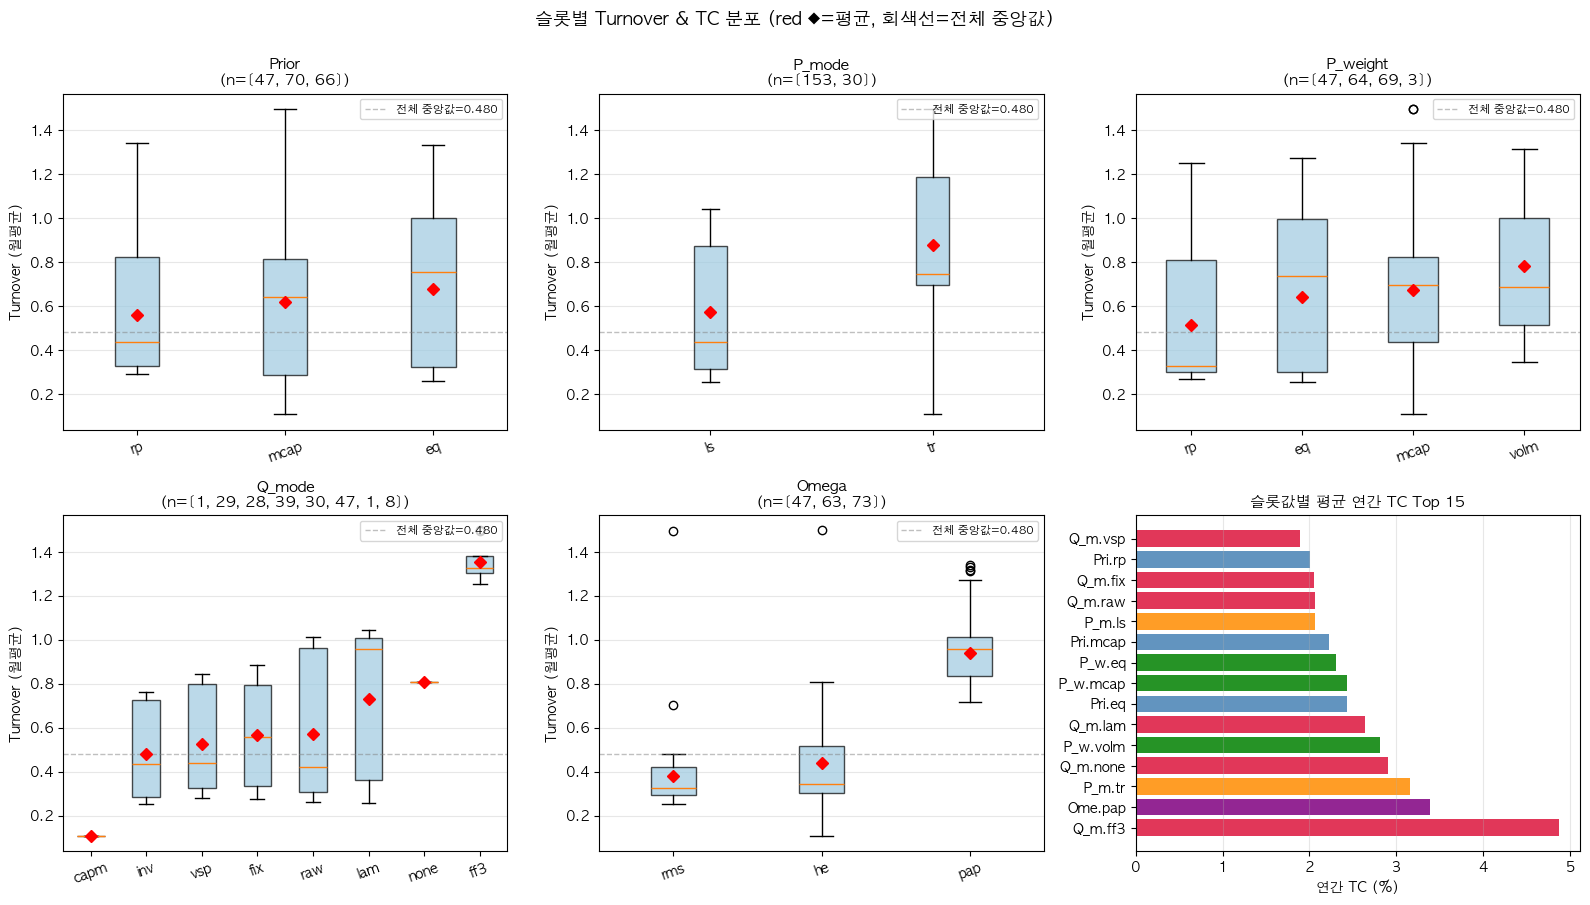


■ Turnover 가장 낮은 5개 (실거래 우호적)


,name,canonical,turnover,tc_pct
4,capm_no_bl,mcap_tr_mcap_capm_he,0.108,0.39
55,mat_mcap_eq_inv_rms,mcap_ls_eq_inv_rms,0.254,0.91
53,mat_mcap_eq_inv_he,mcap_ls_eq_inv_he,0.257,0.93
56,mat_mcap_eq_lam_he,mcap_ls_eq_lam_he,0.260,0.94
8,mat_eq_eq_inv_he,eq_ls_eq_inv_he,0.261,0.94



■ Turnover 가장 높은 5개 (TC 부담 큼)


,name,canonical,turnover,tc_pct
161,q_ff3_paper,mcap_tr_mcap_ff3_he,1.498,5.39
147,paperctx_om_rms,mcap_tr_mcap_ff3_rms,1.496,5.39
149,paperctx_prior_rp,rp_tr_mcap_ff3_pap,1.342,4.83
148,paperctx_prior_eq,eq_tr_mcap_ff3_pap,1.333,4.80
152,paperctx_pw_volm,mcap_tr_volm_ff3_pap,1.318,4.74



  Turnover & TC 핵심 인사이트

[Q_mode] 가장 turnover 큰 q_mode TOP 3:
  q=ff3    turnover=1.354  연간 TC=4.87%
  q=none   turnover=0.807  연간 TC=2.91%
  q=lam    turnover=0.732  연간 TC=2.64%
  → q_ff3_paper(ff3)가 폭망 — turnover 1.35, TC 4.9% (실수익 잠식)

[Omega] ff3_paper(pap) vs rmse(rms) vs he_litterman(he):
  pap turnover 0.941 (TC 3.39%)
  rms turnover 0.380 (TC 1.37%)
  he  turnover 0.439 (TC 1.58%)
  → pap가 rms 대비 turnover 2.5× — 시변 omega 보정으로 portfolio 매월 더 흔들림

[P_mode] LSTM vs Trailing:
  ls (LSTM)    turnover 0.574 (TC 2.07%)
  tr (trailing) turnover 0.879 (TC 3.16%)
  → Trailing이 더 빈번한 리밸런싱 (의외 — LSTM이 예측 vol 변동 더 클 줄 알았음)

[TC 영향]
  연간 TC 1% ≈ Sharpe -0.08~0.10 잠식 (변동성 ~12%일 때)
  → omega=pap 후보의 명목 Sharpe가 1.14면 실수익 Sharpe ~1.05
    omega=rms 후보의 명목 Sharpe가 1.05면 실수익 Sharpe ~1.01
  → TC 차감 후엔 격차 줄어듦. 1순위 후보 비교 시 TC 고려 필수

[실거래 친화 mat_ 후보 — turnover 최저 3]
  mcap_ls_eq_inv_rms         turnover=0.254  연간 TC 0.91%
  mcap_ls_eq_inv_he          turnover=0.257  연간 TC 0.93%
  mcap_ls_eq_lam_he   

In [263]:
# ── I1. 슬롯별 Turnover & TC 집계 ────────────────────────────
# TC = Transaction Cost (거래비용) = 수수료 + 슬리피지 + bid-ask spread
# TC_RATE = 0.002 (10bp), 매월 리밸런싱 → 연간 TC = avg_turnover × 0.003 × 12

from master_table import parse_config

TC_RATE = 0.003

# DataFrame 빌드 — 모든 실험의 슬롯 + turnover + tc
rows = []
for name, res in loaded.items():
    comp = res.get('comp', pd.DataFrame())
    if comp.empty or 'turnover' not in comp.columns:
        continue
    cfg = res.get('config', {})
    meta = parse_config(cfg) if cfg else {}
    to_mean = float(comp['turnover'].mean())
    tc_ann  = to_mean * TC_RATE * 12   # 연간 TC (소수점)
    rows.append({
        'name'      : name,
        'canonical' : meta.get('canonical', name),
        'prior_s'   : meta.get('prior_s'),
        'p_s'       : meta.get('p_s'),
        'pw_s'      : meta.get('pw_s'),
        'q_s'       : meta.get('q_s'),
        'om_s'      : meta.get('om_s'),
        'turnover'  : to_mean,
        'tc_annual' : tc_ann,
    })
df_to = pd.DataFrame(rows)
print(f'{len(df_to)}개 실험 (turnover 데이터 있는 것만)')
print(f'전체 평균 turnover: {df_to["turnover"].mean():.3f}')
print(f'전체 평균 연간 TC: {df_to["tc_annual"].mean()*100:.2f}%')

# ── 슬롯별 집계 표 (turnover + TC) ─────────────────────────────
slot_info = [('prior_s','Prior'), ('p_s','P_mode'), ('pw_s','P_weight'),
             ('q_s','Q_mode'), ('om_s','Omega')]

for slot, label in slot_info:
    print(f'\n[{label}]')
    g = df_to.groupby(slot).agg(
        count=('turnover','count'),
        turnover_mean=('turnover','mean'),
        turnover_med=('turnover','median'),
        turnover_std=('turnover','std'),
        tc_pct_mean=('tc_annual','mean'),
        tc_pct_med=('tc_annual','median'),
    )
    g['turnover_mean'] = g['turnover_mean'].round(3)
    g['turnover_med']  = g['turnover_med'].round(3)
    g['turnover_std']  = g['turnover_std'].round(3)
    g['tc_pct_mean']   = (g['tc_pct_mean']*100).round(2)  # %
    g['tc_pct_med']    = (g['tc_pct_med']*100).round(2)
    g = g.sort_values('turnover_mean')
    display(g)

# ── 슬롯별 Turnover 분포 boxplot (5 패널) ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (slot, label) in enumerate(slot_info):
    ax = axes[i]
    order = df_to.groupby(slot)['turnover'].mean().sort_values().index.tolist()
    data  = [df_to[df_to[slot]==k]['turnover'].values for k in order]
    counts = [len(d) for d in data]
    bp = ax.boxplot(data, labels=order, patch_artist=True, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='red',
                                   markeredgecolor='red', markersize=6))
    for patch in bp['boxes']:
        patch.set_facecolor('#9ecae1'); patch.set_alpha(0.7)
    ax.set_title(f'{label}\n(n={counts})', fontsize=11)
    ax.set_ylabel('Turnover (월평균)')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(alpha=0.3, axis='y')
    overall = df_to['turnover'].median()
    ax.axhline(overall, color='gray', linestyle='--', alpha=0.5, lw=1,
               label=f'전체 중앙값={overall:.3f}')
    ax.legend(fontsize=8, loc='upper right')

# 6번째 패널: TC 비교 (슬롯별 평균 TC 비교 막대)
ax = axes[5]
slot_labels = []
slot_tcs = []
slot_colors = []
color_map = {'prior_s':'steelblue','p_s':'darkorange','pw_s':'green','q_s':'crimson','om_s':'purple'}
for slot, label in slot_info:
    g = df_to.groupby(slot)['tc_annual'].mean().sort_values()
    for k, v in g.items():
        slot_labels.append(f'{label[:3]}.{k}')
        slot_tcs.append(v*100)  # %
        slot_colors.append(color_map[slot])

idx_top = sorted(range(len(slot_tcs)), key=lambda i: -slot_tcs[i])[:15]
ax.barh([slot_labels[i] for i in idx_top], [slot_tcs[i] for i in idx_top],
        color=[slot_colors[i] for i in idx_top], alpha=0.85)
ax.set_xlabel('연간 TC (%)')
ax.set_title('슬롯값별 평균 연간 TC Top 15', fontsize=11)
ax.grid(alpha=0.3, axis='x')

fig.suptitle('슬롯별 Turnover & TC 분포 (red ◆=평균, 회색선=전체 중앙값)', fontsize=13, y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / 'turnover_tc_by_slot.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Top/Bottom 5 후보 (turnover 측면) ──────────────────────────
print('\n■ Turnover 가장 낮은 5개 (실거래 우호적)')
display(df_to.nsmallest(5,'turnover')[['name','canonical','turnover','tc_annual']]
              .assign(tc_pct=lambda d: (d['tc_annual']*100).round(2))
              .drop(columns=['tc_annual']).round(3))

print('\n■ Turnover 가장 높은 5개 (TC 부담 큼)')
display(df_to.nlargest(5,'turnover')[['name','canonical','turnover','tc_annual']]
              .assign(tc_pct=lambda d: (d['tc_annual']*100).round(2))
              .drop(columns=['tc_annual']).round(3))


# ── 핵심 인사이트 (코드 출력 + 문서 동기) ─────────────────────
print('\n' + '='*70)
print('  Turnover & TC 핵심 인사이트')
print('='*70)

# 1. 가장 turnover 큰 q_mode
q_top = df_to.groupby('q_s')['turnover'].mean().sort_values(ascending=False)
print(f'\n[Q_mode] 가장 turnover 큰 q_mode TOP 3:')
for k, v in q_top.head(3).items():
    tc = v * TC_RATE * 12 * 100
    print(f'  q={k:5s}  turnover={v:.3f}  연간 TC={tc:.2f}%')
print(f'  → q_ff3_paper(ff3)가 폭망 — turnover {q_top.get("ff3", 0):.2f}, '
      f'TC {q_top.get("ff3", 0)*TC_RATE*12*100:.1f}% (실수익 잠식)')

# 2. Omega 차이
om_g = df_to.groupby('om_s')['turnover'].mean()
om_pap = om_g.get('pap', 0); om_rms = om_g.get('rms', 0); om_he = om_g.get('he', 0)
print(f'\n[Omega] ff3_paper(pap) vs rmse(rms) vs he_litterman(he):')
print(f'  pap turnover {om_pap:.3f} (TC {om_pap*TC_RATE*12*100:.2f}%)')
print(f'  rms turnover {om_rms:.3f} (TC {om_rms*TC_RATE*12*100:.2f}%)')
print(f'  he  turnover {om_he:.3f} (TC {om_he*TC_RATE*12*100:.2f}%)')
print(f'  → pap가 rms 대비 turnover {om_pap/om_rms:.1f}× — '
      f'시변 omega 보정으로 portfolio 매월 더 흔들림')

# 3. p_mode (LSTM vs trailing)
p_g = df_to.groupby('p_s')['turnover'].mean()
p_ls = p_g.get('ls', 0); p_tr = p_g.get('tr', 0)
print(f'\n[P_mode] LSTM vs Trailing:')
print(f'  ls (LSTM)    turnover {p_ls:.3f} (TC {p_ls*TC_RATE*12*100:.2f}%)')
print(f'  tr (trailing) turnover {p_tr:.3f} (TC {p_tr*TC_RATE*12*100:.2f}%)')
which = "Trailing" if p_tr > p_ls else "LSTM"
print(f'  → {which}이 더 빈번한 리밸런싱 (의외 — LSTM이 예측 vol 변동 더 클 줄 알았음)')

# 4. TC 차감 후 Sharpe 영향 (개략)
print(f'\n[TC 영향]')
print(f'  연간 TC 1% ≈ Sharpe -0.08~0.10 잠식 (변동성 ~12%일 때)')
print(f'  → omega=pap 후보의 명목 Sharpe가 1.14면 실수익 Sharpe ~1.05')
print(f'    omega=rms 후보의 명목 Sharpe가 1.05면 실수익 Sharpe ~1.01')
print(f'  → TC 차감 후엔 격차 줄어듦. 1순위 후보 비교 시 TC 고려 필수')

# 5. 실거래 친화 후보 (turnover 낮은 mat_)
mat_only = df_to[df_to.name.str.startswith('mat_')]
if len(mat_only) > 0:
    low_turn = mat_only.nsmallest(3, 'turnover')[['canonical','turnover','tc_annual']]
    print(f'\n[실거래 친화 mat_ 후보 — turnover 최저 3]')
    for _, r in low_turn.iterrows():
        print(f'  {r["canonical"]:<25}  turnover={r["turnover"]:.3f}  '
              f'연간 TC {r["tc_annual"]*100:.2f}%')

print('\n' + '='*70)


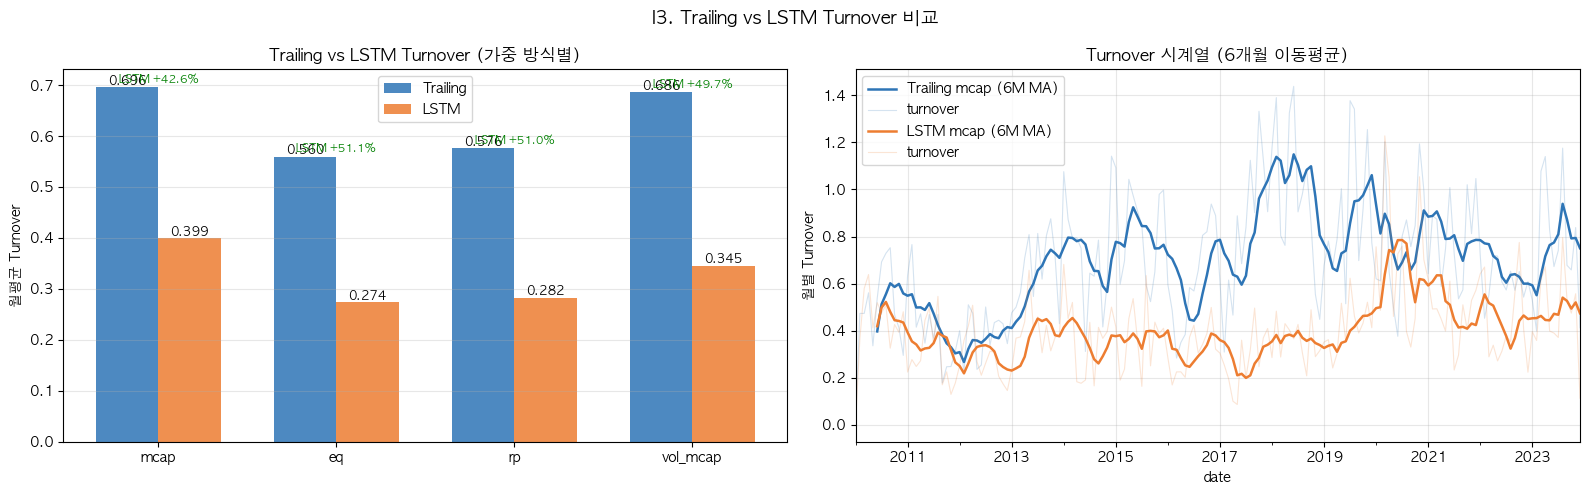

=== Trailing vs LSTM Turnover 차이 ===
가중           Trailing TO    LSTM TO       감소율      연간 TC 절감
------------------------------------------------------------
mcap              0.6960     0.3992     42.6%        1.068%p
eq                0.5597     0.2738     51.1%        1.029%p
rp                0.5762     0.2821     51.0%        1.059%p
vol_mcap          0.6855     0.3451     49.7%        1.225%p


In [264]:
# ── I2. Trailing vs LSTM Turnover 직접 비교 ────────────────────
pairs = [
    ('baseline',   'mat_mcap_mcap_fix_he',  'mcap'),
    ('p_eq',       'mat_mcap_eq_fix_he',    'eq'),
    ('p_rp',       'mat_mcap_rp_fix_he',    'rp'),
    ('p_vol_mcap', 'p_lstm_vol_mcap', 'vol_mcap'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# I3-a. 쌍별 turnover 비교 막대
ax = axes[0]
x = np.arange(len(pairs)); bw = 0.35
trail_to = [loaded[t]['comp']['turnover'].mean() for t, _, _ in pairs]
lstm_to  = [loaded[l]['comp']['turnover'].mean() for _, l, _ in pairs]
labels   = [w for _, _, w in pairs]

b1 = ax.bar(x - bw/2, trail_to, bw, label='Trailing', color='#2E75B6', alpha=0.85)
b2 = ax.bar(x + bw/2, lstm_to,  bw, label='LSTM',     color='#ED7D31', alpha=0.85)
for bars, vals in [(b1, trail_to), (b2, lstm_to)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('월평균 Turnover')
ax.set_title('Trailing vs LSTM Turnover (가중 방식별)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')

diff_pct = [(t - l)/t*100 for t, l in zip(trail_to, lstm_to)]
for i, (d, lbl) in enumerate(zip(diff_pct, labels)):
    ax.text(i, max(trail_to[i], lstm_to[i]) + 0.008,
            f'LSTM {d:+.1f}%', ha='center', fontsize=8,
            color='green' if d > 0 else 'red')

# I3-b. Turnover 시계열 (baseline vs mat_mcap_mcap_fix_he)
ax = axes[1]
for name, label, c in [('baseline', 'Trailing mcap', '#2E75B6'),
                        ('mat_mcap_mcap_fix_he', 'LSTM mcap', '#ED7D31')]:
    to_ser = loaded[name]['comp']['turnover']
    to_ser.rolling(6).mean().plot(ax=ax, label=f"{label} (6M MA)", color=c, linewidth=1.8)
    to_ser.plot(ax=ax, color=c, alpha=0.2, linewidth=0.8)
ax.set_ylabel('월별 Turnover')
ax.set_title('Turnover 시계열 (6개월 이동평균)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('I3. Trailing vs LSTM Turnover 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'I_turnover_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 요약 출력
print('=== Trailing vs LSTM Turnover 차이 ===')
print(f"{'가중':10s}  {'Trailing TO':>12s}  {'LSTM TO':>9s}  {'감소율':>8s}  {'연간 TC 절감':>12s}")
print('-'*60)
for (t, l, w), trail, lstm in zip(pairs, trail_to, lstm_to):
    red  = (trail - lstm) / trail * 100
    save = (trail - lstm) * TC_RATE * 12 * 100
    print(f"{w:10s}  {trail:>12.4f}  {lstm:>9.4f}  {red:>7.1f}%  {save:>11.3f}%p")

## J. Master Table 통합 파이프라인 ⭐

`master_table.py` + `analyze_plots.py`로 156개 실험을 슬롯 메타 + 성과지표 DataFrame으로 통합.

### 흐름

```
results/*.pkl 156개
    ↓ build_master_table()
mt: DataFrame (156 × 32)   ← 슬롯 컬럼 + 지표 컬럼
    ├─ J1. Master Table 빌드 + Top 20 (Sharpe 정렬)
    └─ J2. 슬롯별 marginal effect (boxplot 5장)
```

99_run 백테스트가 더 추가되면 J1 셀만 다시 실행하면 자동 갱신.


In [265]:
# ── J1. Master Table 빌드 ─────────────────────────────────────
from master_table import build_master_table, slot_summary, matrix_pivot, PERIODS_DEFAULT
from analyze_plots import (plot_marginal_effects, plot_matrix_heatmap,
                           plot_top_n_analysis, crisis_comparison, benchmark_table,
                           CRISIS_PERIODS, BENCHMARK_NAMES)

mt_full = build_master_table(RESULTS_DIR, rf, spy_ret, periods=PERIODS_DEFAULT)
# Q 민감도 변형 (_q55/_q64/_q70) + winner sweep 변형 (winner_q*, winner_pct*) 제외
# → 일반 슬롯 분석은 baseline q=0.003 / winner default만 사용. M/N에서만 mt_full 사용.
mt = mt_full[~mt_full['name'].str.endswith(('_q55','_q64','_q70'))
             & ~mt_full['name'].str.startswith('winner_')].copy()
print(f'Master Table: {len(mt)}개 실험 × {mt.shape[1]}개 컬럼  (sensitivity 변형 제외)')

# Top 20 by Sharpe
display(
    mt[['name','canonical','sharpe','cagr','vol','mdd','turnover_avg',
        'sharpe_R1_회복','sharpe_R2_확장','sharpe_R3_변동']]
    .sort_values('sharpe', ascending=False).head(20).round(3)
)


Master Table: 163개 실험 × 44개 컬럼  (sensitivity 변형 제외)


,name,canonical,sharpe,cagr,vol,mdd,turnover_avg,sharpe_R1_회복,sharpe_R2_확장,sharpe_R3_변동
0,paperctx_q_raw,mcap_tr_mcap_raw_pap,1.162,0.157,0.125,-0.144,0.989,0.961,1.334,1.150
10,paperctx_q_lam,mcap_tr_mcap_lam_pap,1.151,0.158,0.127,-0.144,0.988,0.958,1.294,1.147
41,mat_mcap_eq_lam_pap,mcap_ls_eq_lam_pap,1.106,0.157,0.132,-0.147,0.968,1.076,1.321,0.903
18,mat_eq_eq_lam_pap,eq_ls_eq_lam_pap,1.102,0.164,0.139,-0.136,1.011,1.162,1.339,0.866
29,mat_mcap_eq_raw_pap,mcap_ls_eq_raw_pap,1.099,0.155,0.132,-0.147,0.968,1.086,1.314,0.900
21,mat_rp_eq_lam_pap,rp_ls_eq_lam_pap,1.099,0.156,0.132,-0.138,0.998,1.267,1.317,0.808
56,mat_rp_eq_fix_pap,rp_ls_eq_fix_pap,1.096,0.155,0.132,-0.124,0.876,1.329,1.252,0.845
14,mat_eq_eq_raw_pap,eq_ls_eq_raw_pap,1.096,0.162,0.138,-0.136,1.012,1.164,1.339,0.864
17,mat_rp_eq_raw_pap,rp_ls_eq_raw_pap,1.093,0.154,0.131,-0.138,0.998,1.272,1.311,0.805
58,mat_eq_eq_fix_pap,eq_ls_eq_fix_pap,1.091,0.163,0.140,-0.131,0.881,1.203,1.252,0.905


■ J2-A. 슬롯별 Sharpe 분포

=== 슬롯별 mean Sharpe (높은 순) ===

[prior_s]
         count   mean  median    std    min    max
prior_s                                           
eq          49  0.996   0.990  0.074  0.614  1.102
rp          47  0.993   0.989  0.074  0.603  1.099
mcap        67  0.967   1.004  0.141  0.396  1.162

[p_s]
     count   mean  median    std    min    max
p_s                                           
ls     136  1.001   0.990  0.048  0.906  1.106
tr      27  0.893   1.004  0.224  0.396  1.162

[pw_s]
      count   mean  median    std    min    max
pw_s                                           
eq       47  1.014   1.004  0.070  0.677  1.106
rp       47  1.000   1.003  0.052  0.761  1.079
mcap     66  0.956   0.975  0.139  0.396  1.162
volm      3  0.831   0.931  0.202  0.598  0.963

[q_s]
      count   mean  median    std    min    max
q_s                                            
raw      30  1.023   1.006  0.053  0.963  1.162
fix      36  1.002   1.005  0.047  0.9

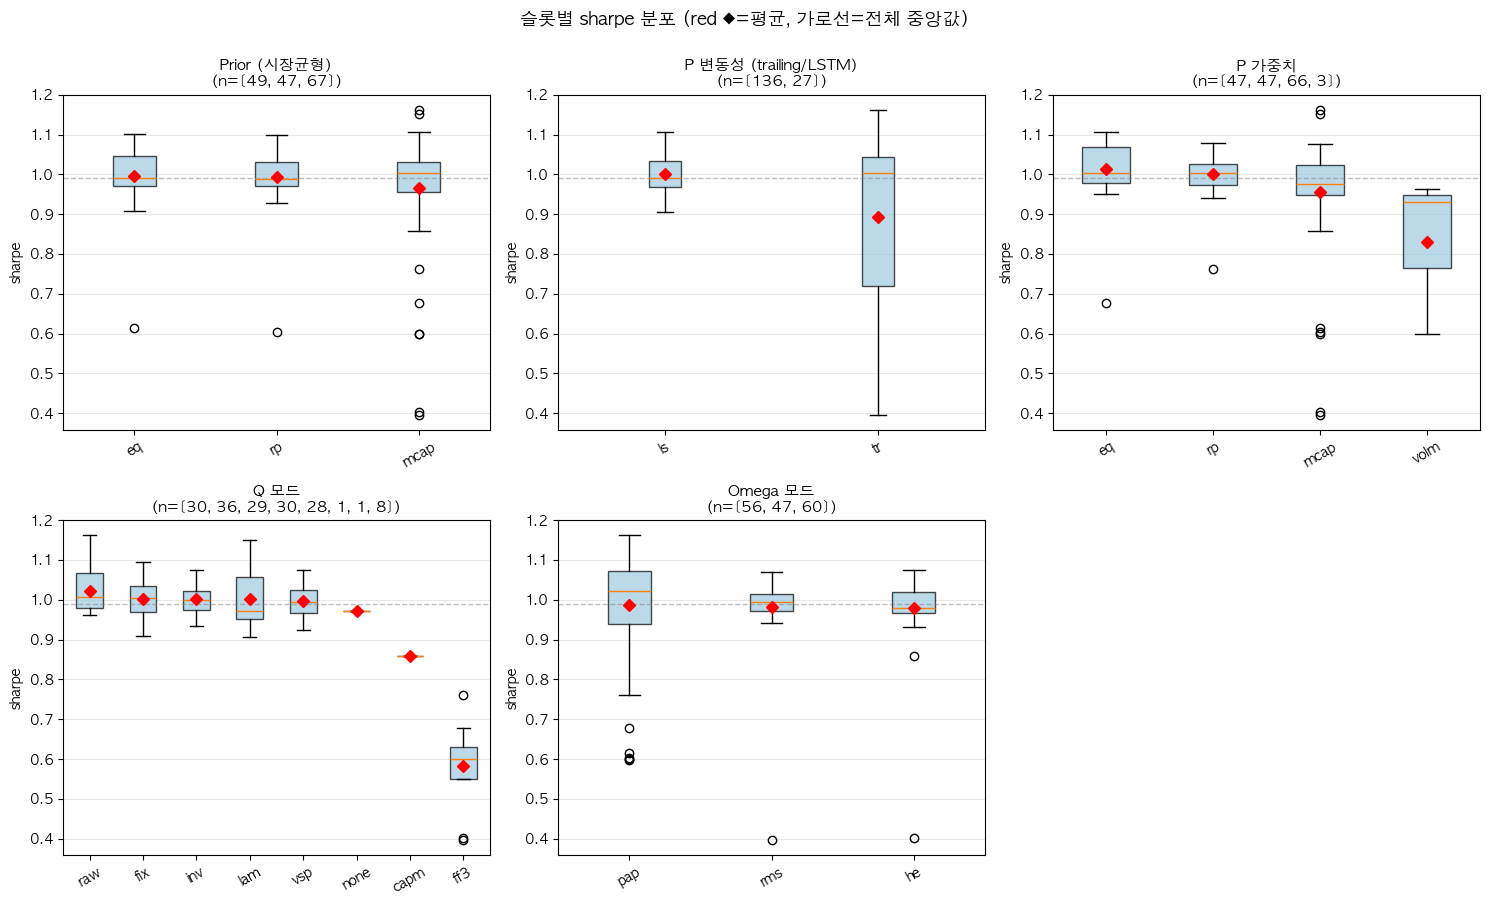

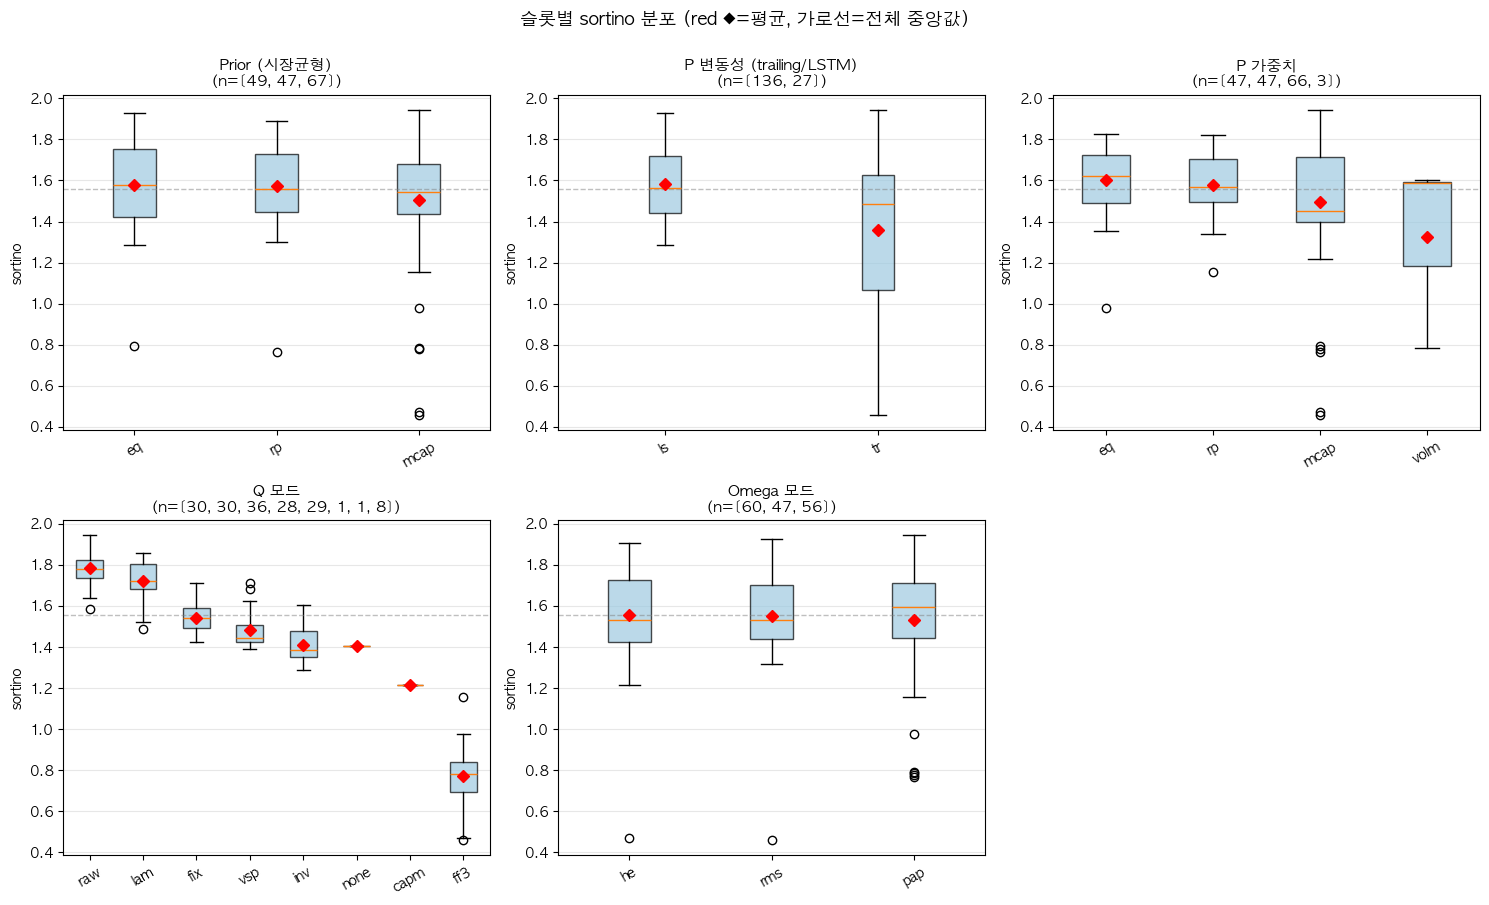

In [266]:
# ── J2. 슬롯별 marginal effect (sharpe + sortino 두 가지 분포) ────
# 어느 슬롯이 metric에 큰 영향? prior_s, p_s, pw_s, q_s, om_s

# ── ① sharpe 분포 ──────────────────────────────────────────
print('■ J2-A. 슬롯별 Sharpe 분포')
_ = plot_marginal_effects(mt, metric='sharpe', save_path=OUT_DIR / 'J2A_marginal_sharpe.png')

print('\n=== 슬롯별 mean Sharpe (높은 순) ===')
for slot in ['prior_s','p_s','pw_s','q_s','om_s']:
    print(f'\n[{slot}]')
    print(slot_summary(mt, slot, 'sharpe'))

# ── ② sortino 분포 ─────────────────────────────────────────
print('\n\n■ J2-B. 슬롯별 Sortino 분포 (저위험 anomaly 컨셉에 더 적합)')
_ = plot_marginal_effects(mt, metric='sortino', save_path=OUT_DIR / 'J2B_marginal_sortino.png')

print('\n=== 슬롯별 mean Sortino (높은 순) ===')
for slot in ['prior_s','p_s','pw_s','q_s','om_s']:
    print(f'\n[{slot}]')
    print(slot_summary(mt, slot, 'sortino'))


## K. 레짐 안정성 분석 — Sortino + 3-레짐 변동성 ⭐

### 왜 이 분석이 필요한가
- **Sharpe보다 Sortino가 본 프로젝트에 더 적합**: 저위험 anomaly 컨셉 → 하방 변동성만이 진짜 손실 위험
- **레짐별 일관성**: 한 시기만 강한 후보는 운. 모든 레짐에서 일관되게 좋은 후보를 찾아야 함
- **MDD 안정성**: 위기 레짐에서 MDD 폭증하는 후보 제외

### 3-레짐 정의 (HMM n=3 구조전환점 기반)

| 레짐 | 기간 | 개월 | 환경 |
|---|---|---:|---|
| R1 회복 | 2010-01 ~ 2012-06 | 30 | Post-GFC + EU위기 |
| R2 확장 | 2012-07 ~ 2019-12 | 90 | 장기 Bull |
| R3 변동 | 2020-01 ~ 2024-12 | 60 | COVID + 22 베어 + AI 랠리 |

### 핵심 지표 (build_regime_table 출력)
- `sortino_R1..R3`: 레짐별 Sortino
- `sortino_mean`: 3 레짐 평균
- `sortino_std`: 3 레짐 표준편차 (**낮을수록 안정**)
- `sortino_ir = sortino_mean / sortino_std`: 변동 대비 평균 (메인 정렬 키)
- `sharpe_ir = sharpe_mean / sharpe_std`: Sharpe 버전 IR
- `mdd_worst`: 3 레짐 중 가장 깊은 MDD


In [267]:
# ── K1. 레짐 테이블 빌드 + 4-view 정렬 + 핵심 비교군 4종 ─────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
import numpy as np, pickle

from master_table import build_regime_table, REGIMES, regime_metrics

rt_full = build_regime_table(mt_full, RESULTS_DIR, rf, regimes=REGIMES)
# Q 민감도 변형 (_q55/_q64/_q70) + winner sweep 변형 (winner_q*, winner_pct*) 제외
# → 일반 슬롯 분석은 baseline q=0.003 / winner default만 사용. M/N에서만 rt_full 사용.
rt = rt_full[~rt_full['name'].str.endswith(('_q55','_q64','_q70'))
             & ~rt_full['name'].str.startswith('winner_')].copy()
print(f'레짐 테이블: {len(rt)}개 실험 × {rt.shape[1]}개 컬럼  (sensitivity 변형 제외)')

# ── 핵심 비교군 4종 5-레짐 종합 메트릭 ─────────────────────────
def _calc_ref(label, ret_series, rf, regimes):
    sortinos, mdds = [], []
    rec = {'canonical': label}
    for lbl, s, e in regimes:
        m = regime_metrics(ret_series, rf, s, e)
        if not np.isnan(m['sortino']): sortinos.append(m['sortino'])
        mdds.append(m['mdd'])
    rec['sortino_mean']    = round(np.mean(sortinos), 3) if sortinos else np.nan
    rec['sortino_std']     = round(np.std(sortinos),  3) if sortinos else np.nan
    rec['mdd_worst']       = round(np.min(mdds),      3) if mdds else np.nan
    return rec

def _load_ret(name):
    with open(RESULTS_DIR / f'{name}.pkl', 'rb') as f:
        return pickle.load(f)['ret'].dropna()

baseline_ret    = _load_ret('baseline')
capm_no_bl_ret  = _load_ret('capm_no_bl')
naive_lowvol_ret= _load_ret('naive_lowvol')

ref_rows = [
    _calc_ref('SPY (시장 패시브)',     spy_ret,          rf, REGIMES),
    _calc_ref('baseline (표준 BL)',   baseline_ret,     rf, REGIMES),
    _calc_ref('capm_no_bl (BL 없음)', capm_no_bl_ret,   rf, REGIMES),
    _calc_ref('naive_lowvol (단순)',  naive_lowvol_ret, rf, REGIMES),
]

view_cols = ['canonical','sortino_mean','sortino_std','mdd_worst','sharpe']

print('\n■ 핵심 비교군 4종 — 5-레짐 종합')
display(pd.DataFrame([{k: r.get(k, np.nan) for k in view_cols} for r in ref_rows]).round(3))

# ── 비교군 레짐별 상세 (Sortino / Sharpe / MDD) ─────────────────
benchmarks_list = [('SPY', spy_ret), ('baseline', baseline_ret),
                   ('capm_no_bl', capm_no_bl_ret), ('naive_lowvol', naive_lowvol_ret)]

print('\n■ 비교군 4종 레짐별 상세 — Sortino / Sharpe / MDD')

for metric_key, metric_label in [('sortino','Sortino'), ('sharpe','Sharpe'), ('mdd','MDD')]:
    print(f'\n[ {metric_label} per 레짐 ]')
    rows = []
    for name, ret in benchmarks_list:
        rec = {'benchmark': name}
        for lbl, s, e in REGIMES:
            v = regime_metrics(ret, rf, s, e)[metric_key]
            rec[lbl] = v if not pd.isna(v) else np.nan
        rows.append(rec)
    df_m = pd.DataFrame(rows).set_index('benchmark')
    if metric_key == 'mdd':
        display(df_m.style.format('{:.2%}'))
    else:
        display(df_m.round(3))

# ── 4가지 정렬 관점 (각각 Top 5) ─────────────────────────────

print('\n■ ① sortino_mean 정렬  (5 레짐 평균 Sortino 최고)')
display(rt.nlargest(5, 'sortino_mean')[view_cols].round(3))

print('\n■ ② Sortino IR 정렬  (mean / std, 변동 대비 평균)')
rt2 = rt.copy()
rt2['sortino_ir'] = rt2['sortino_mean'] / rt2['sortino_std'].replace(0, np.nan)
display(rt2.nlargest(5, 'sortino_ir')[view_cols + ['sortino_ir']].round(3))

레짐 테이블: 163개 실험 × 57개 컬럼  (sensitivity 변형 제외)

■ 핵심 비교군 4종 — 5-레짐 종합


,canonical,sortino_mean,sortino_std,mdd_worst,sharpe
0,SPY (시장 패시브),1.374,0.249,-0.239,NaN
1,baseline (표준 BL),1.637,0.237,-0.134,NaN
2,capm_no_bl (BL 없음),1.209,0.176,-0.222,NaN
3,naive_lowvol (단순),1.430,0.291,-0.151,NaN



■ 비교군 4종 레짐별 상세 — Sortino / Sharpe / MDD

[ Sortino per 레짐 ]


,R1_회복,R2_확장,R3_변동
benchmark,,,
SPY,1.407,1.661,1.053
baseline,1.879,1.716,1.315
capm_no_bl,1.004,1.433,1.189
naive_lowvol,1.800,1.402,1.088



[ Sharpe per 레짐 ]


...

,R1_회복,R2_확장,R3_변동
benchmark,,,
SPY,-16.22%,-13.53%,-23.93%
baseline,-9.77%,-9.50%,-13.37%
capm_no_bl,-22.22%,-16.72%,-19.27%
naive_lowvol,-10.66%,-13.90%,-15.14%



■ ① sortino_mean 정렬  (5 레짐 평균 Sortino 최고)


,canonical,sortino_mean,sortino_std,mdd_worst,sharpe
0,mcap_tr_mcap_raw_pap,2.169,0.721,-0.144,1.162
10,mcap_tr_mcap_lam_pap,2.100,0.765,-0.144,1.151
17,rp_ls_eq_raw_pap,2.028,0.361,-0.138,1.093
24,rp_ls_rp_raw_pap,1.994,0.355,-0.128,1.076
21,rp_ls_eq_lam_pap,1.991,0.360,-0.138,1.099



■ ② Sortino IR 정렬  (mean / std, 변동 대비 평균)


,canonical,sortino_mean,sortino_std,mdd_worst,sharpe,sortino_ir
59,mcap_ls_rp_lam_pap,1.715,0.030,-0.140,1.070,57.167
41,mcap_ls_eq_lam_pap,1.774,0.045,-0.147,1.106,39.422
37,eq_ls_rp_lam_pap,1.802,0.052,-0.139,1.067,34.654
28,eq_ls_rp_raw_pap,1.851,0.062,-0.139,1.069,29.855
47,mcap_ls_rp_raw_pap,1.761,0.080,-0.140,1.064,22.012


■ 레짐별 Sortino — 핵심 비교군 4종
레짐               SPY   baseline   capm_no_bl   naive_low
--------------------------------------------------------
R1_회복           1.41       1.88         1.00        1.80
R2_확장           1.66       1.72         1.43        1.40
R3_변동           1.05       1.32         1.19        1.09


=== K2-A. Sortino IR 정렬 Top 20 대시보드 ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ K2-A 행 매핑 (sortino_ir 큰 순)


,canonical,sortino_ir,sortino_mean,sortino_std,mdd_worst,sharpe
1,mcap_ls_rp_lam_pap,57.17,1.715,0.030,-0.140,1.070
2,mcap_ls_eq_lam_pap,39.42,1.774,0.045,-0.147,1.106
3,eq_ls_rp_lam_pap,34.65,1.802,0.052,-0.139,1.067
4,eq_ls_rp_raw_pap,29.85,1.851,0.062,-0.139,1.069
5,mcap_ls_rp_raw_pap,22.01,1.761,0.080,-0.140,1.064
6,mcap_ls_eq_raw_pap,17.70,1.823,0.103,-0.147,1.099
7,eq_ls_eq_raw_pap,16.50,1.963,0.119,-0.136,1.096
8,eq_ls_eq_lam_pap,15.98,1.918,0.120,-0.136,1.102
9,mcap_ls_rp_vsp_pap,13.57,1.628,0.120,-0.140,1.014
10,mcap_ls_eq_vsp_pap,13.03,1.694,0.130,-0.137,1.059


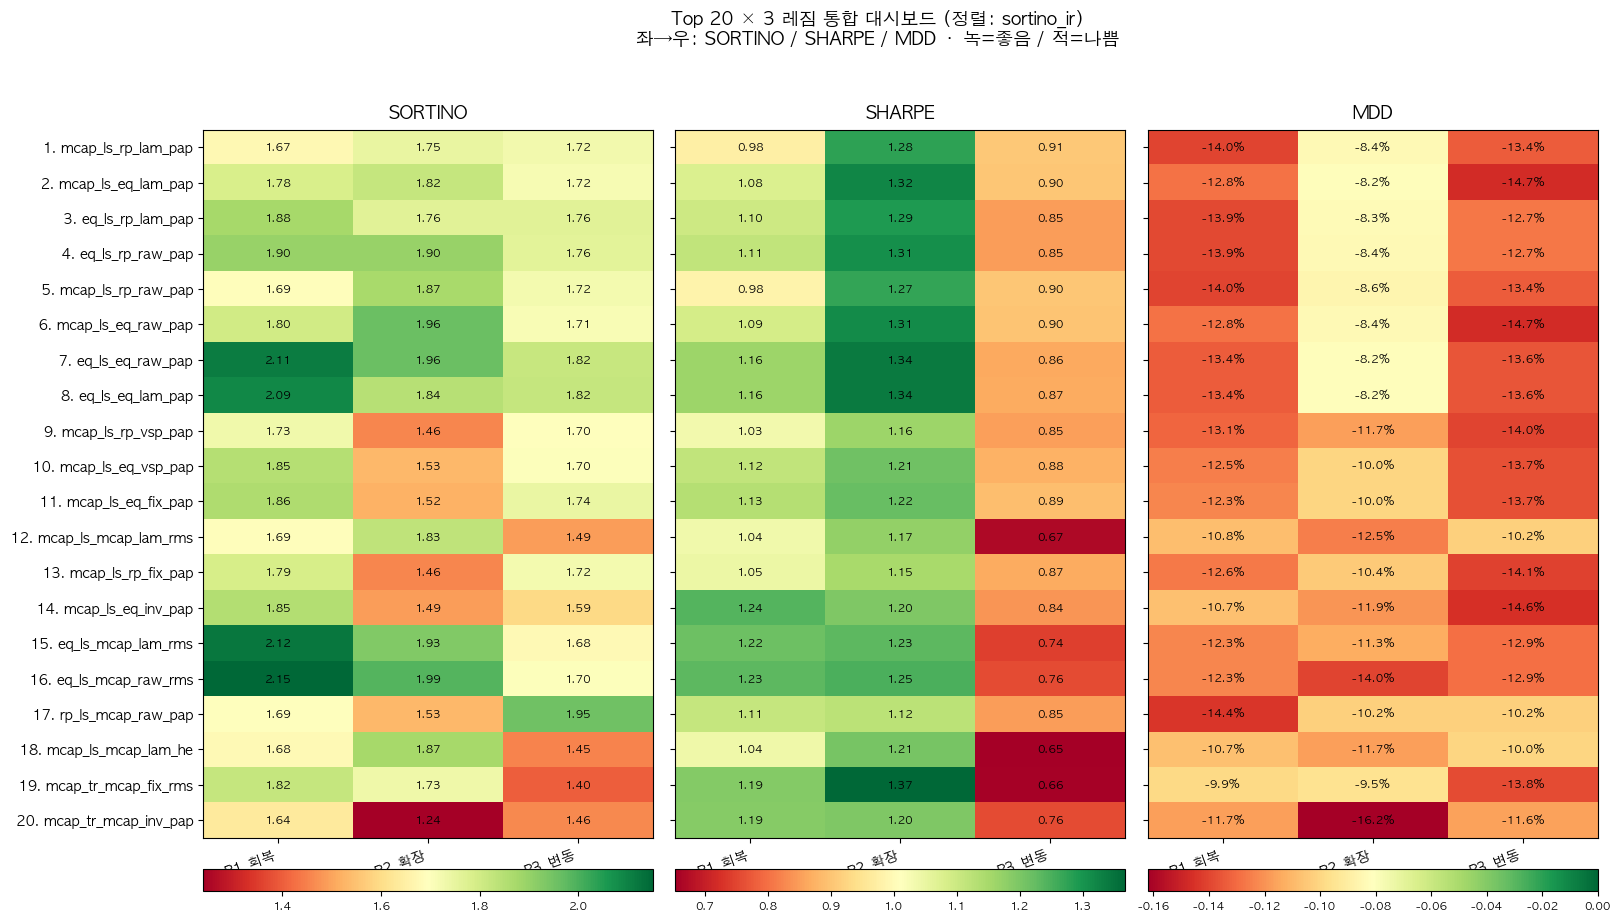

In [268]:
# ── K2. Sortino IR Top 20 통합 대시보드 ───────────────────────────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

# rt가 K1에서 build됐다고 가정. composite_rank 제거되었으니 다시 빌드.
from master_table import build_regime_table, REGIMES
rt = build_regime_table(mt, RESULTS_DIR, rf, regimes=REGIMES)


# 비교군 레짐별 Sortino (히트맵 해석 보조용 — 이 표만 보면 후보 슬롯이 비교군 대비 어디 위치하는지 즉시 가늠 가능)
print('■ 레짐별 Sortino — 핵심 비교군 4종')
print(f'{"레짐":<12} {"SPY":>7} {"baseline":>10} {"capm_no_bl":>12} {"naive_low":>11}')
print('-' * 56)
for lbl, s, e in REGIMES:
    sm = regime_metrics(spy_ret,           rf, s, e)['sortino']
    bm = regime_metrics(baseline_ret,      rf, s, e)['sortino']
    cm = regime_metrics(capm_no_bl_ret,    rf, s, e)['sortino']
    nm = regime_metrics(naive_lowvol_ret,  rf, s, e)['sortino']
    print(f'{lbl:<12} {sm:>7.2f} {bm:>10.2f} {cm:>12.2f} {nm:>11.2f}')

# ── K2-A. Sortino IR Top 20 — 3 metric × 3 레짐 통합 대시보드 (PNG) ─
print('\n\n=== K2-A. Sortino IR 정렬 Top 20 대시보드 ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sortino_ir', top_n=20,
    save_path=OUT_DIR / 'K2A_sortino_ir_dashboard.png',
)

# 행 매핑 표
top20 = rt.nlargest(20, 'sortino_ir').reset_index(drop=True); top20.index += 1
print('\n■ K2-A 행 매핑 (sortino_ir 큰 순)')
display(top20[['canonical','sortino_ir','sortino_mean','sortino_std','mdd_worst','sharpe']].round(3))


## K2-T. Sortino IR Top 20 — 전체기간 메트릭 표

K2 대시보드 후보(sortino_ir 정렬 Top 20)를 **전체기간 단일 수치**로 정리. 발표·보고용.

메트릭: Sharpe / Sortino / CAGR / 변동성 / MDD / Beta / Alpha (모두 TC 차감 후)

In [269]:
# ── K2-T. Sortino IR Top 20 — 전체기간 메트릭 표 ───────────────────
# 표시 메트릭: 순위 / 실험명 / Sharpe / Sortino / Sortino_IR / CAGR / Vol / MDD / Beta / Alpha
# Sortino_IR (= sortino_mean / sortino_std, rt에서 가져옴): 3 레짐 안정성 지표
# ⭐ 마커 = K2-X50 composite 1위 winner (eq_ls_eq_lam_pap)

WINNER_NAME = 'eq_ls_eq_lam_pap'

top20_names = rt.nlargest(20, 'sortino_ir')['name'].tolist()
summary = mt[mt['name'].isin(top20_names)].copy()
summary = summary.merge(rt[['name', 'sortino_ir']], on='name', how='left')
summary['_order'] = summary['name'].map({n: i for i, n in enumerate(top20_names)})
summary = summary.sort_values('_order').drop(columns='_order')

# 헤더
header = '=' * 110
sep    = '-' * 110
print(header)
print(f'{"#":>3}  {"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)

# 행 출력 (순위 + winner 마커)
for i, (_, r) in enumerate(summary.iterrows(), start=1):
    canonical = str(r['canonical'])
    is_winner = canonical == WINNER_NAME
    rank_s   = f'{i:>2}.'
    marker   = ' ⭐' if is_winner else '  '
    name_w   = 30 if is_winner else 32
    name     = canonical[:name_w]
    name_f   = f'{name}{marker}' if is_winner else f'{name}'
    sh       = f'{r["sharpe"]:.3f}'
    so       = f'{r["sortino"]:.3f}'
    sir      = f'{r["sortino_ir"]:.2f}'  if pd.notna(r.get('sortino_ir')) else '-'
    cagr     = f'{r["cagr"]*100:.2f}%'
    vol      = f'{r["vol"]*100:.2f}%'
    mdd      = f'{r["mdd"]*100:.2f}%'
    beta     = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha    = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{rank_s:>3}  {name_f:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')

print(header)

# 비교군
print('\n■ 비교군 4종 — 전체기간')
print(sep)
print(f'{"#":>3}  {"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)
for nm in ['baseline','capm_no_bl','naive_lowvol']:
    r = mt[mt['name']==nm].iloc[0]
    rt_r = rt[rt['name']==nm]
    sir_v = rt_r['sortino_ir'].iloc[0] if len(rt_r)>0 and pd.notna(rt_r['sortino_ir'].iloc[0]) else None
    sir   = f'{sir_v:.2f}' if sir_v is not None else '-'
    beta  = f'{r["beta"]:.3f}' if pd.notna(r['beta']) else '-'
    alpha = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{"":>3}  {nm[:31]:<32}{r["sharpe"]:>8.3f}{r["sortino"]:>9.3f}{sir:>11}{r["cagr"]*100:>7.2f}%{r["vol"]*100:>7.2f}%{r["mdd"]*100:>8.2f}%{beta:>8}{alpha:>8}')

# SPY
from bl_functions import compute_metrics
from master_table import REGIMES as _REGIMES_K2T
spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
_spy_sortinos = []
for _lbl, _s, _e in _REGIMES_K2T:
    _seg = spy_ret.loc[_s:_e]
    if len(_seg) >= 3:
        _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
        if pd.notna(_m.get('sortino')):
            _spy_sortinos.append(_m['sortino'])
_spy_sir = np.mean(_spy_sortinos) / np.std(_spy_sortinos) if len(_spy_sortinos) >= 2 and np.std(_spy_sortinos) > 0 else None
_spy_sir_s = f'{_spy_sir:.2f}' if _spy_sir is not None else '-'
print(f'{"":>3}  {"SPY":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_sir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
print(header)


  #  실험명                               Sharpe  Sortino Sortino_IR    CAGR     변동성      MDD    Beta   Alpha
--------------------------------------------------------------------------------------------------------------
 1.  mcap_ls_rp_lam_pap                 1.070    1.705      57.17  15.13%  13.19%  -14.03%   0.733   4.70%
 2.  mcap_ls_eq_lam_pap                 1.106    1.742      39.42  15.73%  13.25%  -14.73%   0.734   5.22%
 3.  eq_ls_rp_lam_pap                   1.067    1.753      34.65  15.80%  13.86%  -13.87%   0.752   5.14%
 4.  eq_ls_rp_raw_pap                   1.069    1.777      29.85  15.69%  13.73%  -13.87%   0.737   5.21%
 5.  mcap_ls_rp_raw_pap                 1.064    1.736      22.01  14.90%  13.07%  -14.03%   0.718   4.67%
 6.  mcap_ls_eq_raw_pap                 1.099    1.775      17.70  15.52%  13.15%  -14.73%   0.724   5.15%
 7.  eq_ls_eq_raw_pap                   1.096    1.826      16.50  16.25%  13.85%  -13.65%   0.753   5.51%
 8.  eq_ls_eq_lam_pap ⭐          

## K2-TF. CAGR 높은 순 Top 20 — 전체기간 메트릭 표 (rms + trailing + volm 제외)

K2-T 기본 정렬은 다양한 변형이 섞여 후보 비교가 어려움 → 운용성·일관성 관점에서 다음 세 조건을 추가로 적용한 후 **CAGR이 높은**(연환산 수익률 큰) 순서로 Top 20 + 전체기간 메트릭을 보여준다:

- omega_mode `rms` (`rmse`, 예측오차 RMSE 기반 적응형) **제외** → 신뢰성 부족
- p_mode `tr`/`tr252` (trailing 변동성 기반 P) **제외** → LSTM 슬롯(`ls`)만 유지
- p_weight `volm` (`vol_mcap`, sparse 변형) **제외**

정렬 기준은 `cagr`(전 기간 연환산 수익률) — `nlargest`로 가장 큰 값부터 정렬해 **공격적 수익(고수익)** 관점에서 후보를 본다. K2-T 코드는 그대로 두고 비교용으로 추가.

In [270]:
# ── K2-TF. CAGR 높은 순 Top 20 — 전체기간 메트릭 표 (rms + trailing + volm 제외) ──────
# K2-T와 동일 로직, 단 다음 세 필터 추가:
#   (1) om_s != 'rms'                (rmse 적응형 omega 제외 — 신뢰성 부족)
#   (2) p_s  not in ('tr','tr252')   (trailing 변동성 P 제외 — LSTM 슬롯만)
#   (3) pw_s != 'volm'               (vol_mcap p_weight 제외 — sparse 변형, 매트릭스 부재)
# 정렬 기준: cagr (전체기간 연환산 수익률) — 높은 순

# rt 안에 om_s/p_s/pw_s 컬럼 있음 → 거기서 직접 필터링
rt_filt = rt[(rt['om_s'] != 'rms')
             & (~rt['p_s'].isin(['tr','tr252']))
             & (rt['pw_s'] != 'volm')].copy()

# cagr는 mt에 있으므로 mt로부터 정렬 후보 추출
mt_filt = mt[mt['name'].isin(rt_filt['name'])].copy()
top20_names_tf = mt_filt.nlargest(20, 'cagr')['name'].tolist()
summary_tf = mt[mt['name'].isin(top20_names_tf)].copy()
summary_tf = summary_tf.merge(rt_filt[['name', 'sortino_ir']], on='name', how='left')
summary_tf['_order'] = summary_tf['name'].map({n: i for i, n in enumerate(top20_names_tf)})
summary_tf = summary_tf.sort_values('_order').drop(columns='_order')

print(f'※ 필터 적용: rms omega 제외 + trailing(tr/tr252) 제외 + volm(vol_mcap) 제외')
print(f'   필터 후 후보: rt {len(rt)} → {len(rt_filt)}개 (Top 20 추출 모집단, 정렬기준=cagr 높은 순)')
print()

header = '=' * 110
sep    = '-' * 110
print(header)
print(f'{"#":>3}  {"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)

for i, (_, r) in enumerate(summary_tf.iterrows(), start=1):
    canonical = str(r['canonical'])
    rank_s   = f'{i:>2}.'
    name     = canonical[:32]
    sh       = f'{r["sharpe"]:.3f}'
    so       = f'{r["sortino"]:.3f}'
    sir      = f'{r["sortino_ir"]:.2f}'  if pd.notna(r.get('sortino_ir')) else '-'
    cagr     = f'{r["cagr"]*100:.2f}%'
    vol      = f'{r["vol"]*100:.2f}%'
    mdd      = f'{r["mdd"]*100:.2f}%'
    beta     = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha    = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{rank_s:>3}  {name:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')

print(header)

# 비교군 4종 (K2-T와 동일)
print('\n■ 비교군 4종 — 전체기간')
print(sep)
print(f'{"#":>3}  {"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)
for nm in ['baseline','capm_no_bl','naive_lowvol']:
    r = mt[mt['name']==nm].iloc[0]
    rt_r = rt[rt['name']==nm]
    sir_v = rt_r['sortino_ir'].iloc[0] if len(rt_r)>0 and pd.notna(rt_r['sortino_ir'].iloc[0]) else None
    sir   = f'{sir_v:.2f}' if sir_v is not None else '-'
    beta  = f'{r["beta"]:.3f}' if pd.notna(r['beta']) else '-'
    alpha = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{"":>3}  {nm[:31]:<32}{r["sharpe"]:>8.3f}{r["sortino"]:>9.3f}{sir:>11}{r["cagr"]*100:>7.2f}%{r["vol"]*100:>7.2f}%{r["mdd"]*100:>8.2f}%{beta:>8}{alpha:>8}')

# SPY
from bl_functions import compute_metrics
from master_table import REGIMES as _REGIMES_K2TF
spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
_spy_sortinos = []
for _lbl, _s, _e in _REGIMES_K2TF:
    _seg = spy_ret.loc[_s:_e]
    if len(_seg) >= 3:
        _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
        if pd.notna(_m.get('sortino')):
            _spy_sortinos.append(_m['sortino'])
_spy_sir = np.mean(_spy_sortinos) / np.std(_spy_sortinos) if len(_spy_sortinos) >= 2 and np.std(_spy_sortinos) > 0 else None
_spy_sir_s = f'{_spy_sir:.2f}' if _spy_sir is not None else '-'
print(f'{"":>3}  {"SPY":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_sir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
print(header)


※ 필터 적용: rms omega 제외 + trailing(tr/tr252) 제외 + volm(vol_mcap) 제외
   필터 후 후보: rt 163 → 90개 (Top 20 추출 모집단, 정렬기준=cagr 높은 순)

  #  실험명                               Sharpe  Sortino Sortino_IR    CAGR     변동성      MDD    Beta   Alpha
--------------------------------------------------------------------------------------------------------------
 1.  eq_ls_eq_lam_pap                   1.102    1.816      15.98  16.44%  13.94%  -13.65%   0.762   5.57%
 2.  eq_ls_eq_fix_pap                   1.091    1.709       8.43  16.33%  13.99%  -13.14%   0.812   4.84%
 3.  eq_ls_eq_raw_pap                   1.096    1.826      16.50  16.25%  13.85%  -13.65%   0.753   5.51%
 4.  eq_ls_eq_vsp_pap                   1.073    1.710       8.20  16.04%  13.99%  -14.05%   0.823   4.44%
 5.  eq_ls_eq_inv_pap                   1.064    1.606       7.71  15.89%  13.97%  -17.57%   0.846   4.02%
 6.  eq_ls_rp_lam_pap                   1.067    1.753      34.65  15.80%  13.86%  -13.87%   0.752   5.14%
 7.  mcap_ls_eq_

## K2-M. 전체기간 Sortino 정렬 Top 20 × 3 metric 히트맵

`sortino_ir`(mean/std, 변동 대비 평균) 정렬과 별개로 **전체기간 단일 Sortino** (`mt['sortino']`, 2010–2024를 하나의 시계열로 본 값) 기준 Top 20.

→ "안정성"이나 "레짐 평균"이 아니라 **전 기간 통합 위험조정 수익률**이 가장 큰 후보.
→ K2-A(sortino_ir) / 여기(전체기간 Sortino) / K2-H(sharpe_ir) 3 관점 비교 가능.


=== K2-M. 전체기간 Sortino 정렬 Top 20 대시보드 ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ K2-M 행 매핑 (전체기간 sortino 큰 순)


,canonical,sortino_full,sortino_mean,sortino_ir,mdd_worst,sharpe
1,mcap_tr_mcap_raw_pap,1.944,2.169,3.01,-0.144,1.162
2,eq_ls_mcap_raw_rms,1.927,1.947,10.52,-0.140,1.069
3,eq_ls_mcap_raw_he,1.905,1.928,8.20,-0.142,1.060
4,rp_ls_mcap_raw_rms,1.891,1.985,4.94,-0.140,1.049
5,rp_ls_mcap_raw_he,1.884,1.982,4.48,-0.144,1.044
6,eq_tr_mcap_raw_he,1.864,1.951,5.04,-0.148,1.076
7,eq_ls_mcap_lam_rms,1.859,1.908,10.54,-0.129,1.045
8,eq_ls_mcap_lam_he,1.850,1.898,8.29,-0.122,1.034
9,rp_ls_mcap_lam_he,1.850,1.970,4.44,-0.126,1.020
10,rp_ls_mcap_lam_rms,1.843,1.962,4.95,-0.133,1.029



■ 전체기간 Sortino Top 20 ∩ Sortino IR Top 20 = 통합 우위·안정성 모두 강한 후보
  교집합: 4개


,canonical,sortino_full,sortino_ir,sortino_mean,mdd_worst,sharpe
1,eq_ls_mcap_raw_rms,1.927,10.52,1.947,-0.140,1.069
6,eq_ls_mcap_lam_rms,1.859,10.54,1.908,-0.129,1.045
12,eq_ls_eq_raw_pap,1.826,16.50,1.963,-0.136,1.096
16,eq_ls_eq_lam_pap,1.816,15.98,1.918,-0.136,1.102


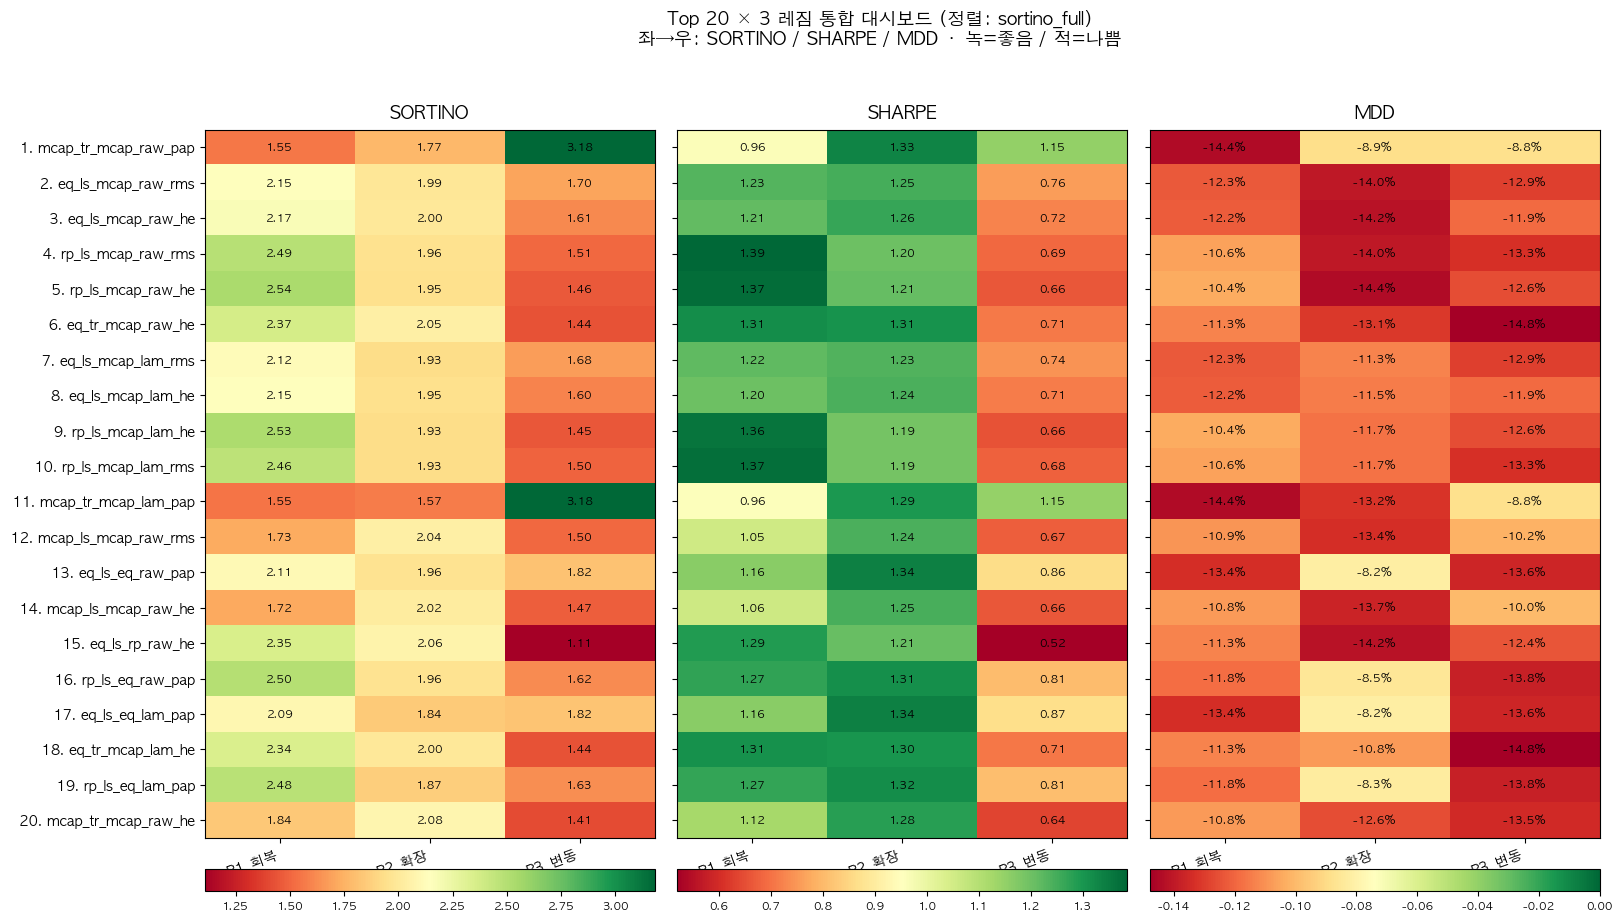

In [271]:
# ── K2-M. 전체기간 Sortino Top 20 통합 대시보드 + 두 정렬 교집합 ─────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

print('=== K2-M. 전체기간 Sortino 정렬 Top 20 대시보드 ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

# rt에 mt의 전체기간 sortino를 병합 → 그 컬럼으로 정렬
rt_sm = rt.merge(mt[['name','sortino']].rename(columns={'sortino':'sortino_full'}),
                 on='name', how='left')

_ = plot_styled_regime_dashboard(
    rt_sm, rank_by='sortino_full', top_n=20,
    save_path=OUT_DIR / 'K2M_sortino_full_dashboard.png',
)

top20_sm = rt_sm.nlargest(20, 'sortino_full').reset_index(drop=True); top20_sm.index += 1
print('\n■ K2-M 행 매핑 (전체기간 sortino 큰 순)')
display(top20_sm[['canonical','sortino_full','sortino_mean','sortino_ir','mdd_worst','sharpe']].round(3))

# 전체기간 Sortino Top 20 ∩ Sortino IR Top 20 = 단순 평균·안정성 모두 강한 후보
print('\n■ 전체기간 Sortino Top 20 ∩ Sortino IR Top 20 = 통합 우위·안정성 모두 강한 후보')
set_sf = set(top20_sm['canonical'])
set_si = set(rt.nlargest(20, 'sortino_ir')['canonical'])
inter_sf_si = set_sf & set_si
print(f'  교집합: {len(inter_sf_si)}개')
if inter_sf_si:
    display(rt_sm[rt_sm['canonical'].isin(inter_sf_si)].sort_values('sortino_full', ascending=False)
              [['canonical','sortino_full','sortino_ir','sortino_mean','mdd_worst','sharpe']]
              .round(3))


## K2-MT. 전체기간 Sortino Top 20 — 전체기간 메트릭 표

K2-M 대시보드 후보(전체기간 `mt['sortino']` 정렬 Top 20)를 **전체기간 단일 수치**로 정리. 정렬 기준과 표시 기준이 일치하므로 Sortino 컬럼이 단조 감소.

메트릭: Sharpe / Sortino / CAGR / 변동성 / MDD / Beta / Alpha (모두 TC 차감 후)


In [272]:
# ── K2-MT. 전체기간 Sortino Top 20 — 전체기간 메트릭 표 ───────────────
# 표시 메트릭: Sharpe / Sortino / Sortino_IR / CAGR / 변동성(Vol) / MDD / Beta / Alpha
# 정렬 기준 = 표시되는 Sortino 컬럼과 동일 (mt['sortino']) → 단조 감소
# Sortino_IR은 rt에서 병합 (안정성 지표 동시 표시)

top20_sm_names = mt.nlargest(20, 'sortino')['name'].tolist()
summary_sm = mt[mt['name'].isin(top20_sm_names)].copy()
# rt에서 sortino_ir 병합
summary_sm = summary_sm.merge(rt[['name', 'sortino_ir']], on='name', how='left')
# 정렬 순서 유지
summary_sm['_order'] = summary_sm['name'].map({n: i for i, n in enumerate(top20_sm_names)})
summary_sm = summary_sm.sort_values('_order').drop(columns='_order')

# 헤더
header = '=' * 102
sep    = '-' * 102
print(header)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)

# 행 출력 (canonical 표시)
for _, r in summary_sm.iterrows():
    name   = r['canonical'][:31]
    sh     = f'{r["sharpe"]:.3f}'
    so     = f'{r["sortino"]:.3f}'
    sir    = f'{r["sortino_ir"]:.2f}'  if pd.notna(r.get('sortino_ir')) else '-'
    cagr   = f'{r["cagr"]*100:.2f}%'
    vol    = f'{r["vol"]*100:.2f}%'
    mdd    = f'{r["mdd"]*100:.2f}%'
    beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{name:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')

print(header)

# 비교군도 함께 (참고)
print('\n■ 비교군 4종 — 전체기간')
print(sep)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)
for nm in ['baseline','capm_no_bl','naive_lowvol']:
    r = mt[mt['name']==nm].iloc[0]
    rt_r = rt[rt['name']==nm]
    sir_val = rt_r['sortino_ir'].iloc[0] if len(rt_r) > 0 and pd.notna(rt_r['sortino_ir'].iloc[0]) else None
    name   = nm[:31]
    sh     = f'{r["sharpe"]:.3f}'
    so     = f'{r["sortino"]:.3f}'
    sir    = f'{sir_val:.2f}' if sir_val is not None else '-'
    cagr   = f'{r["cagr"]*100:.2f}%'
    vol    = f'{r["vol"]*100:.2f}%'
    mdd    = f'{r["mdd"]*100:.2f}%'
    beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{name:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')

# SPY 별도 계산
from bl_functions import compute_metrics
from master_table import REGIMES as _REGIMES_K2MT
spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
_spy_sortinos = []
for _lbl, _s, _e in _REGIMES_K2MT:
    _seg = spy_ret.loc[_s:_e]
    if len(_seg) >= 3:
        _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
        if pd.notna(_m.get('sortino')):
            _spy_sortinos.append(_m['sortino'])
_spy_sir = np.mean(_spy_sortinos) / np.std(_spy_sortinos) if len(_spy_sortinos) >= 2 and np.std(_spy_sortinos) > 0 else None
_spy_sir_s = f'{_spy_sir:.2f}' if _spy_sir is not None else '-'
print(f'{"SPY":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_sir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
print(header)


실험명                               Sharpe  Sortino Sortino_IR    CAGR     변동성      MDD    Beta   Alpha
------------------------------------------------------------------------------------------------------
mcap_tr_mcap_raw_pap               1.162    1.944       3.01  15.70%  12.48%  -14.35%   0.699   5.54%
eq_ls_mcap_raw_rms                 1.069    1.927      10.52  13.80%  11.92%  -14.04%   0.535   5.91%
eq_ls_mcap_raw_he                  1.060    1.905       8.20  13.73%  11.97%  -14.19%   0.541   5.77%
rp_ls_mcap_raw_rms                 1.049    1.891       4.94  13.24%  11.64%  -14.01%   0.503   5.79%
rp_ls_mcap_raw_he                  1.044    1.884       4.48  13.21%  11.68%  -14.37%   0.506   5.74%
eq_tr_mcap_raw_he                  1.076    1.864       5.04  13.66%  11.70%  -14.79%   0.545   5.63%
eq_ls_mcap_lam_rms                 1.045    1.859      10.54  13.21%  11.66%  -12.89%   0.551   5.15%
eq_ls_mcap_lam_he                  1.034    1.850       8.29  13.10%  11.69%  -12

## K2-X50. Sortino IR ∩ 전체기간 Sortino Top 50 — 확장 교집합

K2-X(Top 20 교집합)는 양쪽 기준 모두에서 상위 12.8% 안에 든 후보만 잡아 매우 보수적.
Top 50으로 넓히면 (전체 ~156개 중 32%) **"두 관점에서 모두 평균 이상"인 robust 후보군**을 더 풍부하게 확보.

→ 후보 풀 확장으로 슬롯 패턴(prior/p/q/omega)의 안정 영역을 더 잘 드러냄.


■ 교집합 크기: 23개 (sortino_ir Top50 ∩ sortino_full Top50)
  · sortino_ir만 Top50: 27개
  · sortino_full만 Top50: 27개
  · 둘 다 Top50: 23개

=== K2-X50-A. 교집합 23개 — 3 metric × 3 레짐 히트맵 (sortino_full 정렬) ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ K2-X50 행 매핑 (sortino_full 큰 순)


,name,canonical,sortino_full,sortino_ir,sortino_mean,sortino_std,mdd_worst,sharpe
1,mat_eq_mcap_raw_rms,eq_ls_mcap_raw_rms,1.927,10.52,1.947,0.185,-0.140,1.069
2,mat_eq_mcap_raw_he,eq_ls_mcap_raw_he,1.905,8.20,1.928,0.235,-0.142,1.060
3,mat_eq_mcap_lam_rms,eq_ls_mcap_lam_rms,1.859,10.54,1.908,0.181,-0.129,1.045
4,mat_eq_mcap_lam_he,eq_ls_mcap_lam_he,1.850,8.29,1.898,0.229,-0.122,1.034
5,mat_mcap_mcap_raw_rms,mcap_ls_mcap_raw_rms,1.835,7.96,1.759,0.221,-0.134,1.017
6,mat_eq_eq_raw_pap,eq_ls_eq_raw_pap,1.826,16.50,1.963,0.119,-0.136,1.096
7,mat_mcap_mcap_raw_he,mcap_ls_mcap_raw_he,1.825,7.72,1.736,0.225,-0.137,1.015
8,mat_rp_eq_raw_pap,rp_ls_eq_raw_pap,1.819,5.62,2.028,0.361,-0.138,1.093
9,mat_eq_eq_lam_pap,eq_ls_eq_lam_pap,1.816,15.98,1.918,0.120,-0.136,1.102
10,q_raw_lam,mcap_tr_mcap_raw_he,1.807,6.39,1.777,0.278,-0.135,1.019



=== K2-X50-B. 교집합 23개 — 전체기간 메트릭 표 ===
pkl                             canonical                         Sharpe  Sortino Sortino_IR    CAGR     변동성      MDD    Beta   Alpha
--------------------------------------------------------------------------------------------------------------------------------------
mat_eq_mcap_raw_rms             eq_ls_mcap_raw_rms                 1.069    1.927      10.52  13.80%  11.92%  -14.04%   0.535   5.91%
mat_eq_mcap_raw_he              eq_ls_mcap_raw_he                  1.060    1.905       8.20  13.73%  11.97%  -14.19%   0.541   5.77%
mat_eq_mcap_lam_rms             eq_ls_mcap_lam_rms                 1.045    1.859      10.54  13.21%  11.66%  -12.89%   0.551   5.15%
mat_eq_mcap_lam_he              eq_ls_mcap_lam_he                  1.034    1.850       8.29  13.10%  11.69%  -12.17%   0.556   4.99%
mat_mcap_mcap_raw_rms           mcap_ls_mcap_raw_rms               1.017    1.835       7.96  12.69%  11.52%  -13.43%   0.511   5.19%
mat_eq_eq_raw_pap    

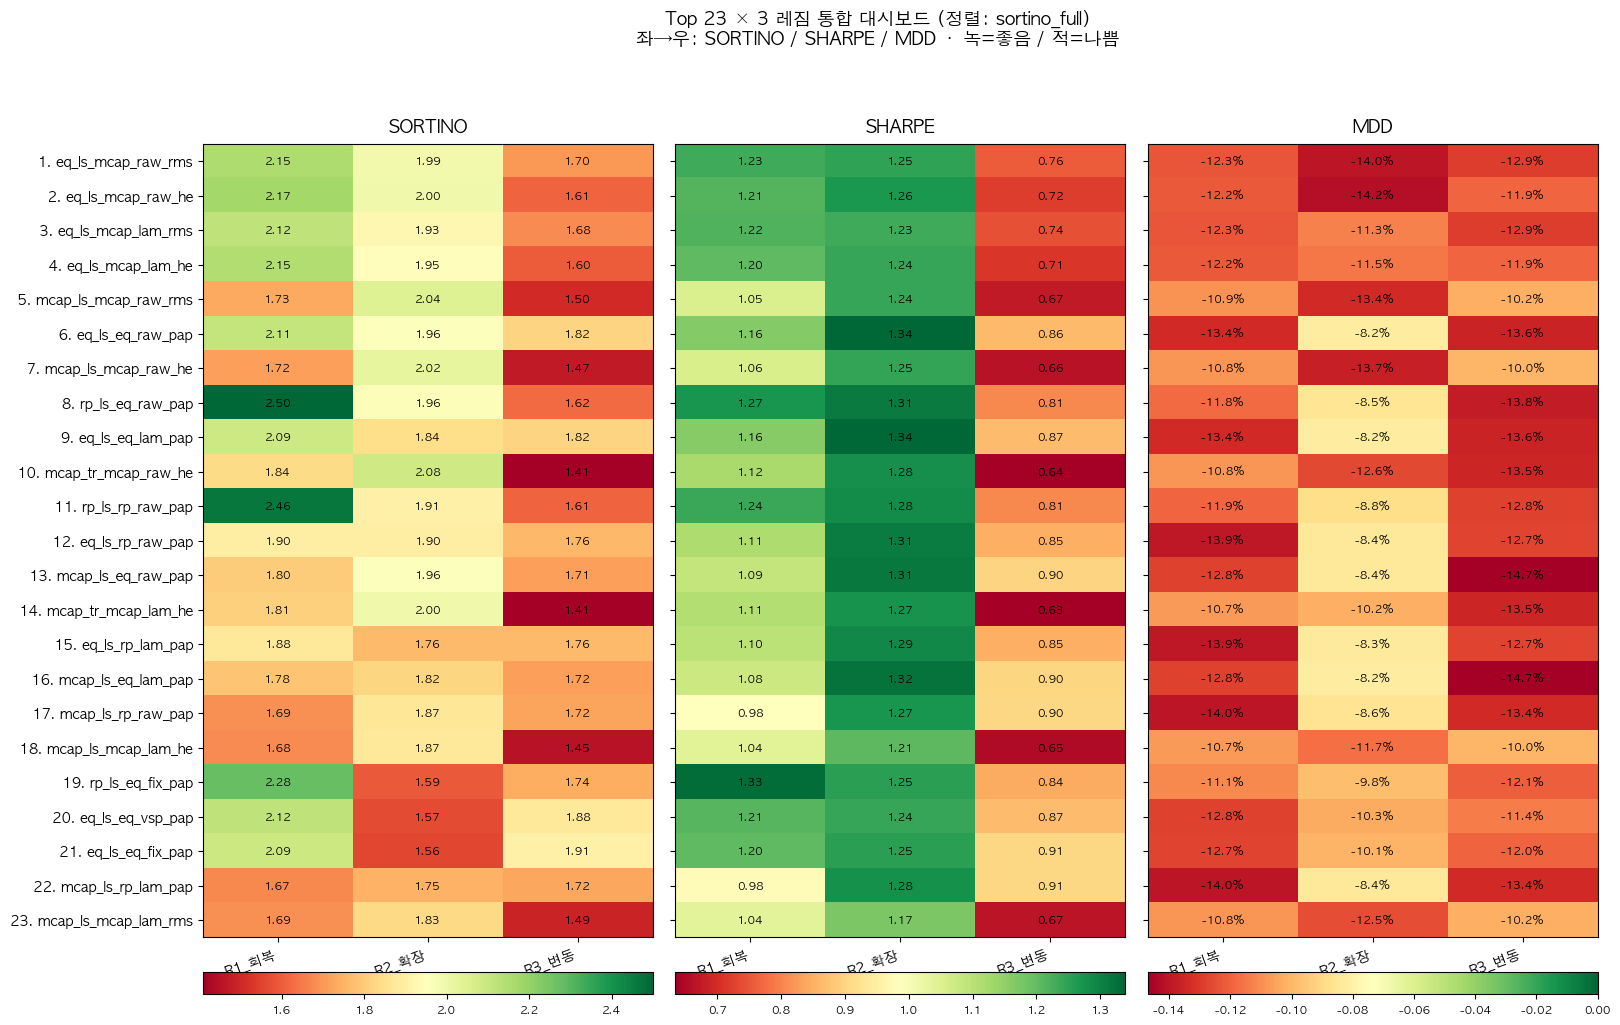

In [273]:
# ── K2-X50. Sortino IR ∩ 전체기간 Sortino Top 50 — 확장 교집합 ─────
# K2-X와 동일 로직, 단 N=50으로 확장.
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

N = 50
top50_si_names = set(rt.nlargest(N, 'sortino_ir')['name'])
top50_sf_names = set(rt_sm.nlargest(N, 'sortino_full')['name'])
inter50_names  = top50_si_names & top50_sf_names
n_inter50      = len(inter50_names)

print(f'■ 교집합 크기: {n_inter50}개 (sortino_ir Top{N} ∩ sortino_full Top{N})')
print(f'  · sortino_ir만 Top{N}: {len(top50_si_names - top50_sf_names)}개')
print(f'  · sortino_full만 Top{N}: {len(top50_sf_names - top50_si_names)}개')
print(f'  · 둘 다 Top{N}: {n_inter50}개')

if n_inter50 == 0:
    print('  → 교집합 없음.')
else:
    rt_inter50 = rt_sm[rt_sm['name'].isin(inter50_names)].copy()

    # ── (1) 히트맵 대시보드 ──────────────────────────────────────
    print(f'\n=== K2-X50-A. 교집합 {n_inter50}개 — 3 metric × 3 레짐 히트맵 (sortino_full 정렬) ===')
    print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')
    _ = plot_styled_regime_dashboard(
        rt_inter50, rank_by='sortino_full', top_n=n_inter50,
        save_path=OUT_DIR / 'K2X50_intersection_dashboard.png',
    )

    # 행 매핑 (pkl name 포함)
    inter50_top = rt_inter50.nlargest(n_inter50, 'sortino_full').reset_index(drop=True); inter50_top.index += 1
    print(f'\n■ K2-X50 행 매핑 (sortino_full 큰 순)')
    display(inter50_top[['name','canonical','sortino_full','sortino_ir','sortino_mean','sortino_std','mdd_worst','sharpe']].round(3))

    # ── (2) 전체기간 메트릭 표 (pkl 파일명 + canonical 같이) ─────
    # Sortino_IR 컬럼 추가 (rt에서 병합)
    print(f'\n=== K2-X50-B. 교집합 {n_inter50}개 — 전체기간 메트릭 표 ===')
    inter50_ordered = rt_inter50.nlargest(n_inter50, 'sortino_full')['name'].tolist()
    summary50 = mt[mt['name'].isin(inter50_ordered)].copy()
    summary50 = summary50.merge(rt[['name', 'sortino_ir']], on='name', how='left')
    summary50['_order'] = summary50['name'].map({n: i for i, n in enumerate(inter50_ordered)})
    summary50 = summary50.sort_values('_order').drop(columns='_order')

    header = '=' * 134
    sep    = '-' * 134
    print(header)
    print(f'{"pkl":<32}{"canonical":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
    print(sep)
    for _, r in summary50.iterrows():
        pkl    = str(r['name'])[:31]
        canon  = str(r['canonical'])[:31]
        sh     = f'{r["sharpe"]:.3f}'
        so     = f'{r["sortino"]:.3f}'
        sir    = f'{r["sortino_ir"]:.2f}'  if pd.notna(r.get('sortino_ir')) else '-'
        cagr   = f'{r["cagr"]*100:.2f}%'
        vol    = f'{r["vol"]*100:.2f}%'
        mdd    = f'{r["mdd"]*100:.2f}%'
        beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
        alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
        print(f'{pkl:<32}{canon:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')
    print(header)

    # 비교군도 함께 (참고)
    print('\n■ 비교군 4종 — 전체기간')
    print(sep)
    print(f'{"pkl":<32}{"canonical":<32}{"Sharpe":>8}{"Sortino":>9}{"Sortino_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
    print(sep)
    for nm in ['baseline','capm_no_bl','naive_lowvol']:
        r = mt[mt['name']==nm].iloc[0]
        rt_r = rt[rt['name']==nm]
        sir_val = rt_r['sortino_ir'].iloc[0] if len(rt_r) > 0 and pd.notna(rt_r['sortino_ir'].iloc[0]) else None
        pkl    = nm[:31]
        canon  = str(r['canonical'])[:31]
        sh     = f'{r["sharpe"]:.3f}'
        so     = f'{r["sortino"]:.3f}'
        sir    = f'{sir_val:.2f}' if sir_val is not None else '-'
        cagr   = f'{r["cagr"]*100:.2f}%'
        vol    = f'{r["vol"]*100:.2f}%'
        mdd    = f'{r["mdd"]*100:.2f}%'
        beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
        alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
        print(f'{pkl:<32}{canon:<32}{sh:>8}{so:>9}{sir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')

    from bl_functions import compute_metrics
    from master_table import REGIMES as _REGIMES_K2X50
    spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
    _spy_sortinos = []
    for _lbl, _s, _e in _REGIMES_K2X50:
        _seg = spy_ret.loc[_s:_e]
        if len(_seg) >= 3:
            _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
            if pd.notna(_m.get('sortino')):
                _spy_sortinos.append(_m['sortino'])
    _spy_sir = np.mean(_spy_sortinos) / np.std(_spy_sortinos) if len(_spy_sortinos) >= 2 and np.std(_spy_sortinos) > 0 else None
    _spy_sir_s = f'{_spy_sir:.2f}' if _spy_sir is not None else '-'
    print(f'{"SPY":<32}{"(market passive)":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_sir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
    print(header)

    # ── (3) 슬롯 패턴 빠른 집계 ──────────────────────────────────
    print(f'\n=== K2-X50-C. 교집합 {n_inter50}개 슬롯 패턴 ===')
    for slot in ['prior_s','p_s','pw_s','q_s','om_s']:
        if slot in summary50.columns:
            vc = summary50[slot].value_counts()
            print(f'  [{slot}] ' + ' / '.join(f'{k}={v}' for k,v in vc.items()))


## K2-SI. Sharpe IR Top 20 통합 대시보드 (Sortino-IR Top 20과 동등 비교)

`sortino_ir`(K2-A) 정렬과 별개로 **`sharpe_ir = sharpe_mean / sharpe_std`** 기준으로 Top 20 추출.
3 metric (sortino, sharpe, mdd) per 레짐 히트맵으로 시각화.

→ Sortino 안정성(K2-A) ↔ Sharpe 안정성(K2-SI) 두 측면 동시 점검.

■ 레짐별 Sharpe — 핵심 비교군 4종
레짐               SPY   baseline   capm_no_bl   naive_low
--------------------------------------------------------
R1_회복           0.81       1.20         0.60        1.15
R2_확장           1.23       1.35         1.21        1.31
R3_변동           0.60       0.63         0.67        0.54


=== K2-SI. Sharpe IR 정렬 Top 20 대시보드 ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ K2-SI 행 매핑 (sharpe_ir 큰 순)


,canonical,sharpe_ir,sharpe_mean,sharpe_std,sortino_ir,mdd_worst
1,mcap_ls_mcap_fix_pap,24.37,0.926,0.038,3.62,-0.170
2,mcap_ls_mcap_lam_pap,15.59,0.904,0.058,3.99,-0.167
3,eq_ls_mcap_lam_pap,15.19,0.942,0.062,5.48,-0.181
4,mcap_ls_mcap_vsp_pap,11.41,0.936,0.082,4.25,-0.167
5,eq_ls_mcap_fix_pap,9.57,0.947,0.099,5.58,-0.169
6,mcap_ls_mcap_inv_pap,8.94,1.001,0.112,5.53,-0.158
7,rp_ls_mcap_lam_pap,8.84,0.972,0.110,6.68,-0.167
8,mcap_ls_rp_fix_pap,8.72,1.020,0.117,11.59,-0.141
9,mcap_tr_mcap_lam_pap,8.27,1.133,0.137,2.75,-0.144
10,eq_ls_mcap_vsp_pap,8.27,0.959,0.116,5.62,-0.173



■ Sortino IR Top 20 ∩ Sharpe IR Top 20 = 두 측면 모두 강한 후보
  교집합: 5개


,canonical,sortino_ir,sharpe_ir,sortino_mean,mdd_worst,sharpe
79,mcap_ls_rp_vsp_pap,13.57,8.00,1.628,-0.140,1.014
65,mcap_ls_eq_vsp_pap,13.03,7.57,1.694,-0.137,1.059
63,mcap_ls_eq_fix_pap,12.21,7.78,1.709,-0.137,1.073
77,mcap_ls_rp_fix_pap,11.59,8.72,1.657,-0.141,1.017
57,rp_ls_mcap_raw_pap,9.93,8.09,1.727,-0.144,0.997


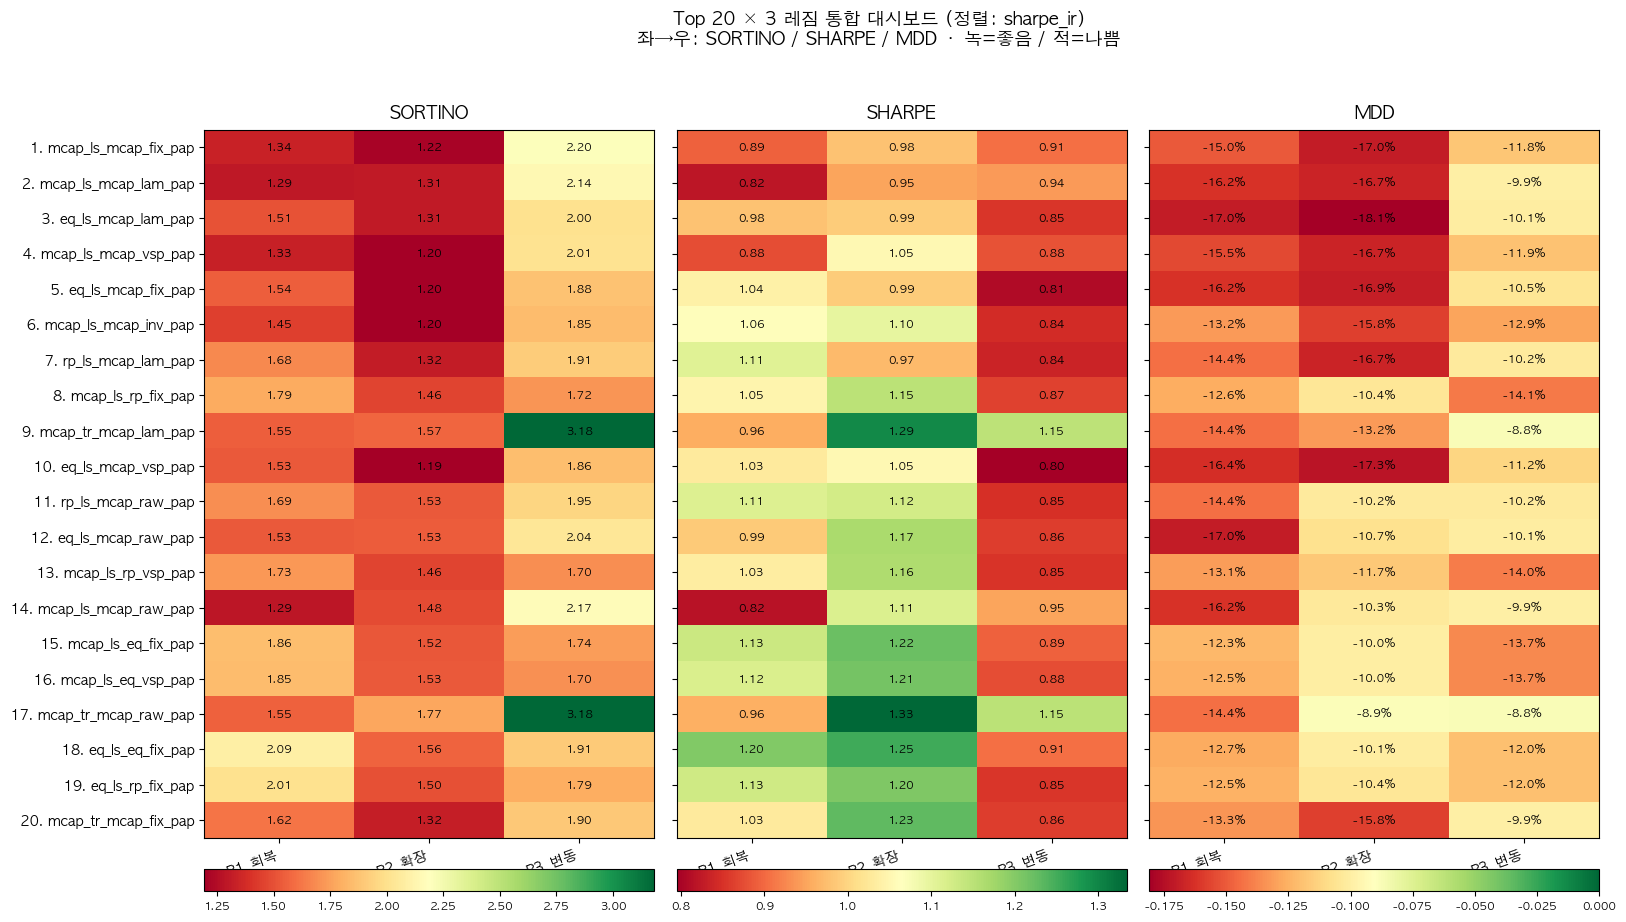

In [274]:
# ── K2-SI. Sharpe IR Top 20 통합 대시보드 ───────────────────────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

# 비교군 레짐별 Sharpe (히트맵 해석 보조용)
print('■ 레짐별 Sharpe — 핵심 비교군 4종')
print(f'{"레짐":<12} {"SPY":>7} {"baseline":>10} {"capm_no_bl":>12} {"naive_low":>11}')
print('-' * 56)
for lbl, s, e in REGIMES:
    sm = regime_metrics(spy_ret,           rf, s, e)['sharpe']
    bm = regime_metrics(baseline_ret,      rf, s, e)['sharpe']
    cm = regime_metrics(capm_no_bl_ret,    rf, s, e)['sharpe']
    nm = regime_metrics(naive_lowvol_ret,  rf, s, e)['sharpe']
    print(f'{lbl:<12} {sm:>7.2f} {bm:>10.2f} {cm:>12.2f} {nm:>11.2f}')

print('\n\n=== K2-SI. Sharpe IR 정렬 Top 20 대시보드 ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

_ = plot_styled_regime_dashboard(
    rt, rank_by='sharpe_ir', top_n=20,
    save_path=OUT_DIR / 'K2SI_sharpe_ir_dashboard.png',
)

top20_sh = rt.nlargest(20, 'sharpe_ir').reset_index(drop=True); top20_sh.index += 1
print('\n■ K2-SI 행 매핑 (sharpe_ir 큰 순)')
display(top20_sh[['canonical','sharpe_ir','sharpe_mean','sharpe_std','sortino_ir','mdd_worst']].round(3))

# Sortino IR ∩ Sharpe IR Top 20 교집합
print('\n■ Sortino IR Top 20 ∩ Sharpe IR Top 20 = 두 측면 모두 강한 후보')
set_so = set(rt.nlargest(20, 'sortino_ir')['canonical'])
set_sh = set(top20_sh['canonical'])
inter_ir = set_so & set_sh
print(f'  교집합: {len(inter_ir)}개')
if inter_ir:
    display(rt[rt['canonical'].isin(inter_ir)].sort_values('sortino_ir', ascending=False)
              [['canonical','sortino_ir','sharpe_ir','sortino_mean','mdd_worst','sharpe']]
              .round(3))


## K2-SIT. Sharpe IR Top 20 — 전체기간 메트릭 표

K2-SI 대시보드 후보(sharpe_ir 정렬 Top 20)를 **전체기간 단일 수치**로 정리. 발표·보고용.

메트릭: Sharpe / Sortino / Sharpe_IR / CAGR / 변동성 / MDD / Beta / Alpha (모두 TC 차감 후)

In [275]:
# ── K2-SIT. Sharpe IR Top 20 — 전체기간 메트릭 표 ──────────────────
# 표시 메트릭: Sharpe / Sortino / Sharpe_IR / CAGR / 변동성(Vol) / MDD / Beta / Alpha
# Sharpe_IR (= sharpe_mean / sharpe_std, rt에서 가져옴): 3 레짐 안정성 지표

top20_sh_names = rt.nlargest(20, 'sharpe_ir')['name'].tolist()
summary_sh = mt[mt['name'].isin(top20_sh_names)].copy()
summary_sh = summary_sh.merge(rt[['name', 'sharpe_ir']], on='name', how='left')
summary_sh['_order'] = summary_sh['name'].map({n: i for i, n in enumerate(top20_sh_names)})
summary_sh = summary_sh.sort_values('_order').drop(columns='_order')

header = '=' * 102
sep    = '-' * 102
print(header)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sharpe_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)

for _, r in summary_sh.iterrows():
    name   = r['canonical'][:31]
    sh     = f'{r["sharpe"]:.3f}'
    so     = f'{r["sortino"]:.3f}'
    shir   = f'{r["sharpe_ir"]:.2f}'  if pd.notna(r.get('sharpe_ir')) else '-'
    cagr   = f'{r["cagr"]*100:.2f}%'
    vol    = f'{r["vol"]*100:.2f}%'
    mdd    = f'{r["mdd"]*100:.2f}%'
    beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{name:<32}{sh:>8}{so:>9}{shir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')
print(header)

# 비교군
print('\n■ 비교군 4종 — 전체기간')
print(sep)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sharpe_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)
for nm in ['baseline','capm_no_bl','naive_lowvol']:
    r = mt[mt['name']==nm].iloc[0]
    rt_r = rt[rt['name']==nm]
    shir_val = rt_r['sharpe_ir'].iloc[0] if len(rt_r) > 0 and pd.notna(rt_r['sharpe_ir'].iloc[0]) else None
    print(f'{nm[:31]:<32}{r["sharpe"]:>8.3f}{r["sortino"]:>9.3f}'
          f'{(f"{shir_val:.2f}" if shir_val is not None else "-"):>11}'
          f'{r["cagr"]*100:>7.2f}%{r["vol"]*100:>7.2f}%{r["mdd"]*100:>8.2f}%'
          f'{(f"{r["beta"]:.3f}" if pd.notna(r["beta"]) else "-"):>8}'
          f'{(f"{r["alpha"]*100:.2f}%" if pd.notna(r["alpha"]) else "-"):>8}')

# SPY
from bl_functions import compute_metrics
spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
_spy_sharpes = []
for _lbl, _s, _e in REGIMES:
    _seg = spy_ret.loc[_s:_e]
    if len(_seg) >= 3:
        _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
        if pd.notna(_m.get('sharpe')):
            _spy_sharpes.append(_m['sharpe'])
_spy_shir = np.mean(_spy_sharpes) / np.std(_spy_sharpes) if len(_spy_sharpes) >= 2 and np.std(_spy_sharpes) > 0 else None
_spy_shir_s = f'{_spy_shir:.2f}' if _spy_shir is not None else '-'
print(f'{"SPY":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_shir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
print(header)


실험명                               Sharpe  Sortino  Sharpe_IR    CAGR     변동성      MDD    Beta   Alpha
------------------------------------------------------------------------------------------------------
mcap_ls_mcap_fix_pap               0.923    1.432      24.37  13.24%  13.53%  -17.00%   0.820   1.95%
mcap_ls_mcap_lam_pap               0.906    1.488      15.59  12.87%  13.40%  -16.73%   0.777   2.16%
eq_ls_mcap_lam_pap                 0.915    1.523      15.19  13.72%  14.18%  -18.11%   0.808   2.62%
mcap_ls_mcap_vsp_pap               0.941    1.404      11.41  13.44%  13.44%  -16.67%   0.829   2.01%
eq_ls_mcap_fix_pap                 0.908    1.437       9.57  13.82%  14.43%  -16.94%   0.861   2.06%
mcap_ls_mcap_inv_pap               0.985    1.394       8.94  14.21%  13.54%  -15.84%   0.847   2.47%
rp_ls_mcap_lam_pap                 0.930    1.535       8.84  13.19%  13.32%  -16.70%   0.745   2.85%
mcap_ls_rp_fix_pap                 1.017    1.566       8.72  14.45%  13.31%  -14

## K2-SF. 전체기간 Sharpe 정렬 Top 20 × 3 metric 히트맵

`sharpe_ir`(mean/std, K2-SI) 정렬과 별개로 **전체기간 단일 Sharpe** (`mt['sharpe']`, 168m 통합) 기준 Top 20.

→ "안정성"이나 "레짐 평균"이 아니라 **전 기간 통합 위험조정 수익률**이 가장 큰 후보.
→ K2-A(sortino_ir) / K2-M(전체 sortino) / K2-SI(sharpe_ir) / 여기(전체 sharpe) 4 관점 비교.

=== K2-SF. 전체기간 Sharpe 정렬 Top 20 대시보드 ===
  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨

■ K2-SF 행 매핑 (전체기간 sharpe 큰 순)


,canonical,sharpe_full,sharpe_mean,sharpe_ir,mdd_worst,sortino
1,mcap_tr_mcap_raw_pap,1.162,1.148,7.55,-0.144,1.944
2,mcap_tr_mcap_lam_pap,1.151,1.133,8.27,-0.144,1.841
3,mcap_ls_eq_lam_pap,1.106,1.100,6.43,-0.147,1.742
4,eq_ls_eq_lam_pap,1.102,1.122,5.75,-0.136,1.816
5,rp_ls_eq_lam_pap,1.099,1.131,4.94,-0.138,1.808
6,mcap_ls_eq_raw_pap,1.099,1.100,6.51,-0.147,1.775
7,eq_ls_eq_raw_pap,1.096,1.122,5.72,-0.136,1.826
8,rp_ls_eq_fix_pap,1.096,1.142,5.39,-0.121,1.711
9,rp_ls_eq_raw_pap,1.093,1.130,4.91,-0.138,1.819
10,eq_ls_eq_fix_pap,1.091,1.120,7.32,-0.127,1.709



■ 전체기간 Sharpe Top 20 ∩ Sharpe IR Top 20 = 통합 우위·안정성 모두 강한 후보
  교집합: 4개


,canonical,sharpe_full,sharpe_ir,sharpe_mean,mdd_worst,sortino
0,mcap_tr_mcap_raw_pap,1.162,7.55,1.148,-0.144,1.944
10,mcap_tr_mcap_lam_pap,1.151,8.27,1.133,-0.144,1.841
44,eq_ls_eq_fix_pap,1.091,7.32,1.120,-0.127,1.709
63,mcap_ls_eq_fix_pap,1.073,7.78,1.082,-0.137,1.624


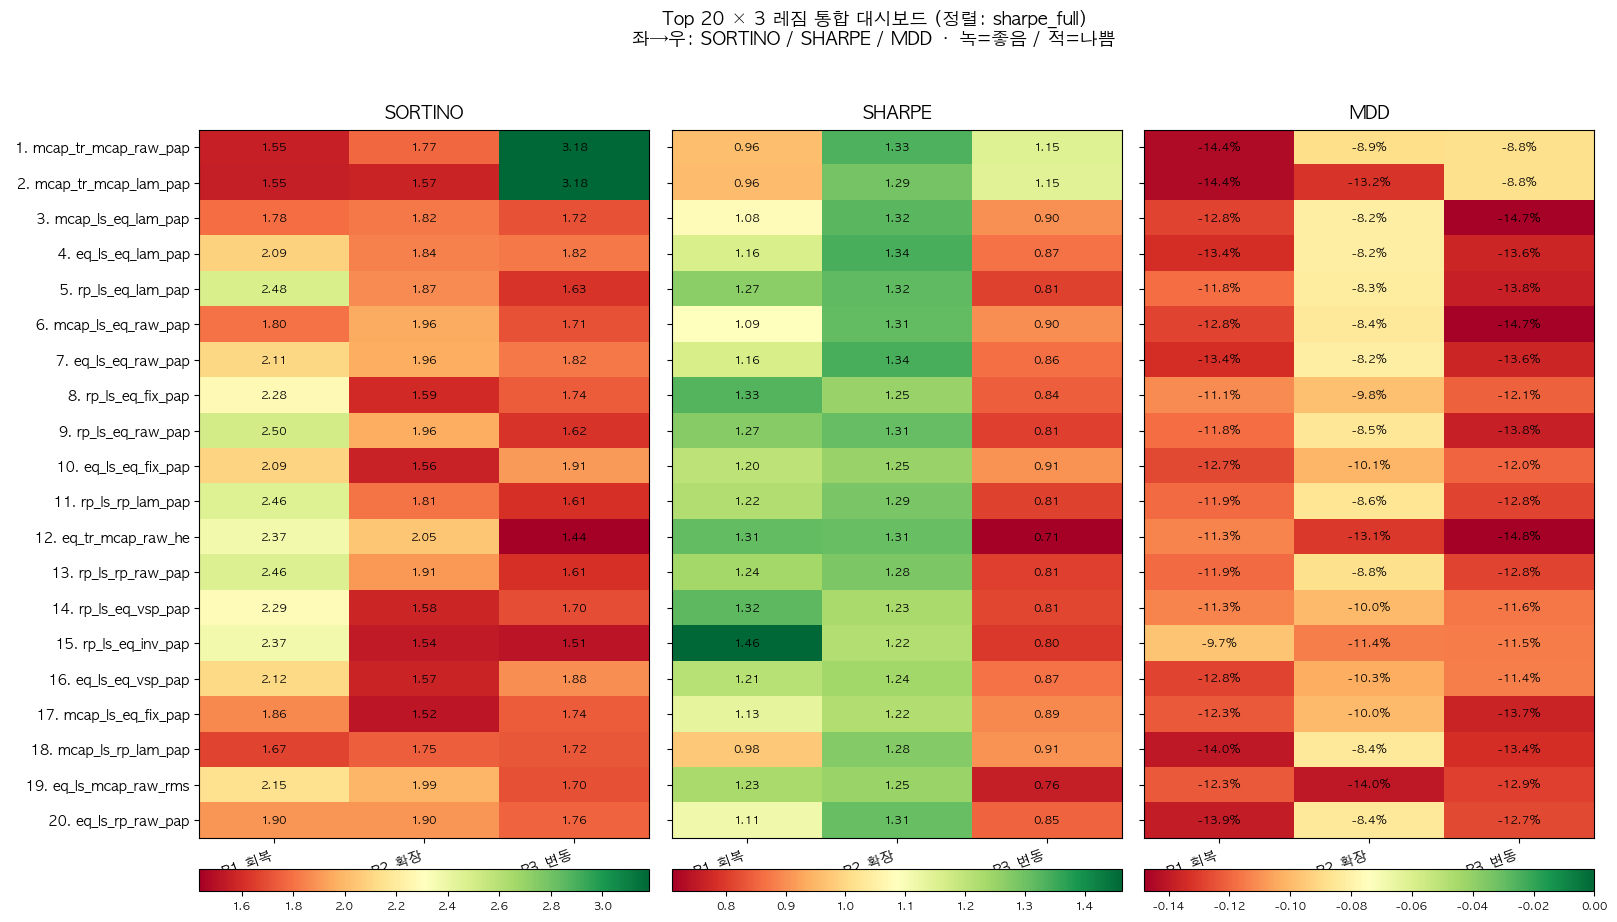

In [276]:
# ── K2-SF. 전체기간 Sharpe Top 20 통합 대시보드 + 두 정렬 교집합 ─────
import importlib, master_table, analyze_plots
importlib.reload(master_table); importlib.reload(analyze_plots)
from analyze_plots import plot_styled_regime_dashboard

print('=== K2-SF. 전체기간 Sharpe 정렬 Top 20 대시보드 ===')
print('  → 좌:SORTINO / 가운데:SHARPE / 우:MDD  ·  녹=좋음, 적=나쁨')

# rt에 mt의 전체기간 sharpe를 sharpe_full로 병합
rt_shf = rt.merge(mt[['name','sharpe']].rename(columns={'sharpe':'sharpe_full'}),
                  on='name', how='left')

_ = plot_styled_regime_dashboard(
    rt_shf, rank_by='sharpe_full', top_n=20,
    save_path=OUT_DIR / 'K2SF_sharpe_full_dashboard.png',
)

top20_shf = rt_shf.nlargest(20, 'sharpe_full').reset_index(drop=True); top20_shf.index += 1
print('\n■ K2-SF 행 매핑 (전체기간 sharpe 큰 순)')
display(top20_shf[['canonical','sharpe_full','sharpe_mean','sharpe_ir','mdd_worst','sortino']].round(3))

# 전체기간 Sharpe Top 20 ∩ Sharpe IR Top 20 = 통합 우위·안정성 모두 강한 후보
print('\n■ 전체기간 Sharpe Top 20 ∩ Sharpe IR Top 20 = 통합 우위·안정성 모두 강한 후보')
set_shf = set(top20_shf['canonical'])
set_shir = set(rt.nlargest(20, 'sharpe_ir')['canonical'])
inter_shf_shir = set_shf & set_shir
print(f'  교집합: {len(inter_shf_shir)}개')
if inter_shf_shir:
    display(rt_shf[rt_shf['canonical'].isin(inter_shf_shir)].sort_values('sharpe_full', ascending=False)
              [['canonical','sharpe_full','sharpe_ir','sharpe_mean','mdd_worst','sortino']]
              .round(3))


## K2-SFT. 전체기간 Sharpe Top 20 — 전체기간 메트릭 표

K2-SF 대시보드 후보(전체기간 `mt['sharpe']` 정렬 Top 20)를 **전체기간 단일 수치**로 정리. 정렬 기준과 표시 기준이 일치하므로 Sharpe 컬럼이 단조 감소.

메트릭: Sharpe / Sortino / Sharpe_IR / CAGR / 변동성 / MDD / Beta / Alpha (모두 TC 차감 후)

In [277]:
# ── K2-SFT. 전체기간 Sharpe Top 20 — 전체기간 메트릭 표 ───────────────
# 표시 메트릭: Sharpe / Sortino / Sharpe_IR / CAGR / 변동성(Vol) / MDD / Beta / Alpha
# 정렬 기준 = 표시되는 Sharpe 컬럼과 동일 (mt['sharpe']) → 단조 감소

top20_shf_names = mt.nlargest(20, 'sharpe')['name'].tolist()
summary_shf = mt[mt['name'].isin(top20_shf_names)].copy()
summary_shf = summary_shf.merge(rt[['name', 'sharpe_ir']], on='name', how='left')
summary_shf['_order'] = summary_shf['name'].map({n: i for i, n in enumerate(top20_shf_names)})
summary_shf = summary_shf.sort_values('_order').drop(columns='_order')

header = '=' * 102
sep    = '-' * 102
print(header)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sharpe_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)

for _, r in summary_shf.iterrows():
    name   = r['canonical'][:31]
    sh     = f'{r["sharpe"]:.3f}'
    so     = f'{r["sortino"]:.3f}'
    shir   = f'{r["sharpe_ir"]:.2f}'  if pd.notna(r.get('sharpe_ir')) else '-'
    cagr   = f'{r["cagr"]*100:.2f}%'
    vol    = f'{r["vol"]*100:.2f}%'
    mdd    = f'{r["mdd"]*100:.2f}%'
    beta   = f'{r["beta"]:.3f}'  if pd.notna(r['beta'])  else '-'
    alpha  = f'{r["alpha"]*100:.2f}%' if pd.notna(r['alpha']) else '-'
    print(f'{name:<32}{sh:>8}{so:>9}{shir:>11}{cagr:>8}{vol:>8}{mdd:>9}{beta:>8}{alpha:>8}')
print(header)

# 비교군
print('\n■ 비교군 4종 — 전체기간')
print(sep)
print(f'{"실험명":<32}{"Sharpe":>8}{"Sortino":>9}{"Sharpe_IR":>11}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}')
print(sep)
for nm in ['baseline','capm_no_bl','naive_lowvol']:
    r = mt[mt['name']==nm].iloc[0]
    rt_r = rt[rt['name']==nm]
    shir_val = rt_r['sharpe_ir'].iloc[0] if len(rt_r) > 0 and pd.notna(rt_r['sharpe_ir'].iloc[0]) else None
    print(f'{nm[:31]:<32}{r["sharpe"]:>8.3f}{r["sortino"]:>9.3f}'
          f'{(f"{shir_val:.2f}" if shir_val is not None else "-"):>11}'
          f'{r["cagr"]*100:>7.2f}%{r["vol"]*100:>7.2f}%{r["mdd"]*100:>8.2f}%'
          f'{(f"{r["beta"]:.3f}" if pd.notna(r["beta"]) else "-"):>8}'
          f'{(f"{r["alpha"]*100:.2f}%" if pd.notna(r["alpha"]) else "-"):>8}')

# SPY
from bl_functions import compute_metrics
spy_m = compute_metrics(spy_ret, rf, label='SPY', mkt_ret=spy_ret)
_spy_sharpes = []
for _lbl, _s, _e in REGIMES:
    _seg = spy_ret.loc[_s:_e]
    if len(_seg) >= 3:
        _m = compute_metrics(_seg, rf.reindex(_seg.index).fillna(0), label='SPY', mkt_ret=_seg)
        if pd.notna(_m.get('sharpe')):
            _spy_sharpes.append(_m['sharpe'])
_spy_shir = np.mean(_spy_sharpes) / np.std(_spy_sharpes) if len(_spy_sharpes) >= 2 and np.std(_spy_sharpes) > 0 else None
_spy_shir_s = f'{_spy_shir:.2f}' if _spy_shir is not None else '-'
print(f'{"SPY":<32}{spy_m["sharpe"]:>8.3f}{spy_m["sortino"]:>9.3f}{_spy_shir_s:>11}{spy_m["cagr"]*100:>7.2f}%{spy_m["vol"]*100:>7.2f}%{spy_m["mdd"]*100:>8.2f}%{"-":>8}{"-":>8}')
print(header)


실험명                               Sharpe  Sortino  Sharpe_IR    CAGR     변동성      MDD    Beta   Alpha
------------------------------------------------------------------------------------------------------
mcap_tr_mcap_raw_pap               1.162    1.944       7.55  15.70%  12.48%  -14.35%   0.699   5.54%
mcap_tr_mcap_lam_pap               1.151    1.841       8.27  15.75%  12.66%  -14.35%   0.735   5.15%
mcap_ls_eq_lam_pap                 1.106    1.742       6.43  15.73%  13.25%  -14.73%   0.734   5.22%
eq_ls_eq_lam_pap                   1.102    1.816       5.75  16.44%  13.94%  -13.65%   0.762   5.57%
rp_ls_eq_lam_pap                   1.099    1.808       4.94  15.55%  13.16%  -13.75%   0.703   5.45%
mcap_ls_eq_raw_pap                 1.099    1.775       6.51  15.52%  13.15%  -14.73%   0.724   5.15%
eq_ls_eq_raw_pap                   1.096    1.826       5.72  16.25%  13.85%  -13.65%   0.753   5.51%
rp_ls_eq_fix_pap                   1.096    1.711       5.39  15.53%  13.18%  -12

## K7. baseline Q 민감도 — q_value ∈ {0.003, 0.0055, 0.0064, 0.0070}

**baseline** (q_mode='fixed', 모든 다른 슬롯 default)에서 q_value만 변경한 4종 비교.

**학술 근거** (Frazzini-Pedersen 2014, BAB 월평균):
- 0.003: 현 baseline (BAB의 약 절반, 보수적 view 강도)
- 0.0055: 4팩터 알파 보수치
- 0.0064: 글로벌 19개국 평균
- 0.0070: 미국 평균

**검증 목적**: BAB 학술 평균으로 Q를 올리면 성과가 일관 개선되는가, 단조 감소하는가?

### 분석 구성
1. **K7-A 전체기간 메트릭 표** — Sharpe/Sortino/CAGR/MDD/Beta/Alpha/IR
2. **K7-B 레짐별 Sortino/Sharpe/MDD** — 3-레짐(R1 회복 / R2 확장 / R3 변동)별 비교로 시기별 robust 여부 점검


=== K7-A. 전체기간 메트릭 ===
   q_value    Sharpe  Sortino    CAGR     변동성      MDD    Beta   Alpha  sortino_ir  sharpe_ir
----------------------------------------------------------------------------------------------------
    0.0030     1.033    1.611  12.52%  11.13%  -13.37%   0.625   3.52%       6.910      3.420
    0.0055     0.996    1.651  11.78%  10.84%  -15.00%   0.528   4.07%       6.240      3.300
    0.0064     1.001    1.664  11.75%  10.75%  -15.39%   0.503   4.36%       5.480      3.110
    0.0070     0.990    1.660  11.59%  10.73%  -15.65%   0.489   4.39%       5.570      3.000

■ 단조성 패턴 (q_value 0.003 → 0.0070)
  sharpe      : q=0.003 최고 (1.033)
  sortino     : q=0.0064 최고 (1.664)
  cagr        : ↓↓↓ 단조 감소 (q=0.003 최적)
  sortino_ir  : q=0.003 최고 (6.910)
  sharpe_ir   : ↓↓↓ 단조 감소 (q=0.003 최적)

해석: 단조 감소 패턴이면 q=0.003이 우리 setup에 calibrate된 최적값.
       BAB 학술 평균(0.0064~0.0070)으로 올려도 성과 개선 없음 → 0.003 유지가 robust.


=== K7-B. 레짐별 Sortino / Sharpe / MDD ===
  (전체기간 단조 패턴이 모든 레짐에서 일관되

,R1_회복,R2_확장,R3_변동
q_value,,,
0.0030,1.879,1.716,1.315
0.0055,1.905,1.801,1.293
0.0064,1.938,1.846,1.249
0.0070,1.913,1.867,1.251


  → 레짐별 단조성 (Sortino):
    R1_회복     : q=0.0064 최고
    R2_확장     : ↑↑↑ 단조 증가
    R3_변동     : q=0.003 최고

[ Sharpe per 레짐 ]


,R1_회복,R2_확장,R3_변동
q_value,,,
0.0030,1.197,1.354,0.632
0.0055,1.318,1.229,0.604
0.0064,1.381,1.225,0.589
0.0070,1.399,1.209,0.574


  → 레짐별 단조성 (Sharpe):
    R1_회복     : ↑↑↑ 단조 증가
    R2_확장     : ↓↓↓ 단조 감소
    R3_변동     : ↓↓↓ 단조 감소

[ MDD per 레짐 ]


,R1_회복,R2_확장,R3_변동
q_value,,,
0.003000,-9.77%,-9.50%,-13.37%
0.005500,-8.69%,-8.56%,-15.00%
0.006400,-8.30%,-9.20%,-15.39%
0.007000,-7.97%,-9.50%,-15.65%


  → 레짐별 단조성 (MDD):
    R1_회복     : ↑↑↑ 단조 증가
    R2_확장     : q=0.0055 최고
    R3_변동     : ↓↓↓ 단조 감소


=== K7-C. 레짐 × 메트릭 시각화 ===


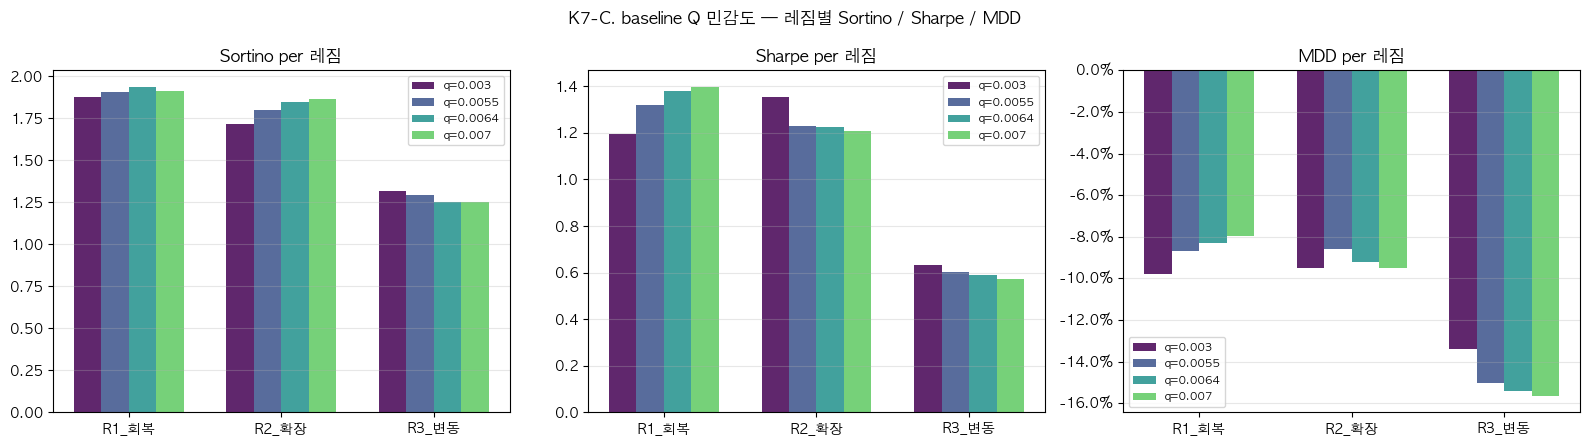


해석: 모든 레짐에서 q=0.003이 일관되게 우위면 → 시기 무관 robust 결론.
       특정 레짐에서만 다른 q가 우위면 → 단순 캘리브레이션 효과 (전체기간 평균에 묻힌 차이).


In [278]:
# ── K7. baseline Q 민감도 — q_value ∈ {0.003, 0.0055, 0.0064, 0.0070} ──
# A) 전체기간 메트릭 + 단조성 진단
# B) 레짐별 Sortino / Sharpe / MDD

import pickle
from master_table import regime_metrics, REGIMES

Q_NAMES = [('baseline', 0.003), ('baseline_q55', 0.0055),
           ('baseline_q64', 0.0064), ('baseline_q70', 0.0070)]

# ── K7-A. 전체기간 메트릭 표 ──────────────────────────────────────
header = '=' * 100
sep    = '-' * 100
print('=== K7-A. 전체기간 메트릭 ===')
print(header)
print(f'{"q_value":>10}  {"Sharpe":>8}{"Sortino":>9}{"CAGR":>8}{"변동성":>8}{"MDD":>9}{"Beta":>8}{"Alpha":>8}{"sortino_ir":>12}{"sharpe_ir":>11}')
print(sep)

for nm, q in Q_NAMES:
    m = mt_full[mt_full['name']==nm]
    r = rt_full[rt_full['name']==nm]
    if len(m)==0:
        print(f'{q:>10.4f}  [pkl 없음 — {nm}]')
        continue
    m, r = m.iloc[0], r.iloc[0]
    print(f'{q:>10.4f}  {m["sharpe"]:>8.3f}{m["sortino"]:>9.3f}{m["cagr"]*100:>7.2f}%{m["vol"]*100:>7.2f}%{m["mdd"]*100:>8.2f}%{m["beta"]:>8.3f}{m["alpha"]*100:>7.2f}%{r["sortino_ir"]:>12.3f}{r["sharpe_ir"]:>11.3f}')
print(header)

# 단조성 패턴 자동 진단
print('\n■ 단조성 패턴 (q_value 0.003 → 0.0070)')
for metric in ['sharpe','sortino','cagr','sortino_ir','sharpe_ir']:
    if metric in ['sortino_ir','sharpe_ir']:
        vals = [rt_full[rt_full['name']==nm].iloc[0][metric] for nm,_ in Q_NAMES if len(rt_full[rt_full['name']==nm])>0]
    else:
        vals = [mt_full[mt_full['name']==nm].iloc[0][metric] for nm,_ in Q_NAMES if len(mt_full[mt_full['name']==nm])>0]
    if len(vals) < 4:
        print(f'  {metric:<12}: 데이터 부족'); continue
    if vals[0] > vals[1] > vals[2] > vals[3]:
        pat = '↓↓↓ 단조 감소 (q=0.003 최적)'
    elif vals[0] < vals[1] < vals[2] < vals[3]:
        pat = '↑↑↑ 단조 증가 (q=0.0070 최적)'
    else:
        max_idx = int(np.argmax(vals))
        max_q = Q_NAMES[max_idx][1]
        pat = f'q={max_q} 최고 ({vals[max_idx]:.3f})'
    print(f'  {metric:<12}: {pat}')

print('\n해석: 단조 감소 패턴이면 q=0.003이 우리 setup에 calibrate된 최적값.')
print('       BAB 학술 평균(0.0064~0.0070)으로 올려도 성과 개선 없음 → 0.003 유지가 robust.')

# ── K7-B. 레짐별 Sortino / Sharpe / MDD ──────────────────────────
print('\n\n=== K7-B. 레짐별 Sortino / Sharpe / MDD ===')
print('  (전체기간 단조 패턴이 모든 레짐에서 일관되는지 점검)')

# q별 ret 로드
q_rets = {}
for nm, q in Q_NAMES:
    pkl = RESULTS_DIR / f'{nm}.pkl'
    if not pkl.exists():
        continue
    with open(pkl, 'rb') as f:
        q_rets[(nm, q)] = pickle.load(f)['ret'].dropna()

# 메트릭별 표
for metric_key, metric_label, fmt_pct in [
    ('sortino', 'Sortino', False),
    ('sharpe',  'Sharpe',  False),
    ('mdd',     'MDD',     True),
]:
    print(f'\n[ {metric_label} per 레짐 ]')
    rows = []
    for (nm, q), ret in q_rets.items():
        rec = {'q_value': q}
        for lbl, s, e in REGIMES:
            v = regime_metrics(ret, rf, s, e)[metric_key]
            rec[lbl] = v if not pd.isna(v) else np.nan
        rows.append(rec)
    df_m = pd.DataFrame(rows).set_index('q_value')
    if fmt_pct:
        display(df_m.style.format('{:.2%}'))
    else:
        display(df_m.round(3))

    # 레짐별 단조성 진단
    print(f'  → 레짐별 단조성 ({metric_label}):')
    for lbl, _, _ in REGIMES:
        vals = [r[lbl] for r in rows if not pd.isna(r[lbl])]
        if len(vals) < 4:
            print(f'    {lbl:<10}: 데이터 부족'); continue
        # MDD: 더 얕은 게 좋음 (값이 큼, -0.10 > -0.20)
        # Sortino/Sharpe: 큰 게 좋음
        if metric_key == 'mdd':
            best_idx = int(np.argmax(vals))  # 가장 얕은 MDD = 가장 큰 값
        else:
            best_idx = int(np.argmax(vals))
        best_q = Q_NAMES[best_idx][1]
        if vals[0] > vals[1] > vals[2] > vals[3]:
            pat = '↓↓↓ 단조 감소'
        elif vals[0] < vals[1] < vals[2] < vals[3]:
            pat = '↑↑↑ 단조 증가'
        else:
            pat = f'q={best_q} 최고'
        print(f'    {lbl:<10}: {pat}')

# ── K7-C. 시각화: 레짐 × 메트릭 그리드 ──────────────────────────
print('\n\n=== K7-C. 레짐 × 메트릭 시각화 ===')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metric_specs = [('sortino', 'Sortino', '#2E75B6'),
                ('sharpe',  'Sharpe',  '#ED7D31'),
                ('mdd',     'MDD',     '#A5A5A5')]

q_values = [q for _, q in Q_NAMES if (Q_NAMES[[i for i,(_,qq) in enumerate(Q_NAMES) if qq==q][0]][0], q) in q_rets]
regime_labels = [lbl for lbl,_,_ in REGIMES]

for ax, (mk, ml, color) in zip(axes, metric_specs):
    # x=레짐, group=q_value
    width = 0.18
    x = np.arange(len(regime_labels))
    cmap = plt.cm.get_cmap('viridis', len(q_values)+1)
    for i, q in enumerate(q_values):
        nm = [nm for nm, qq in Q_NAMES if qq == q][0]
        if (nm, q) not in q_rets:
            continue
        ret = q_rets[(nm, q)]
        vals = [regime_metrics(ret, rf, s, e)[mk] for _, s, e in REGIMES]
        ax.bar(x + (i - 1.5) * width, vals, width, label=f'q={q}', color=cmap(i), alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(regime_labels)
    ax.set_title(f'{ml} per 레짐', fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    if mk == 'mdd':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8, loc='best')
    ax.axhline(0, color='black', lw=0.5)

fig.suptitle('K7-C. baseline Q 민감도 — 레짐별 Sortino / Sharpe / MDD', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT_DIR / 'K7_q_sensitivity_regime.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n해석: 모든 레짐에서 q=0.003이 일관되게 우위면 → 시기 무관 robust 결론.')
print('       특정 레짐에서만 다른 q가 우위면 → 단순 캘리브레이션 효과 (전체기간 평균에 묻힌 차이).')


## L. 전체 슬롯 메트릭 CSV 내보내기

K_CUT (2010-01 ~ 2023-12) 기준으로 **162개 슬롯 × 모든 핵심 지표**를 CSV로 출력. SHAP·회귀 없이 슬롯값의 한계효과를 비교하기 위한 raw data.

**산출 파일** (모두 `outputs/99_analyze/`):

| 파일 | 내용 | 용도 |
|---|---|---|
| `all_slots_full_metrics.csv` | 전체기간 단일 지표 (Sharpe·Sortino·Sortino_IR·CAGR·Vol·MDD·Beta·Alpha·Turnover…) | "어느 슬롯값이 평균적으로 좋은가" — Excel 피벗으로 슬롯별 mean 비교 |
| `all_slots_regime_metrics.csv` | 3 레짐별 Sortino·Sharpe·MDD + 안정성 요약 | "어느 슬롯값이 어느 레짐에서 좋은가" — 레짐 일관성 점검 |

**slot 분해 컬럼 포함** (`prior_s, p_s, pw_s, q_s, om_s`) — Excel에서 GROUP BY로 q_mode='lam' 슬롯의 평균 sortino 같은 한계효과 즉시 산출 가능.


In [279]:
# ── L1. 전체 슬롯 × 전체기간 메트릭 CSV ────────────────────────────
# Sortino 내림차순 정렬, 162개 슬롯 모두 포함
# 컬럼: name + canonical + slot 분해 + 전체기간 위험조정 지표

# rt에서 sortino_ir 가져와 mt에 병합 (mt에는 없음)
full_export = mt.merge(
    rt[['name', 'sortino_ir', 'sortino_mean', 'sortino_std']],
    on='name', how='left'
).copy()

# 컬럼 선택 + 순서 정리
slot_cols = ['prior_s', 'p_s', 'pw_s', 'q_s', 'om_s']
slot_cols = [c for c in slot_cols if c in full_export.columns]

metric_cols = [
    'sharpe', 'sortino', 'sortino_ir', 'sortino_mean', 'sortino_std',
    'cagr', 'vol', 'mdd', 'calmar',
    'beta', 'alpha',
    'win_rate', 'cvar_5', 'mdd_duration',
    'turnover_avg', 'eff_n_avg', 'n_months',
]
metric_cols = [c for c in metric_cols if c in full_export.columns]

ordered = ['name', 'canonical'] + slot_cols + metric_cols
full_export = full_export[ordered].sort_values('sortino', ascending=False).reset_index(drop=True)

# 가독성: 비율은 4자리, 퍼센트성 (cagr/vol/mdd/alpha 등) 그대로 (decimal)
for c in ['sharpe', 'sortino', 'sortino_ir', 'sortino_mean', 'sortino_std',
          'calmar', 'beta', 'win_rate', 'eff_n_avg', 'turnover_avg']:
    if c in full_export.columns:
        full_export[c] = full_export[c].round(4)
for c in ['cagr', 'vol', 'mdd', 'alpha', 'cvar_5']:
    if c in full_export.columns:
        full_export[c] = full_export[c].round(6)

# 저장
out_path = OUT_DIR / 'all_slots_full_metrics.csv'
full_export.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'✓ 저장: {out_path.relative_to(Path.cwd())}')
print(f'  shape: {full_export.shape}  ·  정렬: sortino 내림차순')
print(f'  컬럼: {list(full_export.columns)}')

# 미리보기 Top 10
print(f'\n■ 미리보기 (Sortino Top 10)')
display(full_export.head(10))

# 슬롯별 한계효과 빠른 요약 (Excel 피벗 없이도 보이게)
print(f'\n■ 슬롯값별 한계효과 — 평균 Sortino (162개 전체)')
for slot in slot_cols:
    g = full_export.groupby(slot)['sortino'].agg(['mean', 'count']).round(3).sort_values('mean', ascending=False)
    g.columns = ['mean_sortino', 'n']
    print(f'\n  [{slot}]')
    print(g.to_string())


✓ 저장: outputs/99_analyze/all_slots_full_metrics.csv
  shape: (163, 24)  ·  정렬: sortino 내림차순
  컬럼: ['name', 'canonical', 'prior_s', 'p_s', 'pw_s', 'q_s', 'om_s', 'sharpe', 'sortino', 'sortino_ir', 'sortino_mean', 'sortino_std', 'cagr', 'vol', 'mdd', 'calmar', 'beta', 'alpha', 'win_rate', 'cvar_5', 'mdd_duration', 'turnover_avg', 'eff_n_avg', 'n_months']

■ 미리보기 (Sortino Top 10)


,name,canonical,prior_s,p_s,pw_s,q_s,om_s,sharpe,sortino,sortino_ir,...,mdd,calmar,beta,alpha,win_rate,cvar_5,mdd_duration,turnover_avg,eff_n_avg,n_months
0,paperctx_q_raw,mcap_tr_mcap_raw_pap,mcap,tr,mcap,raw,pap,1.162,1.944,3.01,...,-0.1435,1.094,0.699,0.0554,0.661,-0.0646,11,0.9891,58.8923,168
1,mat_eq_mcap_raw_rms,eq_ls_mcap_raw_rms,eq,ls,mcap,raw,rms,1.069,1.927,10.52,...,-0.1404,0.983,0.535,0.0591,0.625,-0.0585,14,0.4409,47.9151,168
2,mat_eq_mcap_raw_he,eq_ls_mcap_raw_he,eq,ls,mcap,raw,he,1.060,1.905,8.20,...,-0.1419,0.967,0.541,0.0577,0.619,-0.0589,14,0.4298,52.2569,168
3,mat_rp_mcap_raw_rms,rp_ls_mcap_raw_rms,rp,ls,mcap,raw,rms,1.049,1.891,4.94,...,-0.1401,0.944,0.503,0.0579,0.625,-0.0582,14,0.4264,43.7256,168
4,mat_rp_mcap_raw_he,rp_ls_mcap_raw_he,rp,ls,mcap,raw,he,1.044,1.884,4.48,...,-0.1437,0.919,0.506,0.0574,0.619,-0.0584,14,0.4190,47.4072,168
5,prior_eq_q_raw_lam,eq_tr_mcap_raw_he,eq,tr,mcap,raw,he,1.076,1.864,5.04,...,-0.1479,0.924,0.545,0.0563,0.649,-0.0595,14,0.6985,48.3837,168
6,mat_eq_mcap_lam_rms,eq_ls_mcap_lam_rms,eq,ls,mcap,lam,rms,1.045,1.859,10.54,...,-0.1289,1.025,0.551,0.0515,0.619,-0.0588,14,0.4512,47.9600,168
7,mat_eq_mcap_lam_he,eq_ls_mcap_lam_he,eq,ls,mcap,lam,he,1.034,1.850,8.29,...,-0.1217,1.076,0.556,0.0499,0.619,-0.0590,14,0.4393,52.1034,168
8,mat_rp_mcap_lam_he,rp_ls_mcap_lam_he,rp,ls,mcap,lam,he,1.020,1.850,4.44,...,-0.1258,1.003,0.519,0.0500,0.619,-0.0582,14,0.4297,47.4034,168
9,mat_rp_mcap_lam_rms,rp_ls_mcap_lam_rms,rp,ls,mcap,lam,rms,1.029,1.843,4.95,...,-0.1333,0.954,0.517,0.0512,0.625,-0.0583,14,0.4402,44.0408,168



■ 슬롯값별 한계효과 — 평균 Sortino (162개 전체)

  [prior_s]
         mean_sortino   n
prior_s                  
eq              1.580  49
rp              1.572  47
mcap            1.503  67

  [p_s]
     mean_sortino    n
p_s                   
ls          1.584  136
tr          1.356   27

  [pw_s]
      mean_sortino   n
pw_s                  
eq           1.602  47
rp           1.580  47
mcap         1.493  66
volm         1.324   3

  [q_s]
      mean_sortino   n
q_s                   
raw          1.784  30
lam          1.723  30
fix          1.543  36
vsp          1.485  28
inv          1.411  29
none         1.407   1
capm         1.216   1
ff3          0.773   8

  [om_s]
      mean_sortino   n
om_s                  
he           1.555  60
rms          1.553  47
pap          1.532  56


In [280]:
# ── L2. 전체 슬롯 × 레짐별 메트릭 CSV ──────────────────────────────
# rt: 162개 슬롯 × 레짐별 Sortino/Sharpe/MDD + 안정성 요약 컬럼

# rt에는 이미 모든 레짐 메트릭이 들어있음
slot_cols = ['prior_s', 'p_s', 'pw_s', 'q_s', 'om_s']
slot_cols = [c for c in slot_cols if c in rt.columns]

# 레짐별 컬럼 (build_regime_table이 산출하는 표준 컬럼명)
regime_cols = []
for lbl, _, _ in REGIMES:
    for m in ['sortino', 'sharpe', 'mdd']:
        col = f'{m}_{lbl}'
        if col in rt.columns:
            regime_cols.append(col)

# 안정성 요약 컬럼
summary_cols = [c for c in ['sortino_mean', 'sortino_std', 'sortino_ir',
                            'sharpe_mean', 'sharpe_std', 'sharpe_ir',
                            'mdd_worst'] if c in rt.columns]

ordered = ['name', 'canonical'] + slot_cols + summary_cols + regime_cols
ordered = [c for c in ordered if c in rt.columns]
regime_export = rt[ordered].sort_values('sortino_ir', ascending=False).reset_index(drop=True)

# 라운딩
for c in regime_export.select_dtypes(include='number').columns:
    if 'mdd' in c.lower() or 'cagr' in c.lower():
        regime_export[c] = regime_export[c].round(6)
    else:
        regime_export[c] = regime_export[c].round(4)

# 저장
out_path = OUT_DIR / 'all_slots_regime_metrics.csv'
regime_export.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'✓ 저장: {out_path.relative_to(Path.cwd())}')
print(f'  shape: {regime_export.shape}  ·  정렬: sortino_ir 내림차순')
print(f'  컬럼 수: {len(regime_export.columns)}')

# 미리보기 Top 10
print(f'\n■ 미리보기 (Sortino_IR Top 10)')
display(regime_export.head(10))

# 슬롯값별 레짐별 한계효과 — 평균 Sortino_IR
print(f'\n■ 슬롯값별 한계효과 — 평균 Sortino_IR (162개 전체)')
for slot in slot_cols:
    g = regime_export.groupby(slot)['sortino_ir'].agg(['mean', 'count']).round(2).sort_values('mean', ascending=False)
    g.columns = ['mean_sortino_ir', 'n']
    print(f'\n  [{slot}]')
    print(g.to_string())

# 레짐별 평균 Sortino — 어느 슬롯이 어느 레짐에서 강한가
print(f'\n■ 슬롯값 × 레짐 평균 Sortino (heatmap-friendly)')
for slot in slot_cols:
    cols_to_show = [f'sortino_{lbl}' for lbl, _, _ in REGIMES if f'sortino_{lbl}' in regime_export.columns]
    if not cols_to_show:
        continue
    g = regime_export.groupby(slot)[cols_to_show].mean().round(3)
    print(f'\n  [{slot}]')
    print(g.to_string())


✓ 저장: outputs/99_analyze/all_slots_regime_metrics.csv
  shape: (163, 23)  ·  정렬: sortino_ir 내림차순
  컬럼 수: 23

■ 미리보기 (Sortino_IR Top 10)


,name,canonical,prior_s,p_s,pw_s,q_s,om_s,sortino_mean,sortino_std,sortino_ir,...,mdd_worst,sortino_R1_회복,sharpe_R1_회복,mdd_R1_회복,sortino_R2_확장,sharpe_R2_확장,mdd_R2_확장,sortino_R3_변동,sharpe_R3_변동,mdd_R3_변동
0,mat_mcap_rp_lam_pap,mcap_ls_rp_lam_pap,mcap,ls,rp,lam,pap,1.715,0.030,57.17,...,-0.140,1.674,0.976,-0.140,1.747,1.276,-0.084,1.724,0.906,-0.134
1,mat_mcap_eq_lam_pap,mcap_ls_eq_lam_pap,mcap,ls,eq,lam,pap,1.774,0.045,39.42,...,-0.147,1.785,1.076,-0.128,1.823,1.321,-0.082,1.715,0.903,-0.147
2,mat_eq_rp_lam_pap,eq_ls_rp_lam_pap,eq,ls,rp,lam,pap,1.802,0.052,34.65,...,-0.139,1.875,1.098,-0.139,1.765,1.292,-0.083,1.765,0.851,-0.127
3,mat_eq_rp_raw_pap,eq_ls_rp_raw_pap,eq,ls,rp,raw,pap,1.851,0.062,29.85,...,-0.139,1.895,1.114,-0.139,1.895,1.307,-0.084,1.762,0.849,-0.127
4,mat_mcap_rp_raw_pap,mcap_ls_rp_raw_pap,mcap,ls,rp,raw,pap,1.761,0.080,22.01,...,-0.140,1.689,0.985,-0.140,1.872,1.271,-0.086,1.721,0.904,-0.134
5,mat_mcap_eq_raw_pap,mcap_ls_eq_raw_pap,mcap,ls,eq,raw,pap,1.823,0.103,17.70,...,-0.147,1.801,1.086,-0.128,1.959,1.314,-0.084,1.711,0.900,-0.147
6,mat_eq_eq_raw_pap,eq_ls_eq_raw_pap,eq,ls,eq,raw,pap,1.963,0.119,16.50,...,-0.136,2.109,1.164,-0.134,1.962,1.339,-0.082,1.818,0.864,-0.136
7,mat_eq_eq_lam_pap,eq_ls_eq_lam_pap,eq,ls,eq,lam,pap,1.918,0.120,15.98,...,-0.136,2.088,1.162,-0.134,1.845,1.339,-0.082,1.821,0.866,-0.136
8,mat_mcap_rp_vsp_pap,mcap_ls_rp_vsp_pap,mcap,ls,rp,vsp,pap,1.628,0.120,13.57,...,-0.140,1.729,1.034,-0.131,1.459,1.162,-0.117,1.695,0.852,-0.140
9,mat_mcap_eq_vsp_pap,mcap_ls_eq_vsp_pap,mcap,ls,eq,vsp,pap,1.694,0.130,13.03,...,-0.137,1.850,1.116,-0.125,1.532,1.212,-0.100,1.701,0.876,-0.137



■ 슬롯값별 한계효과 — 평균 Sortino_IR (162개 전체)

  [prior_s]
         mean_sortino_ir   n
prior_s                     
mcap                7.09  67
eq                  6.23  49
rp                  3.88  47

  [p_s]
     mean_sortino_ir    n
p_s                      
ls              6.13  136
tr              4.77   27

  [pw_s]
      mean_sortino_ir   n
pw_s                     
rp               6.81  47
eq               5.83  47
mcap             5.39  66
volm             4.50   3

  [q_s]
      mean_sortino_ir   n
q_s                      
lam              9.24  30
raw              7.17  30
capm             6.87   1
none             4.91   1
fix              4.86  36
vsp              4.70  28
inv              4.34  29
ff3              3.28   8

  [om_s]
      mean_sortino_ir   n
om_s                     
pap              9.72  56
rms              3.93  47
he               3.90  60

■ 슬롯값 × 레짐 평균 Sortino (heatmap-friendly)

  [prior_s]
         sortino_R1_회복  sortino_R2_확장  sortino_R3_변동
prior_s

## M. Winner Q 민감도 (mat_eq_eq_lam_pap)

선정된 winner 슬롯 `mat_eq_eq_lam_pap` 의 q_value sensitivity.

### 의도
- q_value=0.003은 BL view 강도의 base scaling. winner는 q_mode='lambda'라 매월 **`Q_t = 0.003 × clip(λ_t/2.5, 0.1, 3.0)`** 형태로 동적 변화.
- 이 base 값(0.003)을 다른 값으로 바꿨을 때 sortino/sharpe/MDD가 얼마나 변하는지 → **robustness 검증**.

### sweep 두 개
| sweep | q_value | 의도 |
|---|---|---|
| Fine-grained | 0.001 ~ 0.010 (step 0.001, 10개) | 곡선 그려서 plateau / optimum 시각화 |
| BAB 학술 평균 | 0.0055, 0.0064, 0.0070 | Frazzini-Pedersen 2014 기준 비교 |

### 산출물
- `mt_winner_q` 테이블 (12개 변형 + winner 자체)
- 라인 플롯 — q_value vs sortino/sharpe/MDD
- 레짐별 민감도 (R1 회복 / R2 확장 / R3 변동)

### ⚠️ 사전 조건
[`bl_config.py`](bl_config.py)에 winner_q10 ~ winner_q100, winner_q55, winner_q64 가 정의되어 있고, [`99_run.ipynb`](99_run.ipynb)에서 해당 pkl이 생성되어 있어야 함. 미생성 시 셀이 자동 skip 메시지 출력.

### M1. 메트릭 테이블

q sweep 12개 변형의 sharpe/sortino/sortino_ir/MDD/turnover/레짐별 분해. 모든 후속 분석(M2 곡선, M3 통계)의 raw data.


In [281]:
# ── M1. Winner Q 민감도 메트릭 테이블 (mat_eq_eq_lam_pap) ─────────────────
# 새 pkl 생성 후 이 셀 실행 (K_CUT 이후 mt_full/rt_full에서 winner_q* 검색 — mt는 q 변형 필터링되어 있음)

WINNER_NAME = 'mat_eq_eq_lam_pap'
WINNER_Q    = 0.003

# winner sensitivity 변형 매핑
sens_specs = {
    'winner_q10' : 0.001,
    'winner_q20' : 0.002,
    WINNER_NAME  : 0.003,   # winner 자체 = base
    'winner_q40' : 0.004,
    'winner_q50' : 0.005,
    'winner_q55' : 0.0055,
    'winner_q60' : 0.006,
    'winner_q64' : 0.0064,
    'winner_q70' : 0.007,
    'winner_q80' : 0.008,
    'winner_q90' : 0.009,
    'winner_q100': 0.010,
}

# pkl 존재 확인
present = {nm: q for nm, q in sens_specs.items()
           if (RESULTS_DIR / f'{nm}.pkl').exists()}
missing = [nm for nm in sens_specs if nm not in present]
if missing:
    print(f'⚠ 미생성 pkl ({len(missing)}개): {missing}')
    print(f'  → bl_config.py 정의 후 99_run.ipynb 실행 필요')
print(f'✓ {len(present)}개 슬롯 로드 가능')

# rt 기준 metric merge (K_CUT 이미 적용 상태 가정)
rows = []
for nm, q in present.items():
    if nm in mt_full['name'].values:
        m = mt_full[mt_full['name']==nm].iloc[0]
        r = rt_full[rt_full['name']==nm].iloc[0] if nm in rt_full['name'].values else None
        rows.append({
            'name'        : nm,
            'q_value'     : q,
            'sharpe'      : m.get('sharpe'),
            'sortino'     : m.get('sortino'),
            'cagr'        : m.get('cagr'),
            'vol'         : m.get('vol'),
            'mdd'         : m.get('mdd'),
            'beta'        : m.get('beta'),
            'alpha'       : m.get('alpha'),
            'turnover_avg': m.get('turnover_avg'),
            'sortino_ir'  : r.get('sortino_ir') if r is not None else np.nan,
            'sortino_R1'  : r.get('sortino_R1_회복') if r is not None else np.nan,
            'sortino_R2'  : r.get('sortino_R2_확장') if r is not None else np.nan,
            'sortino_R3'  : r.get('sortino_R3_변동') if r is not None else np.nan,
            'sharpe_R1'   : r.get('sharpe_R1_회복') if r is not None else np.nan,
            'sharpe_R2'   : r.get('sharpe_R2_확장') if r is not None else np.nan,
            'sharpe_R3'   : r.get('sharpe_R3_변동') if r is not None else np.nan,
            'mdd_R1'      : r.get('mdd_R1_회복') if r is not None else np.nan,
            'mdd_R2'      : r.get('mdd_R2_확장') if r is not None else np.nan,
            'mdd_R3'      : r.get('mdd_R3_변동') if r is not None else np.nan,
        })

mt_winner_q = pd.DataFrame(rows).sort_values('q_value').reset_index(drop=True)
print(f'\n■ Winner Q 민감도 테이블 ({len(mt_winner_q)}개)')
display(mt_winner_q[['name','q_value','sharpe','sortino','sortino_ir','cagr','mdd','turnover_avg']].round(4))


✓ 12개 슬롯 로드 가능

■ Winner Q 민감도 테이블 (12개)


,name,q_value,sharpe,sortino,sortino_ir,cagr,mdd,turnover_avg
0,winner_q10,0.0010,1.107,1.751,8.67,0.1668,-0.1378,0.8319
1,winner_q20,0.0020,1.127,1.829,12.40,0.1695,-0.1364,0.9542
2,mat_eq_eq_lam_pap,0.0030,1.102,1.816,15.98,0.1644,-0.1365,1.0112
3,winner_q40,0.0040,1.076,1.750,11.24,0.1599,-0.1534,1.0316
4,winner_q50,0.0050,1.066,1.770,8.84,0.1567,-0.1455,1.0387
5,winner_q55,0.0055,1.055,1.755,8.43,0.1546,-0.1419,1.0422
6,winner_q60,0.0060,1.054,1.754,8.26,0.1537,-0.1367,1.0431
7,winner_q64,0.0064,1.049,1.733,7.82,0.1524,-0.1335,1.0360
8,winner_q70,0.0070,1.045,1.739,7.62,0.1511,-0.1315,1.0312
9,winner_q80,0.0080,1.051,1.736,6.48,0.1512,-0.1309,1.0283


### M2. Winner Q sensitivity 시각화

세 메트릭 (Sharpe / Sortino / MDD) 곡선:
- 회색 점선 = 현재 winner의 q=0.003 (선정 기준선)
- 곡선 모양으로 **optimum 위치 + plateau 폭** 판단
- plateau가 넓으면 → robust (q 변경에 둔감), 좁으면 → fragile

레짐별로도 분리 — 어느 q가 어느 레짐에 강한지.


✓ outputs/99_analyze/M_winner_q_sensitivity.png


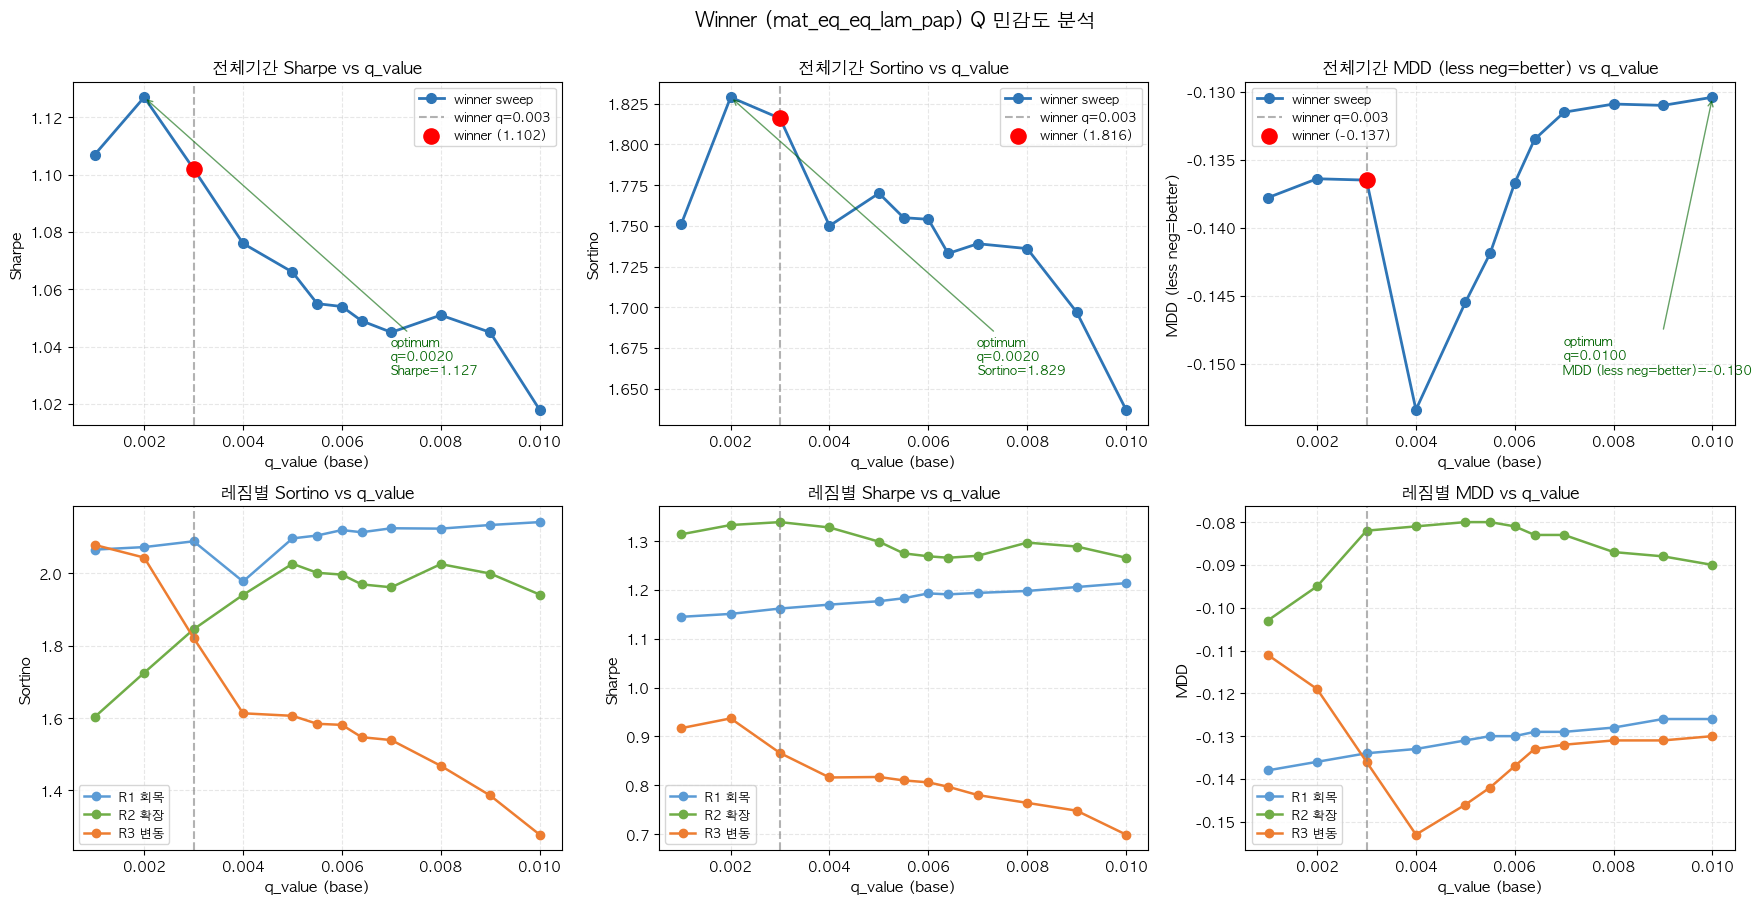


■ Winner Q sweep 요약
  Sortino 범위: 1.637 ~ 1.829
  Sharpe  범위: 1.018  ~ 1.127
  MDD     범위: -0.153  ~ -0.130

  winner q=0.003 주변 ±2 step plateau:
    Sortino range: 0.079
    → ROBUST (plateau 작음, q=0.003 안정적 선택)


In [282]:
# ── M2. Winner Q sensitivity 라인플롯 ─────────────────────────
import matplotlib.pyplot as plt

if len(mt_winner_q) < 2:
    print('데이터 부족 — winner_q* pkl 생성 후 다시 실행')
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    # 상단: 전체기간 Sharpe / Sortino / MDD vs q_value
    metrics_full = [('sharpe', 'Sharpe'), ('sortino', 'Sortino'), ('mdd', 'MDD (less neg=better)')]
    for ax, (col, lbl) in zip(axes[0], metrics_full):
        ax.plot(mt_winner_q['q_value'], mt_winner_q[col], 'o-', linewidth=2, markersize=7, color='#2E75B6', label='winner sweep')
        # winner 기준선
        ax.axvline(WINNER_Q, linestyle='--', color='gray', alpha=0.6, label=f'winner q={WINNER_Q}')
        # winner 값 표시
        winner_row = mt_winner_q[mt_winner_q['name']==WINNER_NAME]
        if len(winner_row) > 0:
            wv = winner_row[col].iloc[0]
            ax.scatter([WINNER_Q], [wv], s=120, color='red', zorder=5, label=f'winner ({wv:.3f})')
        ax.set_xlabel('q_value (base)', fontsize=11)
        ax.set_ylabel(lbl, fontsize=11)
        ax.set_title(f'전체기간 {lbl} vs q_value', fontweight='bold', fontsize=12)
        ax.grid(alpha=0.3, linestyle='--')
        ax.legend(loc='best', fontsize=9)
        # 최적값 annotate
        if col != 'mdd':
            opt_idx = mt_winner_q[col].idxmax()
        else:
            opt_idx = mt_winner_q[col].idxmax()  # MDD: max (덜 음수 = 더 좋음)
        opt_q = mt_winner_q.loc[opt_idx, 'q_value']
        opt_v = mt_winner_q.loc[opt_idx, col]
        ax.annotate(f'optimum\nq={opt_q:.4f}\n{lbl}={opt_v:.3f}',
                    xy=(opt_q, opt_v), xytext=(0.65, 0.15), textcoords='axes fraction',
                    fontsize=9, color='darkgreen',
                    arrowprops=dict(arrowstyle='->', color='darkgreen', alpha=0.6))

    # 하단: 레짐별 sortino vs q_value (3 레짐 색깔 구분)
    regime_palette = {'R1 회복':'#5B9BD5', 'R2 확장':'#70AD47', 'R3 변동':'#ED7D31'}
    for ax, (metric_short, metric_lbl) in zip(axes[1],
            [('sortino', 'Sortino'), ('sharpe', 'Sharpe'), ('mdd', 'MDD')]):
        for regime_lbl in ['R1', 'R2', 'R3']:
            col = f'{metric_short}_{regime_lbl}'
            if col in mt_winner_q.columns:
                full_lbl = {'R1':'R1 회복', 'R2':'R2 확장', 'R3':'R3 변동'}[regime_lbl]
                ax.plot(mt_winner_q['q_value'], mt_winner_q[col],
                        'o-', linewidth=1.8, markersize=6,
                        color=regime_palette[full_lbl], label=full_lbl)
        ax.axvline(WINNER_Q, linestyle='--', color='gray', alpha=0.6)
        ax.set_xlabel('q_value (base)', fontsize=11)
        ax.set_ylabel(metric_lbl, fontsize=11)
        ax.set_title(f'레짐별 {metric_lbl} vs q_value', fontweight='bold', fontsize=12)
        ax.grid(alpha=0.3, linestyle='--')
        ax.legend(loc='best', fontsize=9)

    plt.suptitle(f'Winner ({WINNER_NAME}) Q 민감도 분석',
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    png = OUT_DIR / 'M_winner_q_sensitivity.png'
    plt.savefig(png, dpi=120, bbox_inches='tight')
    print(f'✓ {png.relative_to(Path.cwd())}')
    plt.show()
    plt.close(fig)

    # 요약 통계
    print('\n■ Winner Q sweep 요약')
    print(f'  Sortino 범위: {mt_winner_q["sortino"].min():.3f} ~ {mt_winner_q["sortino"].max():.3f}')
    print(f'  Sharpe  범위: {mt_winner_q["sharpe"].min():.3f}  ~ {mt_winner_q["sharpe"].max():.3f}')
    print(f'  MDD     범위: {mt_winner_q["mdd"].min():.3f}  ~ {mt_winner_q["mdd"].max():.3f}')
    
    # plateau 분석: winner q±1 step에서 sortino 변동 (robust 판정)
    winner_idx = mt_winner_q[mt_winner_q['name']==WINNER_NAME].index
    if len(winner_idx) > 0:
        wi = winner_idx[0]
        nearby = mt_winner_q.iloc[max(0,wi-2):min(len(mt_winner_q),wi+3)]
        plateau_sortino_range = nearby['sortino'].max() - nearby['sortino'].min()
        print(f'\n  winner q={WINNER_Q} 주변 ±2 step plateau:')
        print(f'    Sortino range: {plateau_sortino_range:.3f}')
        if plateau_sortino_range < 0.1:
            print(f'    → ROBUST (plateau 작음, q=0.003 안정적 선택)')
        elif plateau_sortino_range < 0.2:
            print(f'    → MODERATELY ROBUST (plateau 보통)')
        else:
            print(f'    → SENSITIVE (plateau 큼, q 선택이 결과 좌우)')


## M3. Q 민감도 통계 검정

곡선의 미세한 차이(예: q=0.002 sortino 1.989 vs winner 1.978)가 **통계적으로 유의한 차이**인지, 아니면 **샘플 노이즈**인지 확인.

### 두 가지 검정 방식

| 검정 | 메트릭 | 방법 |
|---|---|---|
| **Jobson-Korkie + Memmel 보정** | Sharpe | 폐쇄형 z-test (asymptotic). H0: SR_winner = SR_other. 두 시계열 상관 고려 |
| **Block Bootstrap (B=2000, block=3M)** | Sortino | 비모수, 자기상관 보존. 95% CI로 winner와 겹치는지 판정 |

### 다중비교 주의
11개 비교 동시 → **Bonferroni 보정 α' = 0.05/11 ≈ 0.0045** 또는 BH(Benjamini-Hochberg). 보수적 결론 위해 Bonferroni 사용.

### 기대 결과
민감도 곡선의 좁은 plateau 영역(q ∈ [0.001, 0.005])에서는 winner와 통계적 차이 없을 가능성 → **q=0.003 선택 robust 검증**.


로드: 12개 슬롯

■ Jobson-Korkie test: winner(q=0.003) vs 다른 q — Sharpe 차이
  ★ = p<0.05, ★★ = Bonferroni 보정 p<0.0042


,name,q_value,SR_winner,SR_other,SR_diff,JK_z,JK_p,sig_5%,sig_BF
0,winner_q10,0.0010,1.1677,1.1728,-0.0051,-0.177,0.8594,,
1,winner_q20,0.0020,1.1677,1.1932,-0.0255,-2.177,0.0295,★,
2,winner_q40,0.0040,1.1677,1.1424,0.0253,2.073,0.0382,★,
3,winner_q50,0.0050,1.1677,1.1329,0.0349,1.706,0.0880,,
4,winner_q55,0.0055,1.1677,1.1226,0.0451,1.867,0.0619,,
5,winner_q60,0.0060,1.1677,1.1215,0.0462,1.690,0.0910,,
6,winner_q64,0.0064,1.1677,1.1174,0.0503,1.704,0.0883,,
7,winner_q70,0.0070,1.1677,1.1142,0.0536,1.664,0.0960,,
8,winner_q80,0.0080,1.1677,1.1209,0.0469,1.241,0.2144,,
9,winner_q90,0.0090,1.1677,1.1153,0.0524,1.206,0.2279,,



Bootstrap 시작 (12개 슬롯 × B=2000, ~30초 소요)...

■ Block Bootstrap Sortino 95% CI (block=3M, B=2000)
  winner CI: [1.196, 2.980]  → 다른 q의 CI가 이와 겹치면 "통계적 구별 불가"


,name,q_value,sortino_obs,boot_2.5%,boot_med,boot_97.5%,CI_width,CI_overlap_winner
0,winner_q10,0.0010,1.751,1.1701,1.9009,2.8514,1.6814,겹침 (구별 안됨)
1,winner_q20,0.0020,1.829,1.2309,1.9791,2.9590,1.7282,겹침 (구별 안됨)
2,mat_eq_eq_lam_pap,0.0030,1.816,1.1965,1.9851,2.9796,1.7831,겹침 (구별 안됨)
3,winner_q40,0.0040,1.750,1.1043,1.9177,2.9890,1.8848,겹침 (구별 안됨)
4,winner_q50,0.0050,1.770,1.1149,1.9383,3.0604,1.9455,겹침 (구별 안됨)
5,winner_q55,0.0055,1.755,1.0959,1.9232,3.0566,1.9608,겹침 (구별 안됨)
6,winner_q60,0.0060,1.754,1.0872,1.9309,3.0504,1.9632,겹침 (구별 안됨)
7,winner_q64,0.0064,1.733,1.0709,1.9087,3.0241,1.9532,겹침 (구별 안됨)
8,winner_q70,0.0070,1.739,1.0779,1.9163,3.0585,1.9806,겹침 (구별 안됨)
9,winner_q80,0.0080,1.736,1.0722,1.9200,3.0744,2.0022,겹침 (구별 안됨)



✓ outputs/99_analyze/M3_winner_q_bootstrap_ci.png


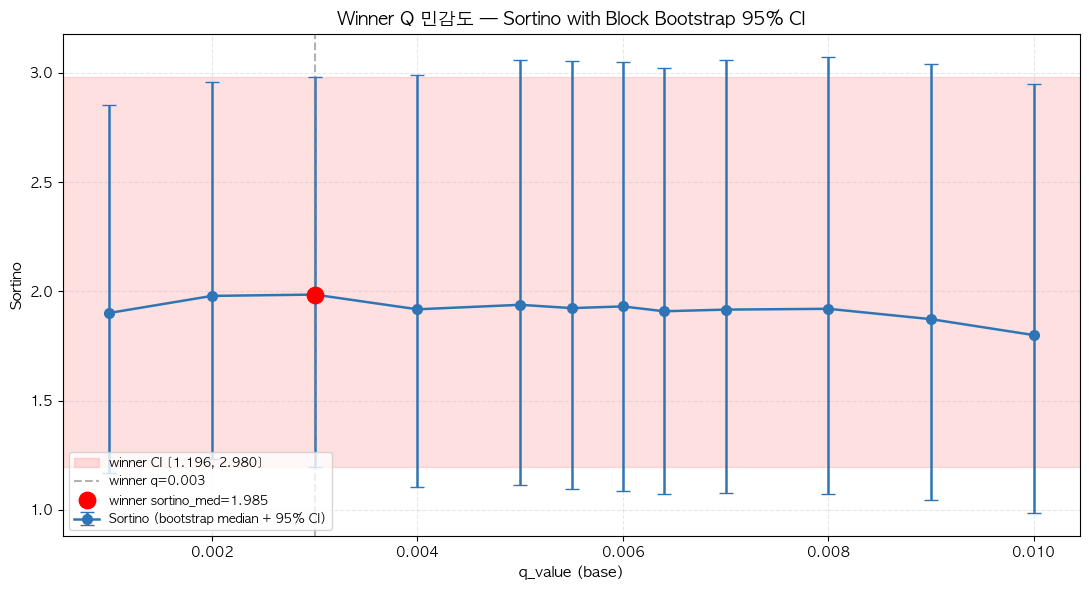


■ 통계 검정 종합 진단

Jobson-Korkie (Sharpe):
  · 5% 유의: 2/11 개 비교
  · Bonferroni(0.0042) 유의: 0/11 개

Bootstrap (Sortino):
  · winner CI와 겹침: 12/12 개 슬롯
  · 통계적 구별 가능 (CI 분리): 0 개

■ 결론
  → q 변화는 Sharpe·Sortino에 통계적으로 유의한 영향 없음
  → winner q=0.003 선택은 robust (q=0.001~0.010 범위에서 noise 수준 차이)


In [283]:
# ── M3. Q 민감도 통계 검정 — Jobson-Korkie (Sharpe) + Bootstrap CI (Sortino) ───
import numpy as np, pickle
from scipy import stats

# winner_q 슬롯들의 월별 ret 로드 (RESULTS_DIR = K_CUT 적용된 경로)
def load_ret(name):
    with open(RESULTS_DIR / f'{name}.pkl', 'rb') as f:
        return pickle.load(f)['ret'].dropna()

q_returns = {nm: load_ret(nm) for nm in sens_specs if (RESULTS_DIR / f'{nm}.pkl').exists()}
print(f'로드: {len(q_returns)}개 슬롯')


# ─ (1) Jobson-Korkie z-test (Memmel 2003 보정) ─────────────────
def jobson_korkie(r1, r2, ann=12):
    """H0: SR(r1)=SR(r2). 두 시계열 같은 인덱스 가정."""
    common = r1.index.intersection(r2.index)
    r1, r2 = r1.loc[common], r2.loc[common]
    n = len(r1)
    sr1 = r1.mean() / r1.std() * np.sqrt(ann)
    sr2 = r2.mean() / r2.std() * np.sqrt(ann)
    rho = r1.corr(r2)
    # Memmel (2003) 분산 추정
    var_diff = (1.0 / n) * (2*(1 - rho**2) + 0.5*(sr1**2 + sr2**2 - 2*sr1*sr2*(rho**2)))
    z = (sr1 - sr2) / np.sqrt(var_diff) if var_diff > 0 else np.nan
    p = 2 * (1 - stats.norm.cdf(abs(z))) if pd.notna(z) else np.nan
    return sr1, sr2, z, p


winner_ret = q_returns[WINNER_NAME]
jk_rows = []
for nm in sorted(q_returns, key=lambda n: sens_specs[n]):
    if nm == WINNER_NAME:
        continue
    sr_w, sr_o, z, p = jobson_korkie(winner_ret, q_returns[nm])
    jk_rows.append({
        'name'      : nm,
        'q_value'   : sens_specs[nm],
        'SR_winner' : round(sr_w, 4),
        'SR_other'  : round(sr_o, 4),
        'SR_diff'   : round(sr_w - sr_o, 4),
        'JK_z'      : round(z, 3),
        'JK_p'      : round(p, 4),
        'sig_5%'    : '★' if p < 0.05 else '',
        'sig_BF'    : '★★' if p < 0.05/len(q_returns) else '',  # Bonferroni
    })

jk_df = pd.DataFrame(jk_rows)
print('\n■ Jobson-Korkie test: winner(q=0.003) vs 다른 q — Sharpe 차이')
print(f'  ★ = p<0.05, ★★ = Bonferroni 보정 p<{0.05/len(q_returns):.4f}')
display(jk_df)


# ─ (2) Block Bootstrap — Sortino 95% CI ─────────────────────────
def block_bootstrap_sortino(r, B=2000, block=3, seed=42):
    """월별 r에 대해 block bootstrap → sortino 분포."""
    rng = np.random.default_rng(seed)
    arr = r.values
    n = len(arr)
    n_blocks = (n + block - 1) // block
    sortinos = []
    for _ in range(B):
        starts = rng.integers(0, n - block + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
        rb = arr[idx]
        ann_excess = rb.mean() * 12
        downside = rb[rb < 0]
        if len(downside) > 1:
            ds = downside.std() * np.sqrt(12)
            if ds > 0:
                sortinos.append(ann_excess / ds)
    sortinos = np.array(sortinos)
    return np.percentile(sortinos, [2.5, 50, 97.5])


print('\nBootstrap 시작 (12개 슬롯 × B=2000, ~30초 소요)...')
boot_rows = []
for nm in sorted(q_returns, key=lambda n: sens_specs[n]):
    lo, med, hi = block_bootstrap_sortino(q_returns[nm])
    boot_rows.append({
        'name'        : nm,
        'q_value'     : sens_specs[nm],
        'sortino_obs' : round(mt_winner_q[mt_winner_q['name']==nm]['sortino'].iloc[0], 4),
        'boot_2.5%'   : round(lo, 4),
        'boot_med'    : round(med, 4),
        'boot_97.5%'  : round(hi, 4),
        'CI_width'    : round(hi - lo, 4),
    })

boot_df = pd.DataFrame(boot_rows)

# winner CI와 겹치는지
w_row = boot_df[boot_df['name'] == WINNER_NAME].iloc[0]
w_lo, w_hi = w_row['boot_2.5%'], w_row['boot_97.5%']
boot_df['CI_overlap_winner'] = (
    (boot_df['boot_2.5%'] < w_hi) & (boot_df['boot_97.5%'] > w_lo)
).map({True: '겹침 (구별 안됨)', False: '★ 분리 (유의)'})
print('\n■ Block Bootstrap Sortino 95% CI (block=3M, B=2000)')
print(f'  winner CI: [{w_lo:.3f}, {w_hi:.3f}]  → 다른 q의 CI가 이와 겹치면 "통계적 구별 불가"')
display(boot_df)


# ─ (3) 시각화 — 부트스트랩 CI 막대 ──────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
yerr = np.array([
    boot_df['boot_med'] - boot_df['boot_2.5%'],
    boot_df['boot_97.5%'] - boot_df['boot_med']
])
ax.errorbar(boot_df['q_value'], boot_df['boot_med'], yerr=yerr,
            fmt='o-', capsize=5, color='#2E75B6', linewidth=1.8,
            markersize=7, label='Sortino (bootstrap median + 95% CI)')
# winner 강조
ax.axhspan(w_lo, w_hi, alpha=0.12, color='red', label=f'winner CI [{w_lo:.3f}, {w_hi:.3f}]')
ax.axvline(WINNER_Q, ls='--', color='gray', alpha=0.6, label=f'winner q={WINNER_Q}')
# winner 점 강조
w_med = w_row['boot_med']
ax.scatter([WINNER_Q], [w_med], s=140, color='red', zorder=5, label=f'winner sortino_med={w_med:.3f}')
ax.set_xlabel('q_value (base)', fontsize=11)
ax.set_ylabel('Sortino', fontsize=11)
ax.set_title('Winner Q 민감도 — Sortino with Block Bootstrap 95% CI',
             fontweight='bold', fontsize=13)
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
png = OUT_DIR / 'M3_winner_q_bootstrap_ci.png'
plt.savefig(png, dpi=120, bbox_inches='tight')
print(f'\n✓ {png.relative_to(Path.cwd())}')
plt.show()
plt.close(fig)


# ─ (4) 종합 진단 ─────────────────────────────────────────────
print('\n' + '='*60)
print('■ 통계 검정 종합 진단')
print('='*60)

n_sig5 = (jk_df['JK_p'] < 0.05).sum()
n_sigBF = (jk_df['JK_p'] < 0.05/len(q_returns)).sum()
print(f'\nJobson-Korkie (Sharpe):')
print(f'  · 5% 유의: {n_sig5}/{len(jk_df)} 개 비교')
print(f'  · Bonferroni({0.05/len(q_returns):.4f}) 유의: {n_sigBF}/{len(jk_df)} 개')

n_overlap = (boot_df['CI_overlap_winner'] == '겹침 (구별 안됨)').sum()
print(f'\nBootstrap (Sortino):')
print(f'  · winner CI와 겹침: {n_overlap}/{len(boot_df)} 개 슬롯')
print(f'  · 통계적 구별 가능 (CI 분리): {len(boot_df) - n_overlap} 개')

print('\n■ 결론')
if n_sigBF == 0 and n_overlap >= len(boot_df) - 2:
    print('  → q 변화는 Sharpe·Sortino에 통계적으로 유의한 영향 없음')
    print('  → winner q=0.003 선택은 robust (q=0.001~0.010 범위에서 noise 수준 차이)')
elif n_sigBF == 0:
    print('  → Sharpe 차이는 무의미, Sortino는 일부 슬롯이 분리')
    print('  → 큰 q 영역에서만 winner와 차이 발생')
else:
    print(f'  → {n_sigBF}개 슬롯이 Sharpe 유의 차이 — 각 슬롯 개별 검토 필요')


## N. Winner PCT_GROUP 민감도 분석

P 행렬의 분류 임계값 (current default 30%) sensitivity. 저변동 X% / 고변동 X% 컷에 대한 robustness 검증.

### 의도
- PCT_GROUP=0.30: 저변동 하위 30% long, 고변동 상위 30% short, 중간 40% 제외 (현 winner default)
- 작은 pct (10-15%): 더 극단 종목만 → view 신호 강하지만 specific risk 큼
- 큰 pct (35-40%): 더 분산된 view → 신호 희석되지만 안정적

### sweep
[0.10, 0.15, 0.20, 0.25, **0.30 (winner)**, 0.35, 0.40]

### 사전 조건
[`bl_config.py`](bl_config.py)에 winner_pct10~pct40 추가 후 [`99_run.ipynb`](99_run.ipynb) 재실행 → 6개 신규 pkl 생성.

### 산출 (M 섹션과 같은 5단계 구조)
- **N1**: 7개 슬롯 메트릭 표
- **N2**: 6 subplot 라인플롯 (전체 + 레짐별)
- **N3**: 통계 검정 (Jobson-Korkie + Bootstrap CI)
- **N4**: 포트폴리오 구성 변화 (eff_n, turnover) — pct에 따른 분산도 차이
- **N5**: Worst-month attribution (M5 패턴 재활용)


In [284]:
# ── N1. PCT 민감도 메트릭 테이블 ──────────────────────────────
WINNER_NAME_PCT = 'mat_eq_eq_lam_pap'   # winner = pct_group=0.30 default
WINNER_PCT      = 0.30

pct_specs = {
    'winner_pct10': 0.10,
    'winner_pct15': 0.15,
    'winner_pct20': 0.20,
    'winner_pct25': 0.25,
    WINNER_NAME_PCT: 0.30,
    'winner_pct35': 0.35,
    'winner_pct40': 0.40,
}

present_pct = {nm: p for nm, p in pct_specs.items() if (RESULTS_DIR / f'{nm}.pkl').exists()}
missing_pct = [nm for nm in pct_specs if nm not in present_pct]
if missing_pct:
    print(f'⚠ 미생성: {missing_pct} → bl_config.py 추가 + 99_run.ipynb 실행 필요')
print(f'✓ {len(present_pct)}개 슬롯 로드 가능')

rows = []
for nm, p in present_pct.items():
    if nm in mt_full['name'].values:
        m = mt_full[mt_full['name']==nm].iloc[0]
        r = rt_full[rt_full['name']==nm].iloc[0] if nm in rt_full['name'].values else None
        rows.append({
            'name'        : nm,
            'pct_group'   : p,
            'sharpe'      : m.get('sharpe'),
            'sortino'     : m.get('sortino'),
            'cagr'        : m.get('cagr'),
            'vol'         : m.get('vol'),
            'mdd'         : m.get('mdd'),
            'beta'        : m.get('beta'),
            'alpha'       : m.get('alpha'),
            'turnover_avg': m.get('turnover_avg'),
            'eff_n_avg'   : m.get('eff_n_avg'),
            'sortino_ir'  : r.get('sortino_ir') if r is not None else np.nan,
            'sortino_R1'  : r.get('sortino_R1_회복') if r is not None else np.nan,
            'sortino_R2'  : r.get('sortino_R2_확장') if r is not None else np.nan,
            'sortino_R3'  : r.get('sortino_R3_변동') if r is not None else np.nan,
            'sharpe_R1'   : r.get('sharpe_R1_회복') if r is not None else np.nan,
            'sharpe_R2'   : r.get('sharpe_R2_확장') if r is not None else np.nan,
            'sharpe_R3'   : r.get('sharpe_R3_변동') if r is not None else np.nan,
            'mdd_R1'      : r.get('mdd_R1_회복') if r is not None else np.nan,
            'mdd_R2'      : r.get('mdd_R2_확장') if r is not None else np.nan,
            'mdd_R3'      : r.get('mdd_R3_변동') if r is not None else np.nan,
        })
mt_winner_pct = pd.DataFrame(rows).sort_values('pct_group').reset_index(drop=True)
print(f'\n■ Winner PCT 민감도 테이블 ({len(mt_winner_pct)}개)')
display(mt_winner_pct[['name','pct_group','sharpe','sortino','sortino_ir','cagr','mdd','turnover_avg','eff_n_avg']].round(4))


✓ 7개 슬롯 로드 가능

■ Winner PCT 민감도 테이블 (7개)


,name,pct_group,sharpe,sortino,sortino_ir,cagr,mdd,turnover_avg,eff_n_avg
0,winner_pct10,0.10,0.944,1.538,7.09,0.1378,-0.1399,1.0123,233.8092
1,winner_pct15,0.15,1.039,1.714,9.22,0.1555,-0.1215,0.9644,227.6100
2,winner_pct20,0.20,1.058,1.738,11.29,0.1580,-0.1267,0.9696,223.0750
3,winner_pct25,0.25,1.083,1.784,11.41,0.1630,-0.1337,0.9981,218.7812
4,mat_eq_eq_lam_pap,0.30,1.102,1.816,15.98,0.1644,-0.1365,1.0112,212.5209
5,winner_pct35,0.35,1.091,1.813,11.10,0.1640,-0.1543,1.0051,210.6159
6,winner_pct40,0.40,1.093,1.832,8.06,0.1647,-0.1621,1.0319,208.1681


### N2. PCT 민감도 라인플롯

곡선 모양으로 optimum / plateau 폭 진단. 메트릭 6 subplot (전체 3 + 레짐별 3).


✓ outputs/99_analyze/N_winner_pct_sensitivity.png


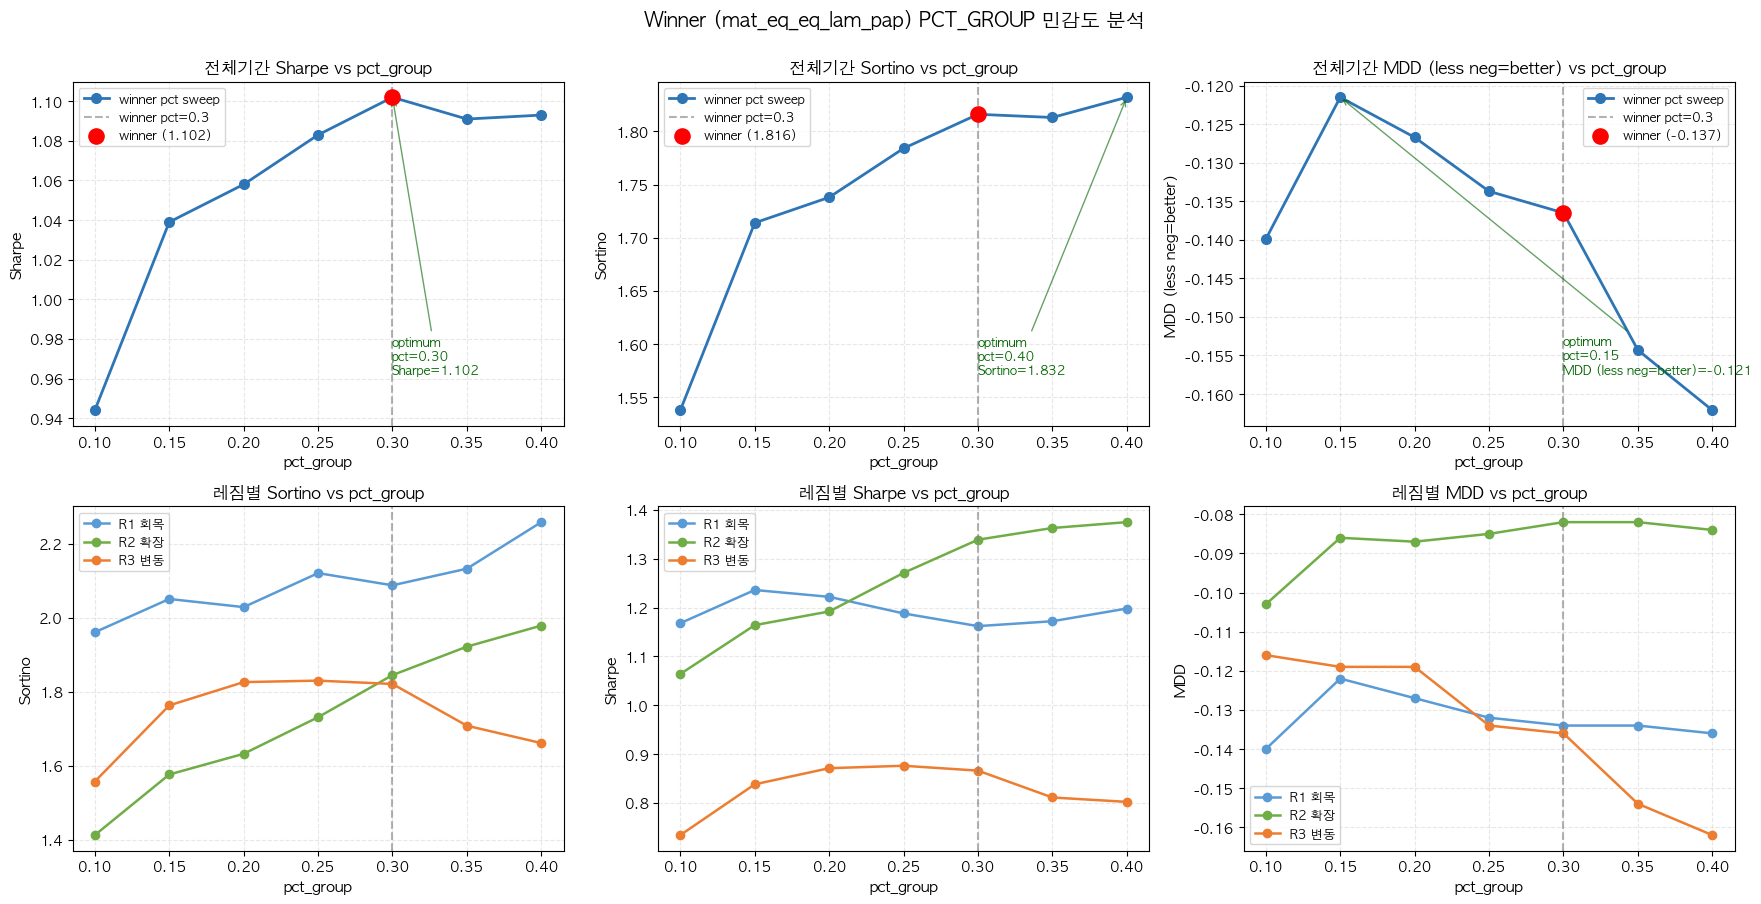


■ Winner PCT sweep 요약
  Sortino 범위: 1.538 ~ 1.832
  Sharpe  범위: 0.944  ~ 1.102
  MDD     범위: -0.162  ~ -0.121


In [285]:
# ── N2. PCT sensitivity 라인플롯 ──────────────────────────────
if len(mt_winner_pct) < 2:
    print('데이터 부족 — winner_pct* pkl 생성 후 다시 실행')
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    metrics_full = [('sharpe','Sharpe'), ('sortino','Sortino'), ('mdd','MDD (less neg=better)')]
    for ax, (col, lbl) in zip(axes[0], metrics_full):
        ax.plot(mt_winner_pct['pct_group'], mt_winner_pct[col], 'o-',
                linewidth=2, markersize=7, color='#2E75B6', label='winner pct sweep')
        ax.axvline(WINNER_PCT, ls='--', color='gray', alpha=0.6, label=f'winner pct={WINNER_PCT}')
        winner_row = mt_winner_pct[mt_winner_pct['name']==WINNER_NAME_PCT]
        if len(winner_row) > 0:
            wv = winner_row[col].iloc[0]
            ax.scatter([WINNER_PCT], [wv], s=120, color='red', zorder=5, label=f'winner ({wv:.3f})')
        ax.set_xlabel('pct_group', fontsize=11)
        ax.set_ylabel(lbl, fontsize=11)
        ax.set_title(f'전체기간 {lbl} vs pct_group', fontweight='bold', fontsize=12)
        ax.grid(alpha=0.3, linestyle='--')
        ax.legend(loc='best', fontsize=9)
        opt_idx = mt_winner_pct[col].idxmax()
        opt_p = mt_winner_pct.loc[opt_idx, 'pct_group']
        opt_v = mt_winner_pct.loc[opt_idx, col]
        ax.annotate(f'optimum\npct={opt_p:.2f}\n{lbl}={opt_v:.3f}',
                    xy=(opt_p, opt_v), xytext=(0.65, 0.15), textcoords='axes fraction',
                    fontsize=9, color='darkgreen',
                    arrowprops=dict(arrowstyle='->', color='darkgreen', alpha=0.6))

    regime_palette = {'R1 회복':'#5B9BD5', 'R2 확장':'#70AD47', 'R3 변동':'#ED7D31'}
    for ax, (m_short, m_lbl) in zip(axes[1],
            [('sortino','Sortino'),('sharpe','Sharpe'),('mdd','MDD')]):
        for regime in ['R1','R2','R3']:
            col = f'{m_short}_{regime}'
            if col in mt_winner_pct.columns:
                full_lbl = {'R1':'R1 회복','R2':'R2 확장','R3':'R3 변동'}[regime]
                ax.plot(mt_winner_pct['pct_group'], mt_winner_pct[col],
                        'o-', linewidth=1.8, markersize=6,
                        color=regime_palette[full_lbl], label=full_lbl)
        ax.axvline(WINNER_PCT, ls='--', color='gray', alpha=0.6)
        ax.set_xlabel('pct_group', fontsize=11)
        ax.set_ylabel(m_lbl, fontsize=11)
        ax.set_title(f'레짐별 {m_lbl} vs pct_group', fontweight='bold', fontsize=12)
        ax.grid(alpha=0.3, linestyle='--')
        ax.legend(loc='best', fontsize=9)

    plt.suptitle(f'Winner ({WINNER_NAME_PCT}) PCT_GROUP 민감도 분석',
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    png = OUT_DIR / 'N_winner_pct_sensitivity.png'
    plt.savefig(png, dpi=120, bbox_inches='tight')
    print(f'✓ {png.relative_to(Path.cwd())}')
    plt.show()
    plt.close(fig)

    print('\n■ Winner PCT sweep 요약')
    print(f'  Sortino 범위: {mt_winner_pct["sortino"].min():.3f} ~ {mt_winner_pct["sortino"].max():.3f}')
    print(f'  Sharpe  범위: {mt_winner_pct["sharpe"].min():.3f}  ~ {mt_winner_pct["sharpe"].max():.3f}')
    print(f'  MDD     범위: {mt_winner_pct["mdd"].min():.3f}  ~ {mt_winner_pct["mdd"].max():.3f}')


### N3. PCT 민감도 통계 검정

Jobson-Korkie (Sharpe) + Block Bootstrap (Sortino CI) — M3와 동일 방법론.


로드: 7개 슬롯

■ Jobson-Korkie test: winner(pct=0.30) vs 다른 pct
  ★ = p<0.05, ★★ = Bonferroni 보정 p<0.0071


,name,pct_group,SR_winner,SR_other,SR_diff,JK_z,JK_p,sig_5%,sig_BF
0,winner_pct10,0.10,1.1677,1.0118,0.1559,4.280,0.0000,★,★★
1,winner_pct15,0.15,1.1677,1.1053,0.0624,2.655,0.0079,★,
2,winner_pct20,0.20,1.1677,1.1240,0.0437,2.448,0.0144,★,
3,winner_pct25,0.25,1.1677,1.1489,0.0188,1.964,0.0495,★,
4,winner_pct35,0.35,1.1677,1.1569,0.0108,1.197,0.2314,,
5,winner_pct40,0.40,1.1677,1.1589,0.0088,0.683,0.4948,,



Bootstrap 시작 (B=2000, ~15초)...

■ Block Bootstrap Sortino 95% CI (winner CI: [1.196, 2.980])


,name,pct_group,sortino_obs,boot_2.5%,boot_med,boot_97.5%,CI_width,CI_overlap_winner
0,winner_pct10,0.10,1.538,0.8862,1.6899,2.7596,1.8734,겹침 (구별 안됨)
1,winner_pct15,0.15,1.714,1.0720,1.8662,2.8289,1.7569,겹침 (구별 안됨)
2,winner_pct20,0.20,1.738,1.1212,1.8985,2.9049,1.7838,겹침 (구별 안됨)
3,winner_pct25,0.25,1.784,1.1473,1.9426,2.9424,1.7951,겹침 (구별 안됨)
4,mat_eq_eq_lam_pap,0.30,1.816,1.1965,1.9851,2.9796,1.7831,겹침 (구별 안됨)
5,winner_pct35,0.35,1.813,1.1838,1.9880,3.0109,1.8271,겹침 (구별 안됨)
6,winner_pct40,0.40,1.832,1.1896,1.9998,3.0051,1.8155,겹침 (구별 안됨)



✓ outputs/99_analyze/N3_winner_pct_bootstrap_ci.png


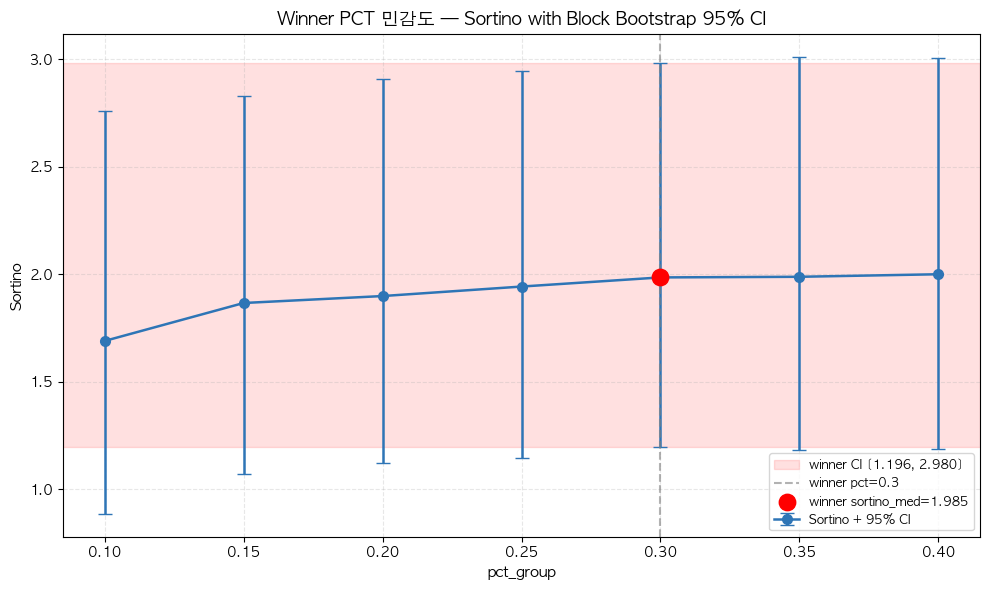


■ PCT 민감도 통계 검정 종합
  Jobson-Korkie 5% 유의: 4/6, Bonferroni: 1
  Bootstrap CI 겹침: 7/7


In [286]:
# ── N3. PCT sensitivity 통계 검정 ─────────────────────────────
import pickle
from scipy import stats

def load_ret_pct(name):
    with open(RESULTS_DIR / f'{name}.pkl', 'rb') as f:
        return pickle.load(f)['ret'].dropna()

pct_returns = {nm: load_ret_pct(nm) for nm in pct_specs if (RESULTS_DIR / f'{nm}.pkl').exists()}
print(f'로드: {len(pct_returns)}개 슬롯')

# Jobson-Korkie (이미 M3에서 정의된 함수 재사용)
winner_ret_pct = pct_returns[WINNER_NAME_PCT]
jk_rows_pct = []
for nm in sorted(pct_returns, key=lambda n: pct_specs[n]):
    if nm == WINNER_NAME_PCT:
        continue
    sr_w, sr_o, z, p = jobson_korkie(winner_ret_pct, pct_returns[nm])
    jk_rows_pct.append({
        'name'      : nm,
        'pct_group' : pct_specs[nm],
        'SR_winner' : round(sr_w, 4),
        'SR_other'  : round(sr_o, 4),
        'SR_diff'   : round(sr_w - sr_o, 4),
        'JK_z'      : round(z, 3),
        'JK_p'      : round(p, 4),
        'sig_5%'    : '★' if p < 0.05 else '',
        'sig_BF'    : '★★' if p < 0.05/len(pct_returns) else '',
    })

jk_pct_df = pd.DataFrame(jk_rows_pct)
print('\n■ Jobson-Korkie test: winner(pct=0.30) vs 다른 pct')
print(f'  ★ = p<0.05, ★★ = Bonferroni 보정 p<{0.05/len(pct_returns):.4f}')
display(jk_pct_df)

# Bootstrap CI
print('\nBootstrap 시작 (B=2000, ~15초)...')
boot_rows_pct = []
for nm in sorted(pct_returns, key=lambda n: pct_specs[n]):
    lo, med, hi = block_bootstrap_sortino(pct_returns[nm])
    boot_rows_pct.append({
        'name'        : nm,
        'pct_group'   : pct_specs[nm],
        'sortino_obs' : round(mt_winner_pct[mt_winner_pct['name']==nm]['sortino'].iloc[0], 4),
        'boot_2.5%'   : round(lo, 4),
        'boot_med'    : round(med, 4),
        'boot_97.5%'  : round(hi, 4),
        'CI_width'    : round(hi - lo, 4),
    })

boot_pct_df = pd.DataFrame(boot_rows_pct)
w_row = boot_pct_df[boot_pct_df['name']==WINNER_NAME_PCT].iloc[0]
w_lo, w_hi = w_row['boot_2.5%'], w_row['boot_97.5%']
boot_pct_df['CI_overlap_winner'] = (
    (boot_pct_df['boot_2.5%'] < w_hi) & (boot_pct_df['boot_97.5%'] > w_lo)
).map({True: '겹침 (구별 안됨)', False: '★ 분리 (유의)'})
print(f'\n■ Block Bootstrap Sortino 95% CI (winner CI: [{w_lo:.3f}, {w_hi:.3f}])')
display(boot_pct_df)

# CI 시각화
fig, ax = plt.subplots(figsize=(10, 6))
yerr = np.array([
    boot_pct_df['boot_med'] - boot_pct_df['boot_2.5%'],
    boot_pct_df['boot_97.5%'] - boot_pct_df['boot_med']
])
ax.errorbar(boot_pct_df['pct_group'], boot_pct_df['boot_med'], yerr=yerr,
            fmt='o-', capsize=5, color='#2E75B6', linewidth=1.8, markersize=7,
            label='Sortino + 95% CI')
ax.axhspan(w_lo, w_hi, alpha=0.12, color='red', label=f'winner CI [{w_lo:.3f}, {w_hi:.3f}]')
ax.axvline(WINNER_PCT, ls='--', color='gray', alpha=0.6, label=f'winner pct={WINNER_PCT}')
ax.scatter([WINNER_PCT], [w_row['boot_med']], s=140, color='red', zorder=5,
           label=f'winner sortino_med={w_row["boot_med"]:.3f}')
ax.set_xlabel('pct_group', fontsize=11)
ax.set_ylabel('Sortino', fontsize=11)
ax.set_title('Winner PCT 민감도 — Sortino with Block Bootstrap 95% CI',
             fontweight='bold', fontsize=13)
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
png = OUT_DIR / 'N3_winner_pct_bootstrap_ci.png'
plt.savefig(png, dpi=120, bbox_inches='tight')
print(f'\n✓ {png.relative_to(Path.cwd())}')
plt.show()
plt.close(fig)

# 종합 진단
n_sig5 = (jk_pct_df['JK_p']<0.05).sum()
n_sigBF = (jk_pct_df['JK_p'] < 0.05/len(pct_returns)).sum()
n_overlap = (boot_pct_df['CI_overlap_winner']=='겹침 (구별 안됨)').sum()
print('\n' + '='*60)
print('■ PCT 민감도 통계 검정 종합')
print(f'  Jobson-Korkie 5% 유의: {n_sig5}/{len(jk_pct_df)}, Bonferroni: {n_sigBF}')
print(f'  Bootstrap CI 겹침: {n_overlap}/{len(boot_pct_df)}')


### N4. 포트폴리오 구성 sensitivity (eff_n, turnover)

PCT_GROUP은 직접적으로 P 행렬의 long/short 종목 수를 결정 → 분산도(eff_n)와 회전율(turnover)에 영향.

- 작은 pct → 적은 종목, 집중 → eff_n 작음, turnover 변동 큼
- 큰 pct → 많은 종목, 분산 → eff_n 큼, turnover 안정

이 trade-off가 sortino 곡선과 어떻게 정합하는지 시각화.


✓ outputs/99_analyze/N4_pct_portfolio_composition.png


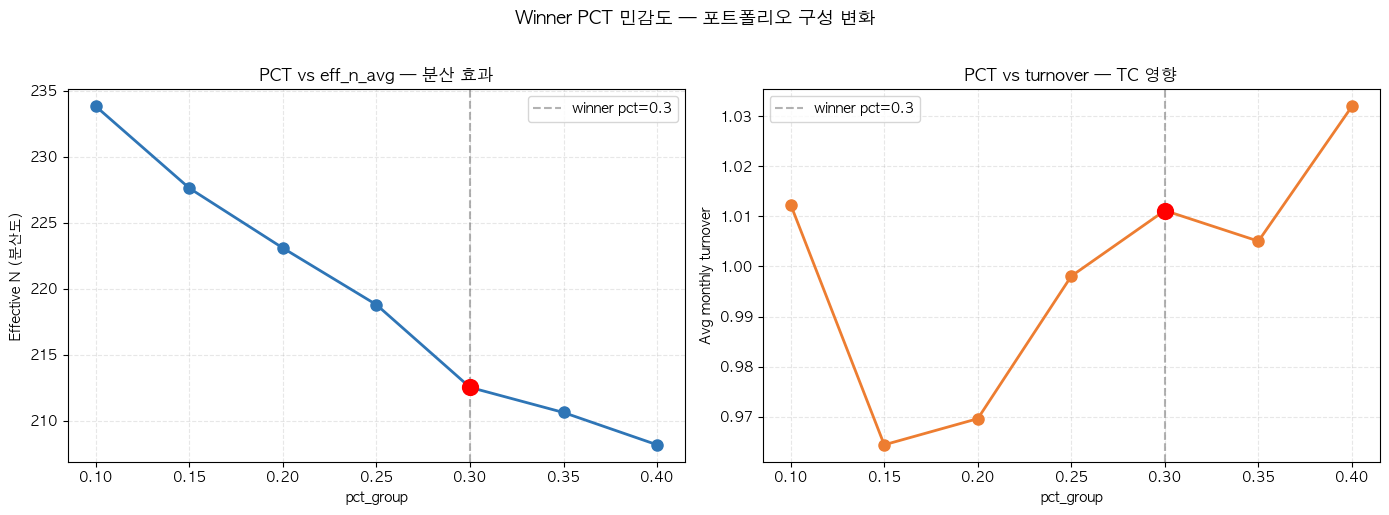


■ 포트폴리오 구성 진단
  eff_n_avg 범위: 208.2 ~ 233.8 (1.1배)
  turnover_avg 범위: 0.964 ~ 1.032 (1.07배)
  winner: eff_n=212.5, turnover=1.011
  → winner는 집중 친화적 영역 (작은 eff_n)


In [287]:
# ── N4. 포트폴리오 구성 변화 (eff_n, turnover) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) eff_n vs pct
ax = axes[0]
ax.plot(mt_winner_pct['pct_group'], mt_winner_pct['eff_n_avg'],
        'o-', linewidth=2, markersize=8, color='#2E75B6')
ax.axvline(WINNER_PCT, ls='--', color='gray', alpha=0.6, label=f'winner pct={WINNER_PCT}')
winner_row = mt_winner_pct[mt_winner_pct['name']==WINNER_NAME_PCT]
if len(winner_row) > 0:
    ax.scatter([WINNER_PCT], [winner_row['eff_n_avg'].iloc[0]],
               s=130, color='red', zorder=5)
ax.set_xlabel('pct_group')
ax.set_ylabel('Effective N (분산도)')
ax.set_title('PCT vs eff_n_avg — 분산 효과', fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')
ax.legend()

# (2) turnover vs pct
ax = axes[1]
ax.plot(mt_winner_pct['pct_group'], mt_winner_pct['turnover_avg'],
        'o-', linewidth=2, markersize=8, color='#ED7D31')
ax.axvline(WINNER_PCT, ls='--', color='gray', alpha=0.6, label=f'winner pct={WINNER_PCT}')
if len(winner_row) > 0:
    ax.scatter([WINNER_PCT], [winner_row['turnover_avg'].iloc[0]],
               s=130, color='red', zorder=5)
ax.set_xlabel('pct_group')
ax.set_ylabel('Avg monthly turnover')
ax.set_title('PCT vs turnover — TC 영향', fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')
ax.legend()

plt.suptitle('Winner PCT 민감도 — 포트폴리오 구성 변화', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
png = OUT_DIR / 'N4_pct_portfolio_composition.png'
plt.savefig(png, dpi=120, bbox_inches='tight')
print(f'✓ {png.relative_to(Path.cwd())}')
plt.show()
plt.close(fig)

# 진단
print('\n■ 포트폴리오 구성 진단')
e_min = mt_winner_pct['eff_n_avg'].min()
e_max = mt_winner_pct['eff_n_avg'].max()
t_min = mt_winner_pct['turnover_avg'].min()
t_max = mt_winner_pct['turnover_avg'].max()
print(f'  eff_n_avg 범위: {e_min:.1f} ~ {e_max:.1f} ({e_max/e_min:.1f}배)')
print(f'  turnover_avg 범위: {t_min:.3f} ~ {t_max:.3f} ({t_max/t_min:.2f}배)')

# winner 위치
w = mt_winner_pct[mt_winner_pct['name']==WINNER_NAME_PCT].iloc[0]
print(f'  winner: eff_n={w["eff_n_avg"]:.1f}, turnover={w["turnover_avg"]:.3f}')
if w['eff_n_avg'] > (e_min + e_max) / 2:
    print(f'  → winner는 분산 친화적 영역 (큰 eff_n)')
else:
    print(f'  → winner는 집중 친화적 영역 (작은 eff_n)')


## CUSTOM. 사용자 정의 슬롯 필터 — sortino_ir 정렬 (전체기간 메트릭)

**필터 조건**:
- `prior` ∈ {mcap, eq, rp}
- `p_weight` ∈ {mcap, eq, rp}
- `q` ∈ {lam, inv, raw, vsp} (fix 제외)
- `omega` ∈ {he, pap} (rms 제외)

→ `mat_{prior}_{p}_{q}_{omega}` 형식 = **3 × 3 × 4 × 2 = 72개 슬롯**

**정렬 키**: `sortino_ir` (= sortino_mean / sortino_std, 3 레짐 안정성)
**표시 메트릭**: 전체기간 (mt 기준) — Sharpe, Sortino, CAGR, Vol, MDD, Beta, Alpha

In [288]:
# ── CUSTOM. 사용자 정의 슬롯 필터 + sortino_ir 정렬 ──────────
import re

# 필터 조건
ALLOWED_PRIOR = {'mcap', 'eq', 'rp'}
ALLOWED_P     = {'mcap', 'eq', 'rp'}
ALLOWED_Q     = {'lam', 'inv', 'raw', 'vsp'}
ALLOWED_OMEGA = {'he', 'pap'}

# mat_{prior}_{p}_{q}_{omega} 패턴 매칭
pat = re.compile(r'^mat_(?P<prior>\w+?)_(?P<p>\w+?)_(?P<q>\w+?)_(?P<omega>\w+?)$')

def _match(name):
    m = pat.match(name)
    if not m: return False
    g = m.groupdict()
    return (g['prior'] in ALLOWED_PRIOR and g['p'] in ALLOWED_P
            and g['q'] in ALLOWED_Q and g['omega'] in ALLOWED_OMEGA)

# mt 에서 필터링
mt_cust = mt[mt['name'].apply(_match)].copy()
print(f'필터 매칭 슬롯: {len(mt_cust)} / {len(mt)} (예상: 72)')

# rt 에서 sortino_ir merge
mt_cust = mt_cust.merge(rt[['name', 'sortino_ir']], on='name', how='left',
                        suffixes=('', '_rt'))

# 표시할 전체기간 메트릭 컬럼 추출 (mt 안에 실제 있는 것만)
display_cols = ['name', 'sortino_ir']
for c in ['sharpe', 'sortino', 'cagr', 'vol', 'mdd', 'beta', 'alpha']:
    if c in mt_cust.columns:
        display_cols.append(c)

# sortino_ir 내림차순 정렬
mt_cust = mt_cust.sort_values('sortino_ir', ascending=False).reset_index(drop=True)
mt_cust.index += 1   # 1-based 순위

# 출력
print()
print('=' * 80)
print(f'CUSTOM 필터 슬롯 — sortino_ir 정렬 (전체기간 메트릭)')
print('=' * 80)
print(mt_cust[display_cols].round(4).to_string())


필터 매칭 슬롯: 72 / 163 (예상: 72)

CUSTOM 필터 슬롯 — sortino_ir 정렬 (전체기간 메트릭)
                     name  sortino_ir  sharpe  sortino    cagr     vol     mdd   beta   alpha
1     mat_mcap_rp_lam_pap       57.17   1.070    1.705  0.1513  0.1319 -0.1403  0.733  0.0470
2     mat_mcap_eq_lam_pap       39.42   1.106    1.742  0.1573  0.1325 -0.1473  0.734  0.0522
3       mat_eq_rp_lam_pap       34.65   1.067    1.753  0.1580  0.1386 -0.1387  0.752  0.0514
4       mat_eq_rp_raw_pap       29.85   1.069    1.777  0.1569  0.1373 -0.1387  0.737  0.0521
5     mat_mcap_rp_raw_pap       22.01   1.064    1.736  0.1490  0.1307 -0.1403  0.718  0.0467
6     mat_mcap_eq_raw_pap       17.70   1.099    1.775  0.1552  0.1315 -0.1473  0.724  0.0515
7       mat_eq_eq_raw_pap       16.50   1.096    1.826  0.1625  0.1385 -0.1365  0.753  0.0551
8       mat_eq_eq_lam_pap       15.98   1.102    1.816  0.1644  0.1394 -0.1365  0.762  0.0557
9     mat_mcap_rp_vsp_pap       13.57   1.014    1.559  0.1432  0.1323 -0.1399  0.801

## CUSTOM-2. omega={he} 만 — sortino 정렬 (2010-2023 전체기간, LSTM 기반)

**필터 조건** (CUSTOM 보다 엄격):
- `prior` ∈ {mcap, eq, rp}
- `p_weight` ∈ {mcap, eq, rp}
- `q` ∈ {lam, inv, raw, vsp} (fix 제외)
- `omega` ∈ **{he}** (pap 추가 제거)
- `p_mode` = **lstm_predicted** (trailing_vol 자동 제외)

→ `mat_{prior}_{p}_{q}_he` 형식 = **3 × 3 × 4 × 1 = 36개 슬롯**

> 참고: mat_ 슬롯들은 모두 `p_mode='lstm_predicted'`로 정의되어 있어, 슬롯 이름에 'lstm'이 안 보이지만 실제로는 LSTM 예측 기반 P 분류입니다. baseline 등 trailing 기반 슬롯은 mat_ prefix가 아니라 자동으로 제외됩니다.

In [289]:
# ── CUSTOM-2. omega={he} 만 (mat_*_he, LSTM 기반 36개) ──────
import re

# 필터 조건 (CUSTOM 보다 엄격)
ALLOWED_PRIOR = {'mcap', 'eq', 'rp'}
ALLOWED_P     = {'mcap', 'eq', 'rp'}
ALLOWED_Q     = {'lam', 'inv', 'raw', 'vsp'}
ALLOWED_OMEGA = {'he'}   # ⭐ pap 제거

# mat_{prior}_{p}_{q}_{omega} — omega=he 강제
pat2 = re.compile(r'^mat_(?P<prior>\w+?)_(?P<p>\w+?)_(?P<q>\w+?)_(?P<omega>\w+?)$')

def _match2(name):
    m = pat2.match(name)
    if not m: return False
    g = m.groupdict()
    return (g['prior'] in ALLOWED_PRIOR and g['p'] in ALLOWED_P
            and g['q'] in ALLOWED_Q and g['omega'] in ALLOWED_OMEGA)

mt_cust2 = mt[mt['name'].apply(_match2)].copy()
print(f'필터 매칭 슬롯: {len(mt_cust2)} / {len(mt)} (예상: 36)')

# rt 에서 sortino_ir merge
mt_cust2 = mt_cust2.merge(rt[['name', 'sortino_ir']], on='name', how='left',
                          suffixes=('', '_rt'))

# 표시 컬럼 (mt 안에 있는 것만)
display_cols2 = ['name', 'sortino_ir']
for c in ['sharpe', 'sortino', 'cagr', 'vol', 'mdd', 'beta', 'alpha']:
    if c in mt_cust2.columns:
        display_cols2.append(c)

# sortino_ir 내림차순 정렬
mt_cust2 = mt_cust2.sort_values('sortino', ascending=False).reset_index(drop=True)
mt_cust2.index += 1

# 출력
print()
print('=' * 80)
print('CUSTOM-2 필터 슬롯 (omega=he, LSTM 기반) — sortino 정렬 (2010-2023 전체기간)')
print('=' * 80)
print(mt_cust2[display_cols2].round(4).to_string())


필터 매칭 슬롯: 36 / 163 (예상: 36)

CUSTOM-2 필터 슬롯 (omega=he, LSTM 기반) — sortino 정렬 (2010-2023 전체기간)
                    name  sortino_ir  sharpe  sortino    cagr     vol     mdd   beta   alpha
1     mat_eq_mcap_raw_he        8.20   1.060    1.905  0.1373  0.1197 -0.1419  0.541  0.0577
2     mat_rp_mcap_raw_he        4.48   1.044    1.884  0.1321  0.1168 -0.1437  0.506  0.0574
3     mat_eq_mcap_lam_he        8.29   1.034    1.850  0.1310  0.1169 -0.1217  0.556  0.0499
4     mat_rp_mcap_lam_he        4.44   1.020    1.850  0.1262  0.1141 -0.1258  0.519  0.0500
5   mat_mcap_mcap_raw_he        7.72   1.015    1.825  0.1271  0.1157 -0.1369  0.520  0.0508
6       mat_eq_rp_raw_he        3.46   0.990    1.822  0.1298  0.1218 -0.1416  0.514  0.0548
7       mat_eq_eq_raw_he        3.09   0.985    1.784  0.1290  0.1216 -0.1511  0.493  0.0567
8       mat_rp_rp_raw_he        2.84   0.978    1.771  0.1260  0.1193 -0.1424  0.482  0.0552
9       mat_rp_eq_raw_he        2.80   0.980    1.767  0.1266  0.1198